# Recent Dataset — Training-Only EDA using Final Project B Features

This notebook treats `final_feature_B.txt` as the predefined feature inventory for the benchmark models. Feature analysis is limited to sanity checks and descriptive diagnostics; it does not repeat Project B's feature-selection process.


## 1. Imports and global configuration

In [1]:
import json
import re
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------------
# Canonical column names
# -----------------------------
INDEX_COL = "IndexReference"
DATE_COL = "attr__timestamp"
TICKER_COL = "attr__ticker"
SIC2_COL = "attr__sic2"
YEAR_COL = "year"
SPLIT_COL = "split"

# -----------------------------
# Dataset configuration
# -----------------------------
PROJECT_ROOT = Path.cwd()

UNIVERSE = "universe_100"
TIME_HORIZON = "recent"
NORMALISATION_STATUS = "post_normalisation"

DATASET_NAME = f"{UNIVERSE}_{TIME_HORIZON}_{NORMALISATION_STATUS}"

# Change this path if the training file is stored elsewhere.
TRAIN_PATH = PROJECT_ROOT / f"{DATASET_NAME}_train.jsonl"

# Validation / test splits for the yearly temporal EDA.
# Set SPLIT_FILE_FORMAT to ".jsonl" to guarantee identical flattening and
# column naming to the training split, or ".parquet" to load pre-flattened
# files faster. The matching files must live in PROJECT_ROOT.
SPLIT_FILE_FORMAT = ".jsonl"
VALIDATION_PATH = PROJECT_ROOT / f"{DATASET_NAME}_validation{SPLIT_FILE_FORMAT}"
TEST_PATH = PROJECT_ROOT / f"{DATASET_NAME}_test{SPLIT_FILE_FORMAT}"

# Optional Project B feature inventory.
PROJECT_B_FEATURE_FILE = PROJECT_ROOT / "final_feature_B.txt"

# -----------------------------
# EDA configuration
# -----------------------------
MISSING_THRESHOLD = 0.50
CORR_THRESHOLD = 0.95
TOP_MISSING_FEATURES_TO_PLOT = 30
TOP_VARIABLE_FEATURES_TO_PLOT = 20
TOP_CORRELATION_FEATURES = 30
HISTOGRAM_BINS = 50
FIGURE_DPI = 180

# Set to None to analyse every available derived/raw target.
SELECTED_TARGETS = None

# -----------------------------
# Output folders
# -----------------------------
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = PROJECT_ROOT / f"recent_training_eda_outputs_{RUN_TIMESTAMP}"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
INVENTORY_DIR = OUTPUT_DIR / "inventories"

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, INVENTORY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_NAME)
print("Training path:", TRAIN_PATH)
print("Training file exists:", TRAIN_PATH.exists())
print("Output directory:", OUTPUT_DIR.resolve())
print("Validation path:", VALIDATION_PATH, "| exists:", VALIDATION_PATH.exists())
print("Test path:", TEST_PATH, "| exists:", TEST_PATH.exists())


Dataset: universe_100_recent_post_normalisation
Training path: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\universe_100_recent_post_normalisation_train.jsonl
Training file exists: True
Output directory: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831
Validation path: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\universe_100_recent_post_normalisation_validation.jsonl | exists: True
Test path: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\universe_100_recent_post_normalisation_test.jsonl | exists: True


## 2. Reusable export helpers

In [2]:
EXPORTED_TABLES = {}


def safe_name(value, max_len=140):
    value = re.sub(r"[^A-Za-z0-9_\-]+", "_", str(value))
    value = re.sub(r"_+", "_", value).strip("_")
    return (value or "output")[:max_len]

def make_excel_safe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in df.columns:
        # Handles normal datetime64 columns
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            try:
                df[col] = df[col].dt.tz_localize(None)
            except TypeError:
                # Already timezone-naive
                pass

        # Handles object columns containing timezone-aware Timestamp values
        elif df[col].dtype == "object":
            if df[col].map(lambda x: isinstance(x, pd.Timestamp)).any():
                df[col] = df[col].map(
                    lambda x: x.tz_localize(None)
                    if isinstance(x, pd.Timestamp) and x.tzinfo is not None
                    else x
                )

    return df

def export_table(name, df, display_table=True):
    """Register and export a DataFrame as CSV and XLSX."""
    if df is None:
        return None

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    key = safe_name(name)
    EXPORTED_TABLES[key] = df.copy()

    csv_path = TABLE_DIR / f"{key}.csv"
    xlsx_path = TABLE_DIR / f"{key}.xlsx"

    df.to_csv(csv_path, index=False)
    try:
        excel_df = make_excel_safe(df)
        excel_df.to_excel(xlsx_path, index=False)
    except Exception as exc:
        print(f"Excel export skipped for {key}: {exc}")

    if display_table:
        display(df)

    print(f"Saved table: {csv_path}")
    return df


def save_current_figure(name, close=False):
    """Save the current matplotlib figure with a consistent filename."""
    path = FIGURE_DIR / f"{safe_name(name)}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
    print(f"Saved figure: {path}")

    if close:
        plt.close()

    return path


def export_all_tables_to_workbook(
    filename="recent_training_eda_all_tables.xlsx"
):
    workbook_path = TABLE_DIR / filename
    used_sheets = set()

    with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
        if not EXPORTED_TABLES:
            pd.DataFrame({
                "message": ["No tables have been registered."]
            }).to_excel(
                writer,
                sheet_name="README",
                index=False
            )

        else:
            for name, df in EXPORTED_TABLES.items():
                sheet = safe_name(name, max_len=31)
                base = sheet
                counter = 1

                # Ensure every sheet name is unique
                while sheet in used_sheets:
                    suffix = f"_{counter}"
                    sheet = safe_name(
                        base[:31 - len(suffix)] + suffix,
                        max_len=31
                    )
                    counter += 1

                used_sheets.add(sheet)

                # Remove timezone information before Excel export
                excel_df = make_excel_safe(df)

                excel_df.head(1_000_000).to_excel(
                    writer,
                    sheet_name=sheet,
                    index=False
                )

    print("Saved integrated workbook:", workbook_path.resolve())
    return workbook_path



## 3. Dataset loading and standardisation

In [3]:
def load_flatten_jsonl(path):
    """Load and flatten Adaptive Swarm model-ready JSONL data."""
    rows = []
    path = Path(path)

    def open_text_file(file_path):
        if file_path.suffix.lower() == ".gz":
            import gzip
            return gzip.open(file_path, "rt", encoding="utf-8")
        return file_path.open("r", encoding="utf-8")

    with open_text_file(path) as file:
        for line in file:
            if not line.strip():
                continue

            raw_record = json.loads(line)

            if raw_record.get("section") == "header":
                continue

            record = (
                raw_record.get("data", {}) or {}
                if raw_record.get("section") == "data"
                else raw_record
            )

            if not isinstance(record, dict):
                continue

            attributes = (
                record.get("Attributes")
                or record.get("attributes")
                or record.get("attrs")
                or {}
            )
            features = record.get("Features") or record.get("features") or {}
            labels = record.get("Labels") or record.get("labels") or {}

            row = {
                INDEX_COL: record.get(
                    "IndexReference",
                    raw_record.get("IndexReference")
                )
            }

            for key, value in attributes.items():
                column = key if str(key).startswith("attr__") else f"attr__{key}"
                row[column] = value

            for key, value in features.items():
                column = key if str(key).startswith("feature__") else f"feature__{key}"
                row[column] = value

            for key, value in labels.items():
                column = key if str(key).startswith("label__") else f"label__{key}"
                row[column] = value

            # Preserve scalar fields for auditability.
            excluded = {
                "Attributes", "attributes", "attrs",
                "Features", "features",
                "Labels", "labels"
            }
            for key, value in record.items():
                if key not in excluded and not isinstance(value, (dict, list)):
                    row.setdefault(key, value)

            rows.append(row)

    df = pd.DataFrame(rows)
    print("Flattened JSONL shape:", df.shape)
    return df


def load_jsonl_zip(path):
    """Load a zip archive containing one JSONL file."""
    import zipfile

    path = Path(path)
    rows = []

    with zipfile.ZipFile(path, "r") as archive:
        jsonl_files = [
            name for name in archive.namelist()
            if name.lower().endswith(".jsonl")
        ]

        if not jsonl_files:
            raise ValueError(f"No JSONL file found inside: {path}")

        with archive.open(jsonl_files[0], "r") as file:
            for raw_line in file:
                line = raw_line.decode("utf-8")
                if not line.strip():
                    continue

                raw_record = json.loads(line)
                if raw_record.get("section") == "header":
                    continue

                record = (
                    raw_record.get("data", {}) or {}
                    if raw_record.get("section") == "data"
                    else raw_record
                )

                if not isinstance(record, dict):
                    continue

                attributes = (
                    record.get("Attributes")
                    or record.get("attributes")
                    or record.get("attrs")
                    or {}
                )
                features = record.get("Features") or record.get("features") or {}
                labels = record.get("Labels") or record.get("labels") or {}

                row = {
                    INDEX_COL: record.get(
                        "IndexReference",
                        raw_record.get("IndexReference")
                    )
                }

                for key, value in attributes.items():
                    column = key if str(key).startswith("attr__") else f"attr__{key}"
                    row[column] = value

                for key, value in features.items():
                    column = key if str(key).startswith("feature__") else f"feature__{key}"
                    row[column] = value

                for key, value in labels.items():
                    column = key if str(key).startswith("label__") else f"label__{key}"
                    row[column] = value

                rows.append(row)

    df = pd.DataFrame(rows)
    print("Flattened zipped JSONL shape:", df.shape)
    return df


def load_table(path):
    """Load parquet, CSV, JSON, JSONL, compressed JSONL, or zipped JSONL."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    filename = path.name.lower()
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".csv":
        return pd.read_csv(path)

    if suffix == ".jsonl" or filename.endswith(".jsonl.gz"):
        return load_flatten_jsonl(path)

    if filename.endswith(".jsonl.zip"):
        return load_jsonl_zip(path)

    if suffix == ".json":
        try:
            return pd.read_json(path, lines=True)
        except ValueError:
            return pd.read_json(path)

    raise ValueError(f"Unsupported file format: {path}")


def standardise_frame(df, split_name="train"):
    """Apply canonical date, ticker, SIC, year, and split variables."""
    df = df.copy()
    df[SPLIT_COL] = split_name

    if INDEX_COL not in df.columns:
        df[INDEX_COL] = np.arange(len(df))
        print(f"Warning: generated fallback {INDEX_COL} values.")

    if DATE_COL in df.columns:
        df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
        df[YEAR_COL] = df[DATE_COL].dt.year
    else:
        df[YEAR_COL] = np.nan
        print(f"Warning: {DATE_COL} is absent.")

    for column in [TICKER_COL, SIC2_COL]:
        if column not in df.columns:
            df[column] = np.nan

    return df


df_train = standardise_frame(load_table(TRAIN_PATH), split_name="train")

print("Training shape:", df_train.shape)
print("Date range:", df_train[DATE_COL].min(), "to", df_train[DATE_COL].max())
print("Number of tickers:", df_train[TICKER_COL].nunique(dropna=True))


def load_split_frame(path, split_name):
    """Load and standardise an optional split; return None if the file is absent."""
    path = Path(path)
    if not path.exists():
        print(f"[{split_name}] file not found, skipping: {path}")
        return None
    frame = standardise_frame(load_table(path), split_name=split_name)
    print(f"[{split_name}] shape:", frame.shape)
    if DATE_COL in frame.columns:
        print(f"[{split_name}] date range:", frame[DATE_COL].min(), "to", frame[DATE_COL].max())
    return frame


# Optional splits used only for the temporal (yearly) EDA in Section 12.
df_validation = load_split_frame(VALIDATION_PATH, "validation")
df_test = load_split_frame(TEST_PATH, "test")


Flattened JSONL shape: (98419, 747)
Training shape: (98419, 749)
Date range: 2020-01-02 00:00:00+00:00 to 2023-12-29 00:00:00+00:00
Number of tickers: 98
Flattened JSONL shape: (24469, 747)
[validation] shape: (24469, 749)
[validation] date range: 2024-01-02 00:00:00+00:00 to 2024-12-31 00:00:00+00:00
Flattened JSONL shape: (32142, 747)
[test] shape: (32142, 749)
[test] date range: 2025-01-02 00:00:00+00:00 to 2026-04-27 00:00:00+00:00


## 4. Canonical column inventories

In [4]:
attribute_cols = sorted([c for c in df_train.columns if c.startswith("attr__")])
feature_cols = sorted([c for c in df_train.columns if c.startswith("feature__")])
label_cols = sorted([c for c in df_train.columns if c.startswith("label__")])

inventory_summary = pd.DataFrame({
    "column_family": ["attributes", "features", "labels", "other"],
    "n_columns": [
        len(attribute_cols),
        len(feature_cols),
        len(label_cols),
        len(df_train.columns) - len(attribute_cols) - len(feature_cols) - len(label_cols)
    ]
})

export_table("column_family_summary", inventory_summary)

for filename, columns in {
    "attribute_columns.txt": attribute_cols,
    "feature_columns.txt": feature_cols,
    "label_columns.txt": label_cols
}.items():
    path = INVENTORY_DIR / filename
    path.write_text("\n".join(columns), encoding="utf-8")
    print("Saved inventory:", path)

print("Attributes:", len(attribute_cols))
print("Features:", len(feature_cols))
print("Labels:", len(label_cols))


,column_family,n_columns
0,attributes,46
1,features,621
2,labels,78
3,other,4


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\column_family_summary.csv
Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\inventories\attribute_columns.txt
Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\inventories\feature_columns.txt
Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\inventories\label_columns.txt
Attributes: 46
Features: 621
Labels: 78


## 5. Derived target construction

In [5]:
def first_existing_column(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


def make_pi_hindsight_entry_long_6bins(series):
    values = pd.to_numeric(series, errors="coerce")
    output = pd.Series(np.nan, index=values.index)

    output[values == 0] = 0
    output[(values > 0) & (values < 0.1)] = 1
    output[(values >= 0.1) & (values < 0.2)] = 2
    output[(values >= 0.2) & (values < 0.4)] = 3
    output[(values >= 0.4) & (values < 0.7)] = 4
    output[values >= 0.7] = 5

    return output.astype("Int64")


def add_derived_targets(df):
    df = df.copy()

    pi_column = first_existing_column(
        df,
        [
            "label__pi_hindsight_entry_long",
            "label__pi_long_entry",
            "pi_hindsight_entry_long"
        ]
    )

    if pi_column is not None:
        df["target__pi_hindsight_entry_long"] = pd.to_numeric(
            df[pi_column], errors="coerce"
        )
        df["target__pi_hindsight_entry_positive"] = (
            df["target__pi_hindsight_entry_long"] > 0
        ).astype("Int64")
        df["target__pi_hindsight_entry_original"] = (
            df["target__pi_hindsight_entry_long"] >= 0.4
        ).astype("Int64")
        df["target__pi_hindsight_entry_6bins"] = (
            make_pi_hindsight_entry_long_6bins(
                df["target__pi_hindsight_entry_long"]
            )
        )

    target_source_map = {
        "target__rl_long_is_best": [
            "label__rl.long_is_best",
            "label__rl_long_is_best"
        ],
        "target__rl_long_action_quality": [
            "label__rl.long.action_quality",
            "label__rl_long_action_quality"
        ],
        "target__rl_long_action_binary": [
            "label__rl.long.action_label",
            "label__rl_long_action_binary"
        ],
        "target__rl_long_reward": [
            "label__rl.reward.long",
            "label__rl_reward_long",
            "label__rl.long.reward"
        ],
        "target__rl_long_current_pnl": [
            "label__rl.long.current_pnl",
            "label__rl_long_current_pnl",
            "label__rl.long_current_pnl",
            "label__current_pnl"
        ]
    }

    for target_column, candidates in target_source_map.items():
        source_column = first_existing_column(df, candidates)
        if source_column is not None:
            df[target_column] = pd.to_numeric(
                df[source_column], errors="coerce"
            )

    if "target__rl_long_current_pnl" in df.columns:
        _pnl = df["target__rl_long_current_pnl"]
        df["target__rl_long_current_pnl_signedlog"] = np.sign(_pnl) * np.log1p(_pnl.abs())

    return df


df_train = add_derived_targets(df_train)
target_cols = sorted([c for c in df_train.columns if c.startswith("target__")])

print("Available derived targets:")
for column in target_cols:
    print(" -", column)

pd.Series(target_cols).to_csv(
    INVENTORY_DIR / "derived_target_columns.txt",
    index=False,
    header=False
)


# Apply the identical derived-target construction to the optional splits so that
# the combined frame carries the same target__ columns as the training data.
if df_validation is not None:
    df_validation = add_derived_targets(df_validation)
if df_test is not None:
    df_test = add_derived_targets(df_test)

# Combined frame spanning every available split, used for the temporal EDA.
# df_train is left untouched so all training-only sections above remain valid.
_split_frames = [f for f in (df_train, df_validation, df_test) if f is not None]
df_all = pd.concat(_split_frames, ignore_index=True)

_split_order = [s for s in ["train", "validation", "test"] if s in df_all[SPLIT_COL].unique()]
df_all[SPLIT_COL] = pd.Categorical(df_all[SPLIT_COL], categories=_split_order, ordered=True)

print("Combined df_all shape:", df_all.shape)
print("Rows per split:")
print(df_all[SPLIT_COL].value_counts().sort_index())


Available derived targets:
 - target__pi_hindsight_entry_6bins
 - target__pi_hindsight_entry_long
 - target__pi_hindsight_entry_original
 - target__pi_hindsight_entry_positive
 - target__rl_long_action_binary
 - target__rl_long_action_quality
 - target__rl_long_current_pnl
 - target__rl_long_reward
Combined df_all shape: (155030, 757)
Rows per split:
split
train         98419
validation    24469
test          32142
Name: count, dtype: int64


## 6. Dataset coverage and structural checks

In [6]:
dataset_overview = pd.DataFrame([{
    "dataset_name": DATASET_NAME,
    "n_rows": len(df_train),
    "n_columns": df_train.shape[1],
    "n_attributes": len(attribute_cols),
    "n_features": len(feature_cols),
    "n_raw_labels": len(label_cols),
    "n_derived_targets": len(target_cols),
    "n_tickers": df_train[TICKER_COL].nunique(dropna=True),
    "start_date": df_train[DATE_COL].min(),
    "end_date": df_train[DATE_COL].max(),
    "duplicate_index_references": df_train[INDEX_COL].duplicated().sum(),
    "missing_index_reference_rate": df_train[INDEX_COL].isna().mean(),
    "missing_timestamp_rate": df_train[DATE_COL].isna().mean(),
    "missing_ticker_rate": df_train[TICKER_COL].isna().mean()
}])

export_table("dataset_overview", dataset_overview)

ticker_coverage = (
    df_train.groupby(TICKER_COL, dropna=False)
    .agg(
        n_rows=(INDEX_COL, "size"),
        start_date=(DATE_COL, "min"),
        end_date=(DATE_COL, "max"),
        n_years=(YEAR_COL, "nunique")
    )
    .reset_index()
    .sort_values("n_rows", ascending=False)
)

export_table("ticker_coverage", ticker_coverage)

year_coverage = (
    df_train.groupby(YEAR_COL, dropna=False)
    .agg(
        n_rows=(INDEX_COL, "size"),
        n_tickers=(TICKER_COL, "nunique")
    )
    .reset_index()
    .sort_values(YEAR_COL)
)

export_table("year_coverage", year_coverage)

ticker_year_coverage = (
    df_train.groupby([TICKER_COL, YEAR_COL], dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)

export_table("ticker_year_coverage", ticker_year_coverage)


,dataset_name,n_rows,n_columns,n_attributes,n_features,n_raw_labels,n_derived_targets,n_tickers,start_date,end_date,duplicate_index_references,missing_index_reference_rate,missing_timestamp_rate,missing_ticker_rate
0,universe_100_recent_post_normalisation,98419,757,46,621,78,8,98,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,0,0.0,0.0,0.0


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\dataset_overview.csv


,attr__ticker,n_rows,start_date,end_date,n_years
0,AAPL,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
1,ABBV,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
2,ABT,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
3,ACN,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
4,ADBE,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
...,...,...,...,...,...
94,VZ,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
97,XOM,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
95,WFC,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
92,UNP,981,2020-01-02 00:00:00+00:00,2023-11-22 00:00:00+00:00,4


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\ticker_coverage.csv


,year,n_rows,n_tickers
0,2020,24650,98
1,2021,24696,98
2,2022,24598,98
3,2023,24475,98


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\year_coverage.csv


,attr__ticker,year,n_rows
0,AAPL,2020,253
1,AAPL,2021,252
2,AAPL,2022,251
3,AAPL,2023,250
4,ABBV,2020,253
...,...,...,...
387,WMT,2023,250
388,XOM,2020,253
389,XOM,2021,252
390,XOM,2022,251


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\ticker_year_coverage.csv


,attr__ticker,year,n_rows
0,AAPL,2020,253
1,AAPL,2021,252
2,AAPL,2022,251
3,AAPL,2023,250
4,ABBV,2020,253
...,...,...,...
387,WMT,2023,250
388,XOM,2020,253
389,XOM,2021,252
390,XOM,2022,251


Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\training_observations_by_ticker.png


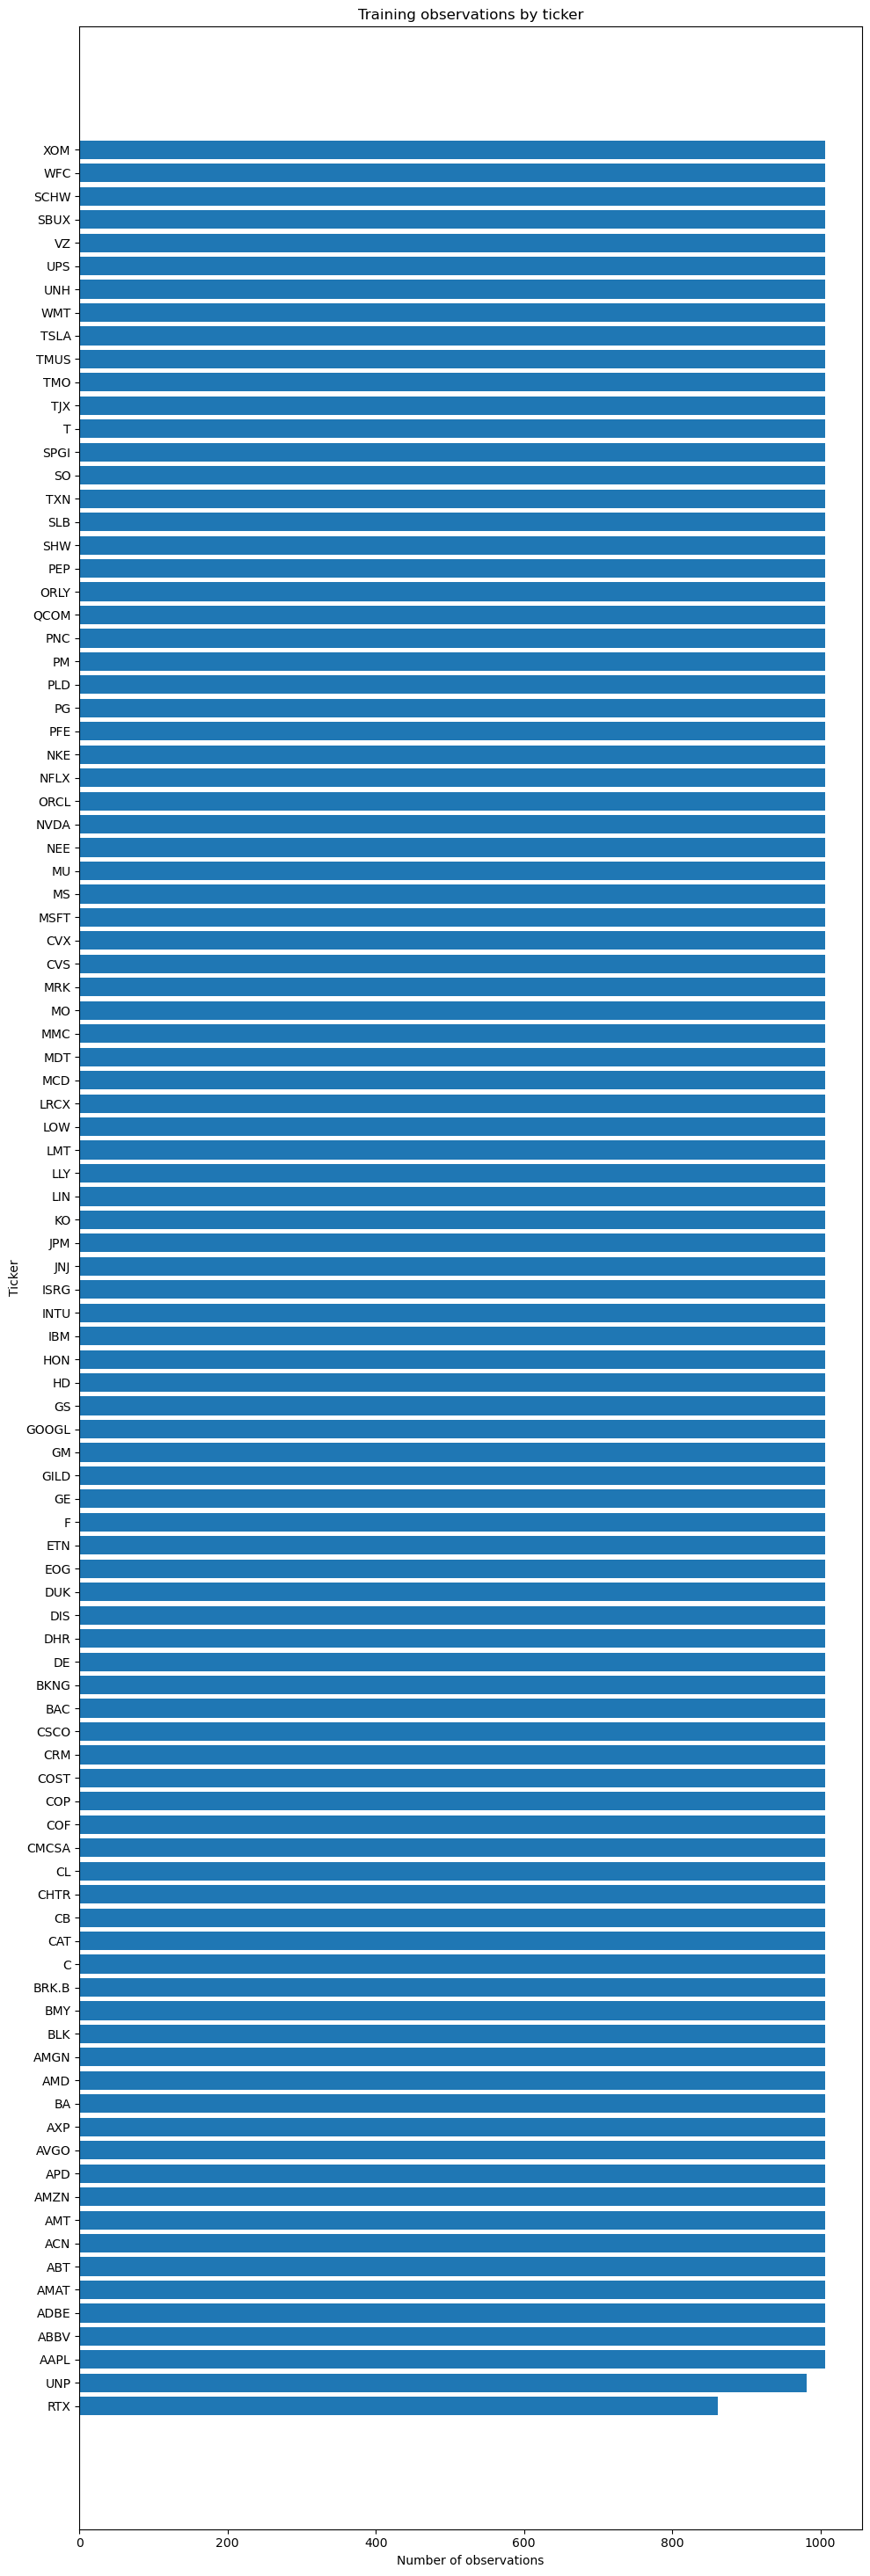

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\training_observations_by_year.png


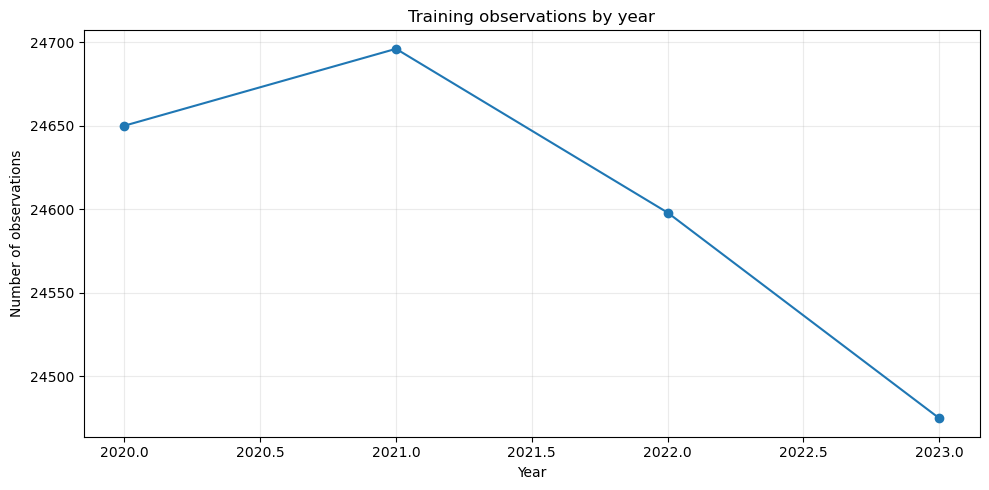

In [7]:
# Observations by ticker
plot_data = ticker_coverage.dropna(subset=[TICKER_COL]).sort_values("n_rows")

plt.figure(figsize=(10, max(5, 0.3 * len(plot_data))))
plt.barh(plot_data[TICKER_COL].astype(str), plot_data["n_rows"])
plt.title("Training observations by ticker")
plt.xlabel("Number of observations")
plt.ylabel("Ticker")
save_current_figure("training_observations_by_ticker")
plt.show()

# Observations by year
year_plot = year_coverage.dropna(subset=[YEAR_COL])

plt.figure(figsize=(10, 5))
plt.plot(year_plot[YEAR_COL], year_plot["n_rows"], marker="o")
plt.title("Training observations by year")
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.grid(alpha=0.25)
save_current_figure("training_observations_by_year")
plt.show()


## 7. Final Project B feature-set sanity checks

The Project B feature list is treated as the predefined modelling input. The following checks assess availability, missingness, degeneracy, invalid values, distribution shape, temporal/ticker coverage and residual correlation. They are quality-assurance diagnostics only and do not constitute a new feature-selection stage.


In [8]:
def normalise_feature_name(feature):
    """Match the unprefixed Project B inventory to flattened dataset columns."""
    feature = str(feature).strip()
    return feature if feature.startswith("feature__") else f"feature__{feature}"


if not PROJECT_B_FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"Final Project B feature list was not found: {PROJECT_B_FEATURE_FILE}"
    )

raw_final_feature_b = [
    line.strip()
    for line in PROJECT_B_FEATURE_FILE.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

final_feature_b_requested = [
    normalise_feature_name(feature)
    for feature in raw_final_feature_b
]

# Preserve the file order while removing accidental duplicates.
final_feature_b_requested = list(dict.fromkeys(final_feature_b_requested))

final_feature_b_available = [
    feature for feature in final_feature_b_requested
    if feature in df_train.columns
]

final_feature_b_missing = [
    feature for feature in final_feature_b_requested
    if feature not in df_train.columns
]

print("Features requested by final_feature_B:", len(final_feature_b_requested))
print("Available in training data:", len(final_feature_b_available))
print("Missing from training data:", len(final_feature_b_missing))

if final_feature_b_missing:
    display(pd.DataFrame({"missing_feature": final_feature_b_missing}))


def numeric_column_summary(data, columns):
    rows = []

    for column in columns:
        raw = data[column]
        values = pd.to_numeric(raw, errors="coerce")
        finite_mask = np.isfinite(values)

        rows.append({
            "column": column,
            "dtype": str(raw.dtype),
            "n_rows": len(raw),
            "count_numeric": int(values.notna().sum()),
            "missing_count": int(values.isna().sum()),
            "missing_rate": float(values.isna().mean()),
            "non_finite_count": int((values.notna() & ~finite_mask).sum()),
            "zero_count": int((values == 0).sum()),
            "zero_rate": float((values == 0).mean()),
            "n_unique": int(values.nunique(dropna=True)),
            "mean": values[finite_mask].mean(),
            "std": values[finite_mask].std(),
            "skewness": values[finite_mask].skew(),
            "min": values[finite_mask].min(),
            "p01": values[finite_mask].quantile(0.01),
            "p05": values[finite_mask].quantile(0.05),
            "p25": values[finite_mask].quantile(0.25),
            "median": values[finite_mask].quantile(0.50),
            "p75": values[finite_mask].quantile(0.75),
            "p95": values[finite_mask].quantile(0.95),
            "p99": values[finite_mask].quantile(0.99),
            "max": values[finite_mask].max()
        })

    return pd.DataFrame(rows)


final_feature_b_summary = numeric_column_summary(
    df_train,
    final_feature_b_available
)

final_feature_b_summary["is_constant"] = (
    final_feature_b_summary["n_unique"].fillna(0) <= 1
)

final_feature_b_summary["is_near_constant_99pct_zero"] = (
    final_feature_b_summary["zero_rate"].fillna(0) >= 0.99
)

final_feature_b_summary["high_missingness"] = (
    final_feature_b_summary["missing_rate"] > MISSING_THRESHOLD
)

final_feature_b_summary["extreme_skew_abs_gt_10"] = (
    final_feature_b_summary["skewness"].abs() > 10
)

final_feature_b_summary["passes_basic_sanity_check"] = (
    ~final_feature_b_summary["is_constant"]
    & ~final_feature_b_summary["high_missingness"]
    & (final_feature_b_summary["non_finite_count"] == 0)
)

export_table(
    "final_feature_b_summary",
    final_feature_b_summary,
    display_table=False
)

feature_sanity_overview = pd.DataFrame([{
    "requested_features": len(final_feature_b_requested),
    "available_features": len(final_feature_b_available),
    "missing_features": len(final_feature_b_missing),
    "constant_features": int(final_feature_b_summary["is_constant"].sum()),
    "near_constant_99pct_zero": int(
        final_feature_b_summary["is_near_constant_99pct_zero"].sum()
    ),
    "features_above_missingness_threshold": int(
        final_feature_b_summary["high_missingness"].sum()
    ),
    "features_with_non_finite_values": int(
        (final_feature_b_summary["non_finite_count"] > 0).sum()
    ),
    "features_with_extreme_skewness": int(
        final_feature_b_summary["extreme_skew_abs_gt_10"].sum()
    ),
    "features_passing_basic_sanity_check": int(
        final_feature_b_summary["passes_basic_sanity_check"].sum()
    )
}])

export_table("final_feature_b_sanity_overview", feature_sanity_overview)

# The final Project B set remains the canonical feature set.
# Features that fail a check are reported for review rather than silently removed.
final_feature_b_features = [
    feature
    for feature in final_feature_b_available
    if df_train[feature].nunique(dropna=True) > 1
]
print(
    "Requested:", len(final_feature_b_requested),
    "| available:", len(final_feature_b_available),
    "| final modelling (non-constant):", len(final_feature_b_features)
)

pd.Series(final_feature_b_requested).to_csv(
    INVENTORY_DIR / "final_feature_b_requested.txt",
    index=False,
    header=False
)
pd.Series(final_feature_b_available).to_csv(
    INVENTORY_DIR / "final_feature_b_available.txt",
    index=False,
    header=False
)
pd.Series(final_feature_b_missing).to_csv(
    INVENTORY_DIR / "final_feature_b_missing.txt",
    index=False,
    header=False
)

display(feature_sanity_overview)


Features requested by final_feature_B: 270
Available in training data: 270
Missing from training data: 0
Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\final_feature_b_summary.csv


,requested_features,available_features,missing_features,constant_features,near_constant_99pct_zero,features_above_missingness_threshold,features_with_non_finite_values,features_with_extreme_skewness,features_passing_basic_sanity_check
0,270,270,0,2,11,0,0,41,268


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\final_feature_b_sanity_overview.csv


,requested_features,available_features,missing_features,constant_features,near_constant_99pct_zero,features_above_missingness_threshold,features_with_non_finite_values,features_with_extreme_skewness,features_passing_basic_sanity_check
0,270,270,0,2,11,0,0,41,268


Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_missingness.png


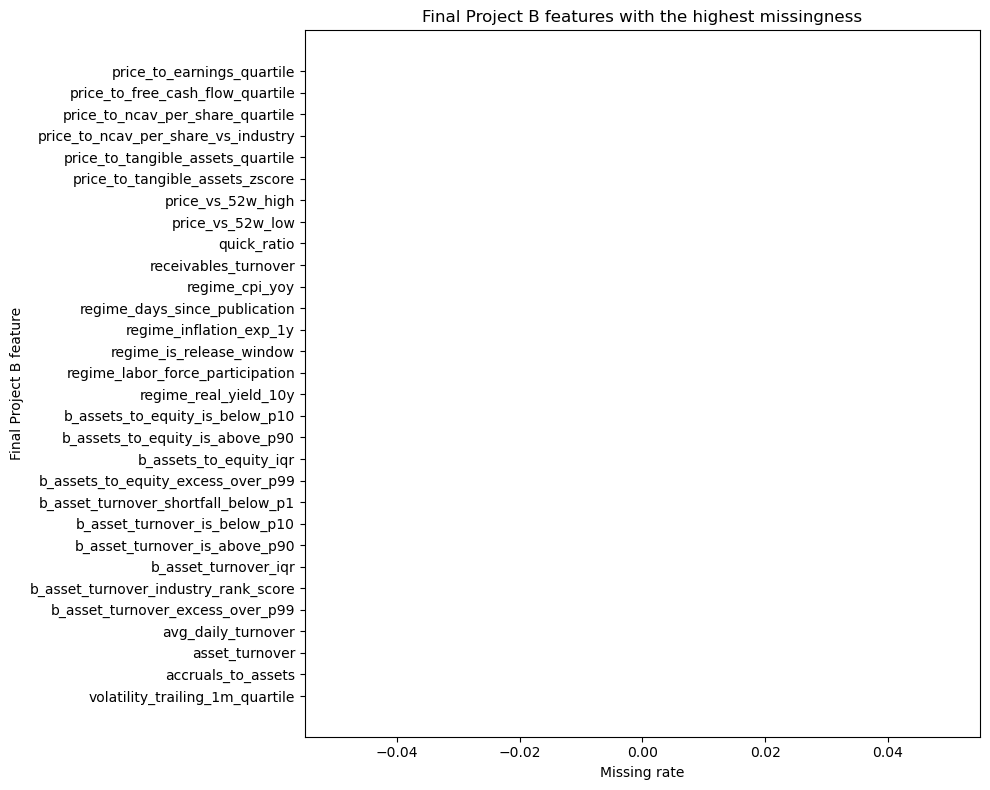

,column,dtype,n_rows,count_numeric,missing_count,missing_rate,non_finite_count,zero_count,zero_rate,n_unique,...,median,p75,p95,p99,max,is_constant,is_near_constant_99pct_zero,high_missingness,extreme_skew_abs_gt_10,passes_basic_sanity_check
3,feature__b_asset_turnover_excess_over_p99,float64,98419,98419,0,0.0,0,96155,0.976996,39,...,0.000000,0.000000,0.000000,0.007012,0.049770,False,False,False,True,True
8,feature__b_asset_turnover_shortfall_below_p1,float64,98419,98419,0,0.0,0,97398,0.989626,18,...,0.000000,0.000000,0.000000,0.000142,0.062458,False,False,False,True,True
13,feature__b_assets_to_equity_shortfall_below_p1,float64,98419,98419,0,0.0,0,95343,0.968746,53,...,0.000000,0.000000,0.000000,1.282761,6.196217,False,False,False,True,True
14,feature__b_cash_conversion_cycle_excess_over_p99,float64,98419,98419,0,0.0,0,97279,0.988417,20,...,0.000000,0.000000,0.000000,0.729767,4.360508,False,False,False,True,True
20,feature__b_cfo_margin_excess_over_p99,float64,98419,98419,0,0.0,0,94873,0.963970,61,...,0.000000,0.000000,0.000000,0.027392,1.230524,False,False,False,True,True
23,feature__b_cfo_margin_pct_diff_to_p50,float64,98419,98419,0,0.0,0,1549,0.015739,1632,...,1.106714,2.833251,13.191308,53.044646,514.374164,False,False,False,True,True
25,feature__b_current_assets_to_total_liabilities...,int64,98419,98419,0,0.0,0,98419,1.000000,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,True,True,False,False,False
31,feature__b_current_ratio_excess_over_p99,float64,98419,98419,0,0.0,0,98175,0.997521,5,...,0.000000,0.000000,0.000000,0.000000,1.790391,False,True,False,True,True
35,feature__b_days_inventory_outstanding_excess_o...,float64,98419,98419,0,0.0,0,97732,0.993020,12,...,0.000000,0.000000,0.000000,0.000000,5.073327,False,True,False,True,True
40,feature__b_days_inventory_outstanding_shortfal...,float64,98419,98419,0,0.0,0,96952,0.985094,25,...,0.000000,0.000000,0.000000,0.124603,0.640187,False,False,False,True,True


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\final_feature_b_flagged_sanity_checks.csv


,column,dtype,n_rows,count_numeric,missing_count,missing_rate,non_finite_count,zero_count,zero_rate,n_unique,...,median,p75,p95,p99,max,is_constant,is_near_constant_99pct_zero,high_missingness,extreme_skew_abs_gt_10,passes_basic_sanity_check
3,feature__b_asset_turnover_excess_over_p99,float64,98419,98419,0,0.0,0,96155,0.976996,39,...,0.000000,0.000000,0.000000,0.007012,0.049770,False,False,False,True,True
8,feature__b_asset_turnover_shortfall_below_p1,float64,98419,98419,0,0.0,0,97398,0.989626,18,...,0.000000,0.000000,0.000000,0.000142,0.062458,False,False,False,True,True
13,feature__b_assets_to_equity_shortfall_below_p1,float64,98419,98419,0,0.0,0,95343,0.968746,53,...,0.000000,0.000000,0.000000,1.282761,6.196217,False,False,False,True,True
14,feature__b_cash_conversion_cycle_excess_over_p99,float64,98419,98419,0,0.0,0,97279,0.988417,20,...,0.000000,0.000000,0.000000,0.729767,4.360508,False,False,False,True,True
20,feature__b_cfo_margin_excess_over_p99,float64,98419,98419,0,0.0,0,94873,0.963970,61,...,0.000000,0.000000,0.000000,0.027392,1.230524,False,False,False,True,True
23,feature__b_cfo_margin_pct_diff_to_p50,float64,98419,98419,0,0.0,0,1549,0.015739,1632,...,1.106714,2.833251,13.191308,53.044646,514.374164,False,False,False,True,True
25,feature__b_current_assets_to_total_liabilities...,int64,98419,98419,0,0.0,0,98419,1.000000,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,True,True,False,False,False
31,feature__b_current_ratio_excess_over_p99,float64,98419,98419,0,0.0,0,98175,0.997521,5,...,0.000000,0.000000,0.000000,0.000000,1.790391,False,True,False,True,True
35,feature__b_days_inventory_outstanding_excess_o...,float64,98419,98419,0,0.0,0,97732,0.993020,12,...,0.000000,0.000000,0.000000,0.000000,5.073327,False,True,False,True,True
40,feature__b_days_inventory_outstanding_shortfal...,float64,98419,98419,0,0.0,0,96952,0.985094,25,...,0.000000,0.000000,0.000000,0.124603,0.640187,False,False,False,True,True


In [9]:
missing_plot = (
    final_feature_b_summary
    .sort_values("missing_rate", ascending=False)
    .head(TOP_MISSING_FEATURES_TO_PLOT)
    .sort_values("missing_rate")
)

if not missing_plot.empty:
    plt.figure(figsize=(10, 8))
    plt.barh(
        missing_plot["column"].str.replace("feature__", "", regex=False),
        missing_plot["missing_rate"]
    )
    plt.xlabel("Missing rate")
    plt.ylabel("Final Project B feature")
    plt.title("Final Project B features with the highest missingness")
    save_current_figure("final_feature_b_missingness")
    plt.show()

flagged_feature_checks = final_feature_b_summary[
    final_feature_b_summary[
        [
            "is_constant",
            "is_near_constant_99pct_zero",
            "high_missingness",
            "extreme_skew_abs_gt_10"
        ]
    ].any(axis=1)
].copy()

export_table(
    "final_feature_b_flagged_sanity_checks",
    flagged_feature_checks
)


## 8. Residual correlation diagnostics for the final Project B set

Correlation is summarised to document remaining redundancy. No feature is automatically removed in this notebook because the Project B list is treated as predefined.


In [10]:
# Spearman correlation is suitable for non-normal and partly ordinal financial features.
if len(final_feature_b_features) >= 2:
    final_feature_b_corr = (
        df_train[final_feature_b_features]
        .apply(pd.to_numeric, errors="coerce")
        .corr(method="spearman")
    )

    upper_triangle = final_feature_b_corr.abs().where(
        np.triu(np.ones(final_feature_b_corr.shape), k=1).astype(bool)
    )

    highly_correlated_pairs = (
        upper_triangle.stack()
        .reset_index()
        .rename(columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
            0: "absolute_spearman"
        })
        .query("absolute_spearman > @CORR_THRESHOLD")
        .sort_values("absolute_spearman", ascending=False)
    )

    max_remaining_absolute_correlation = (
        upper_triangle.stack().max()
        if not upper_triangle.stack().empty
        else np.nan
    )
else:
    final_feature_b_corr = pd.DataFrame()
    highly_correlated_pairs = pd.DataFrame()
    max_remaining_absolute_correlation = np.nan

export_table(
    "final_feature_b_highly_correlated_pairs",
    highly_correlated_pairs,
    display_table=False
)

correlation_diagnostic_summary = pd.DataFrame([{
    "final_feature_b_count": len(final_feature_b_features),
    "correlation_threshold": CORR_THRESHOLD,
    "n_pairs_above_threshold": len(highly_correlated_pairs),
    "max_absolute_pairwise_spearman": max_remaining_absolute_correlation,
    "features_removed": 0,
    "interpretation": "Diagnostic only; no additional feature selection applied."
}])

export_table(
    "final_feature_b_correlation_diagnostic_summary",
    correlation_diagnostic_summary
)

display(correlation_diagnostic_summary)


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\final_feature_b_highly_correlated_pairs.csv


,final_feature_b_count,correlation_threshold,n_pairs_above_threshold,max_absolute_pairwise_spearman,features_removed,interpretation
0,270,0.95,0,0.890071,0,Diagnostic only; no additional feature selecti...


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\final_feature_b_correlation_diagnostic_summary.csv


,final_feature_b_count,correlation_threshold,n_pairs_above_threshold,max_absolute_pairwise_spearman,features_removed,interpretation
0,270,0.95,0,0.890071,0,Diagnostic only; no additional feature selecti...


Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_selected_correlation_heatmap.png


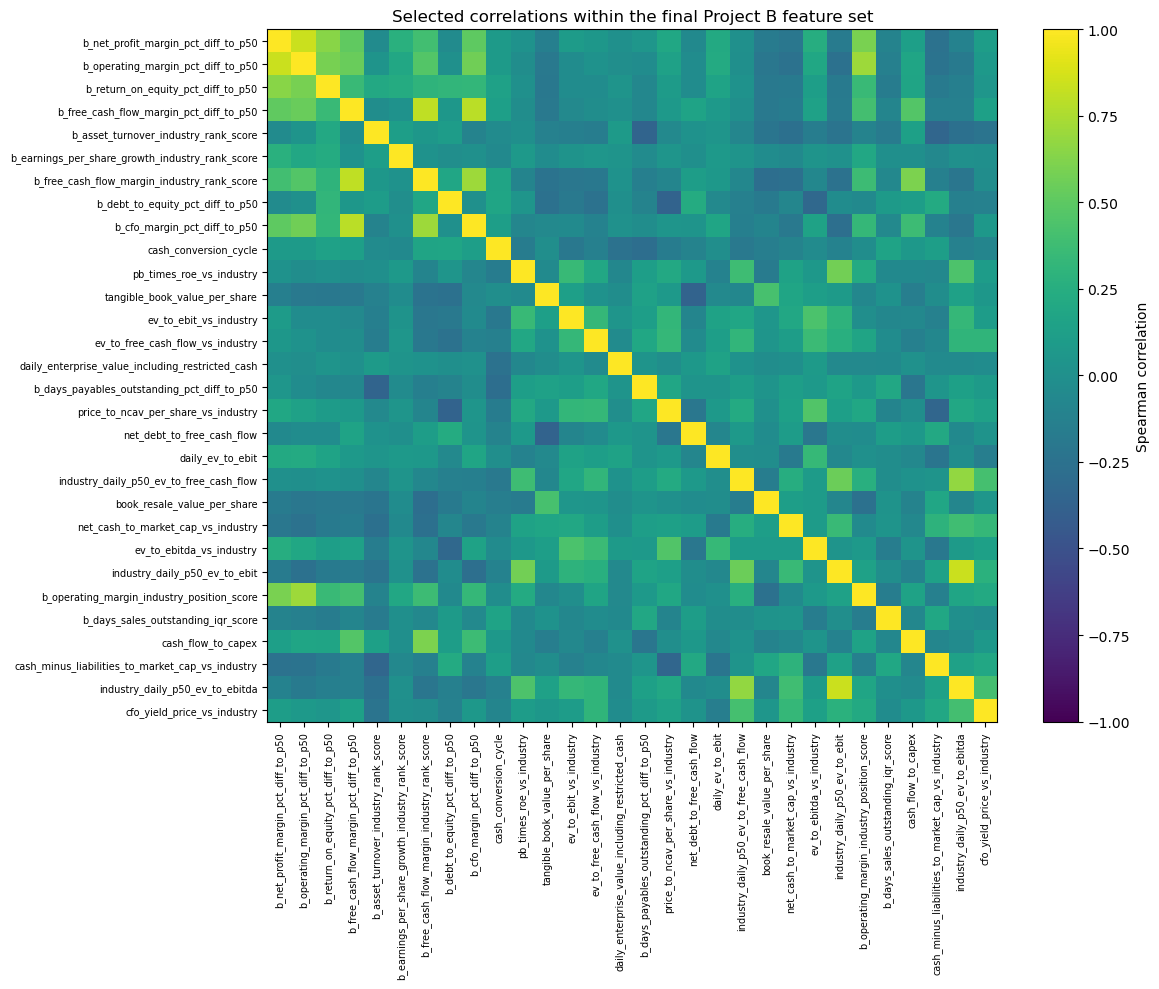

In [11]:
# Heatmap for a manageable high-variance subset of the final Project B features.
selected_corr_features = (
    final_feature_b_summary
    .query("column in @final_feature_b_features")
    .sort_values("std", ascending=False)
    .head(TOP_CORRELATION_FEATURES)["column"]
    .tolist()
)

if len(selected_corr_features) >= 2:
    selected_corr = (
        df_train[selected_corr_features]
        .apply(pd.to_numeric, errors="coerce")
        .corr(method="spearman")
    )

    plt.figure(figsize=(12, 10))
    image = plt.imshow(selected_corr, aspect="auto", vmin=-1, vmax=1)
    plt.colorbar(image, label="Spearman correlation")
    labels = [
        column.replace("feature__", "")
        for column in selected_corr_features
    ]
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    plt.yticks(range(len(labels)), labels, fontsize=7)
    plt.title("Selected correlations within the final Project B feature set")
    save_current_figure("final_feature_b_selected_correlation_heatmap")
    plt.show()


## 9. Selected distributions from the final Project B feature set

Only a small diagnostic subset is plotted. The complete numerical summary is exported as a table.


,feature
0,feature__b_net_profit_margin_pct_diff_to_p50
1,feature__b_operating_margin_pct_diff_to_p50
2,feature__b_return_on_equity_pct_diff_to_p50
3,feature__b_free_cash_flow_margin_pct_diff_to_p50
4,feature__b_asset_turnover_industry_rank_score
5,feature__b_earnings_per_share_growth_industry_...
6,feature__b_free_cash_flow_margin_industry_rank...
7,feature__b_debt_to_equity_pct_diff_to_p50
8,feature__b_cfo_margin_pct_diff_to_p50
9,feature__cash_conversion_cycle


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\final_feature_b_features_selected_for_distribution_plots.csv
Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_net_profit_margin_pct_diff_to_p50.png


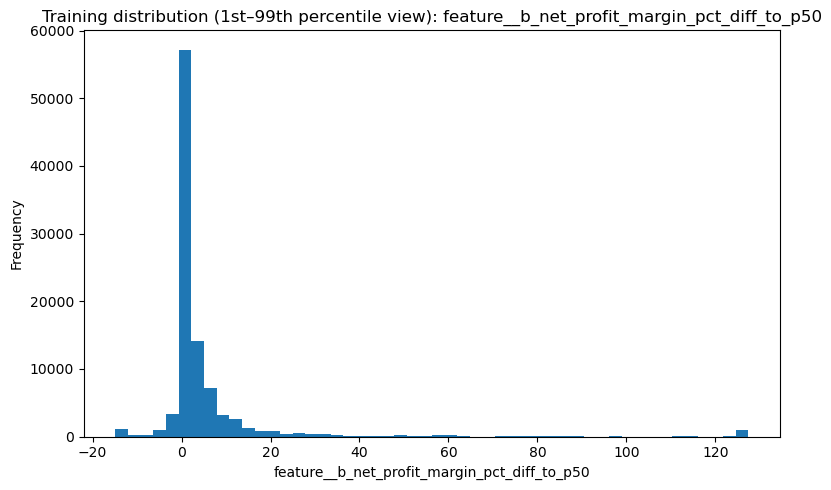

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_operating_margin_pct_diff_to_p50.png


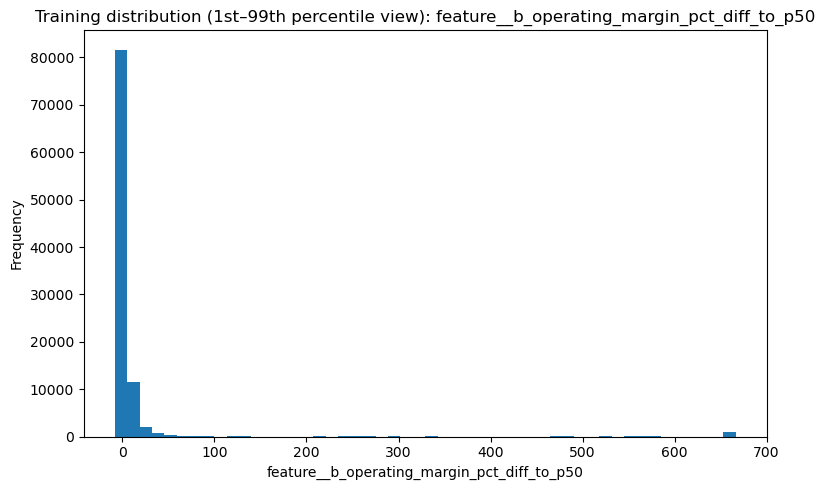

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_return_on_equity_pct_diff_to_p50.png


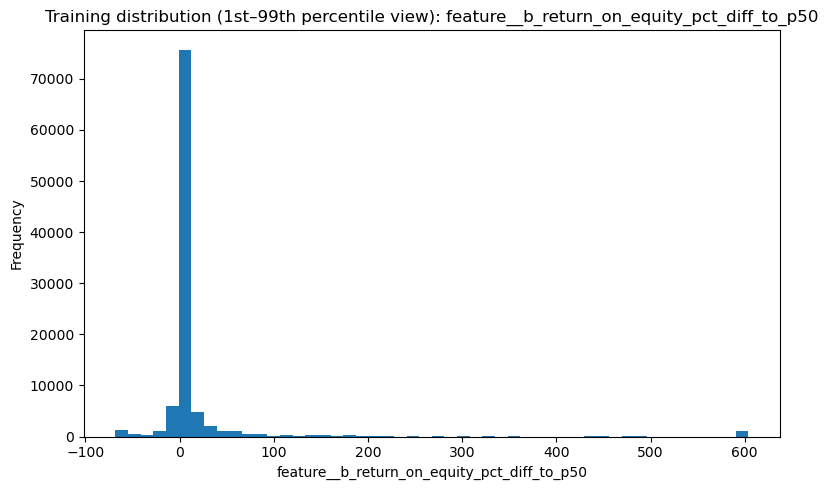

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_free_cash_flow_margin_pct_diff_to_p50.png


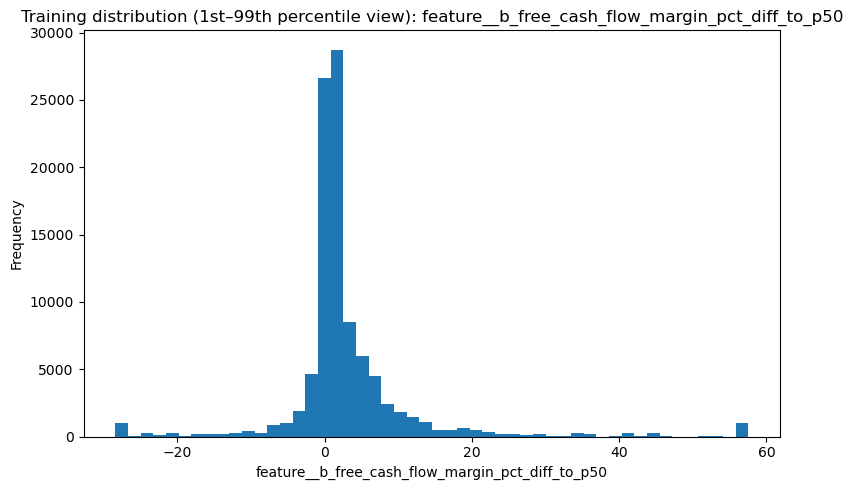

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_asset_turnover_industry_rank_score.png


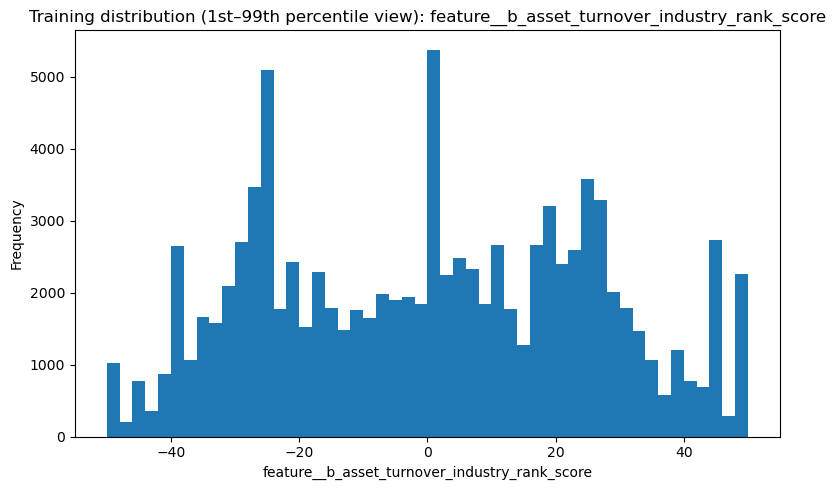

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_earnings_per_share_growth_industry_rank_score.png


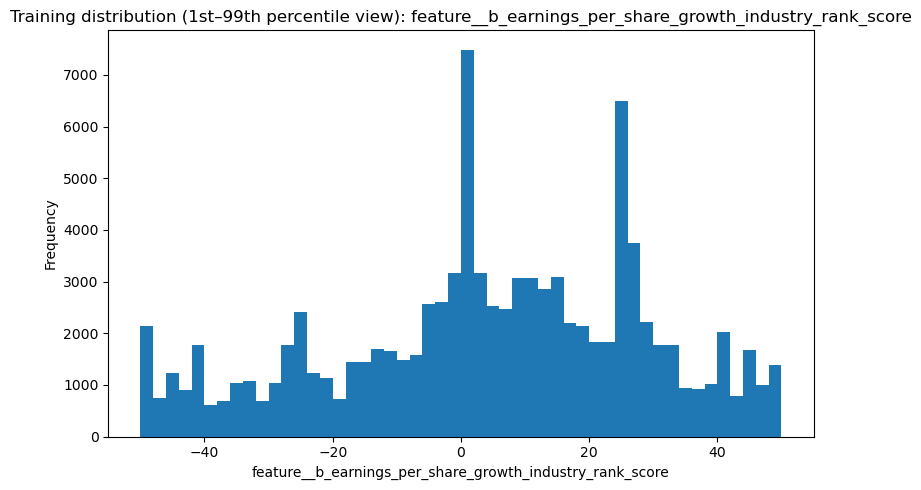

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_free_cash_flow_margin_industry_rank_score.png


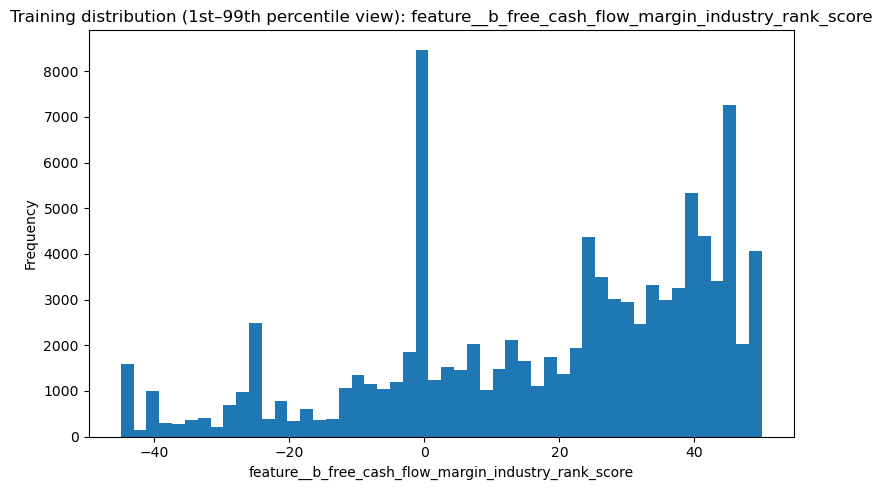

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_debt_to_equity_pct_diff_to_p50.png


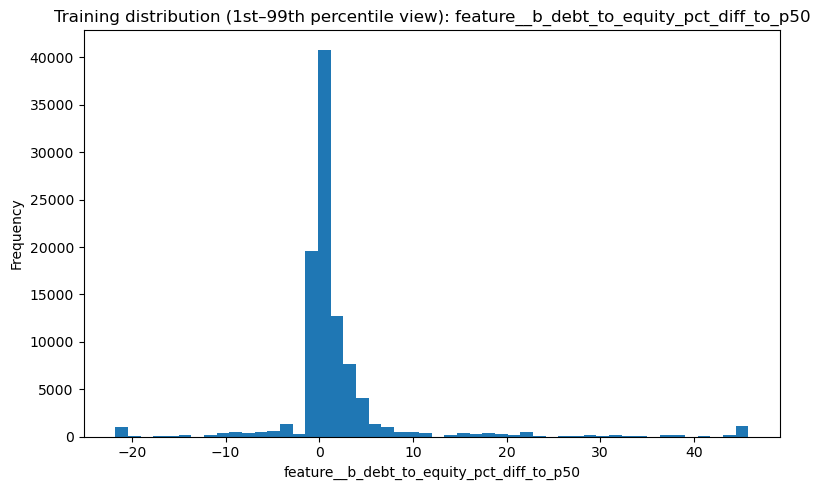

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_cfo_margin_pct_diff_to_p50.png


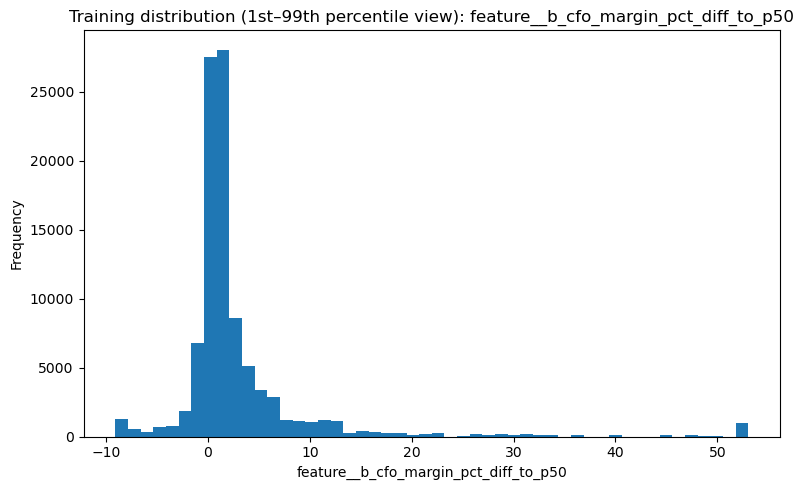

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_cash_conversion_cycle.png


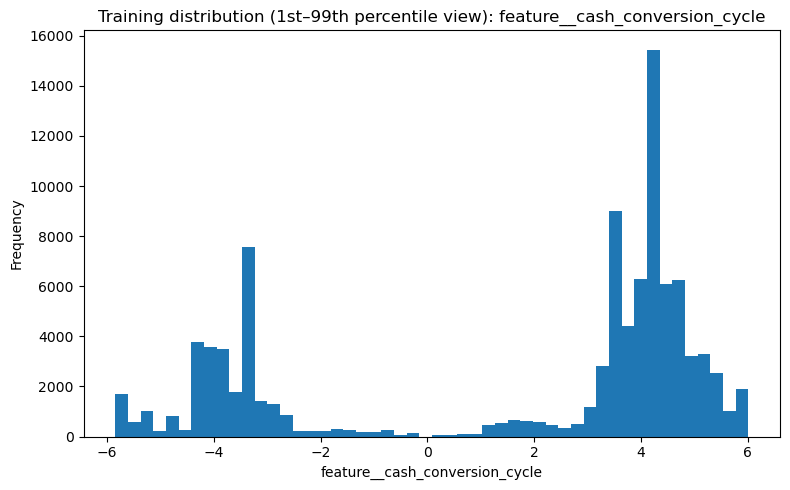

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_pb_times_roe_vs_industry.png


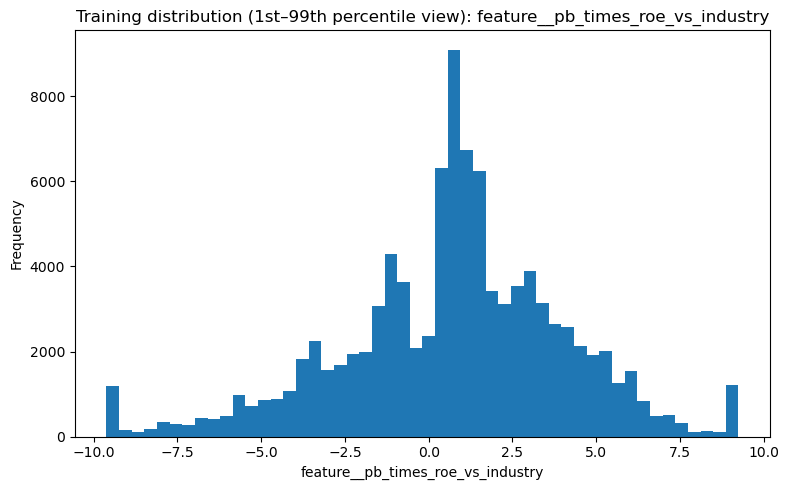

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_tangible_book_value_per_share.png


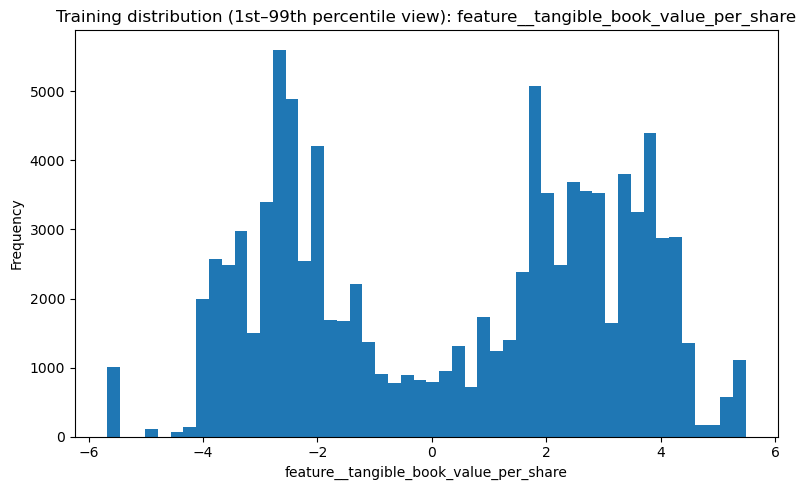

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_ev_to_ebit_vs_industry.png


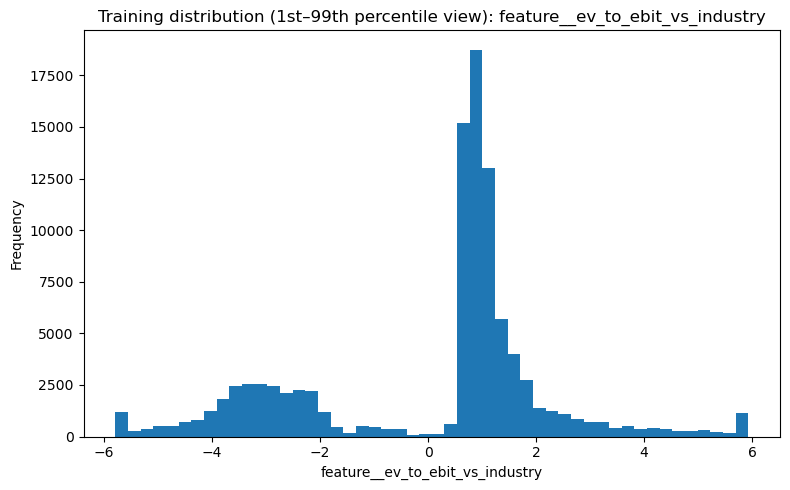

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_ev_to_free_cash_flow_vs_industry.png


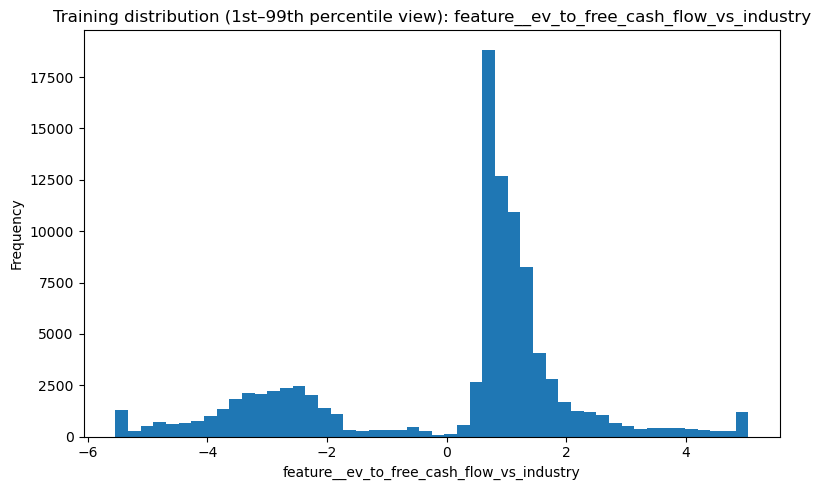

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_daily_enterprise_value_including_restricted_cash.png


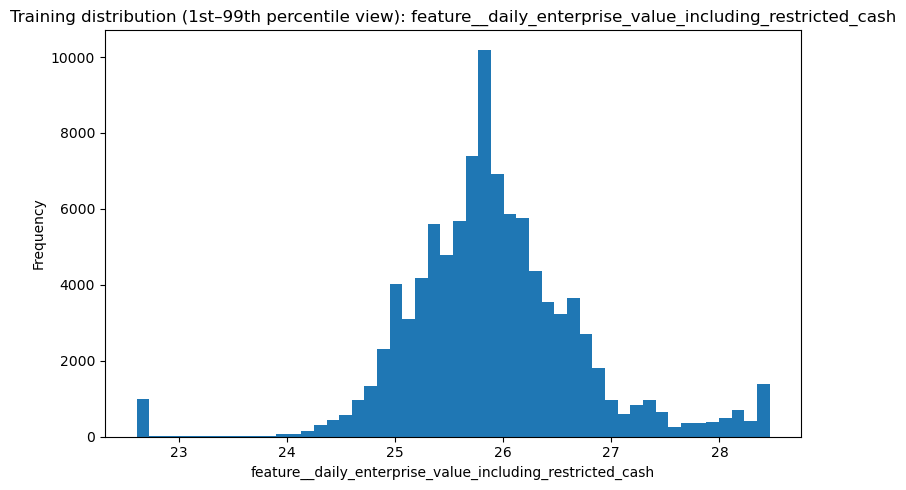

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_b_days_payables_outstanding_pct_diff_to_p50.png


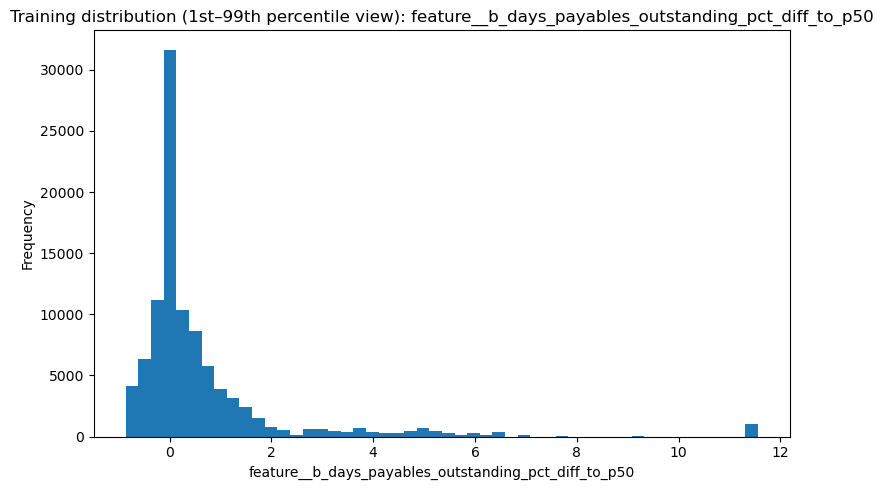

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_price_to_ncav_per_share_vs_industry.png


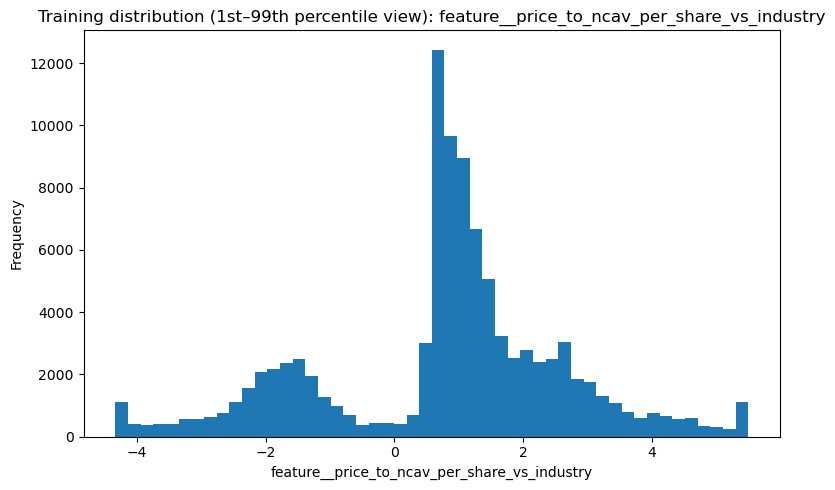

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_net_debt_to_free_cash_flow.png


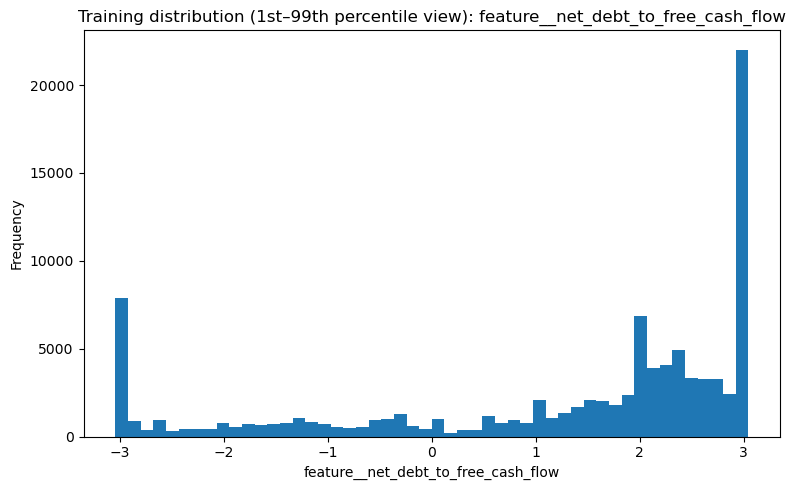

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_daily_ev_to_ebit.png


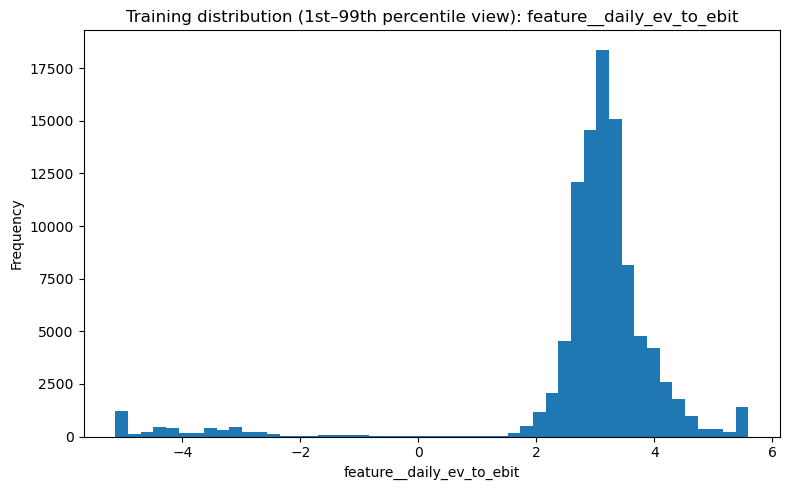

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\final_feature_b_histogram_feature_industry_daily_p50_ev_to_free_cash_flow.png


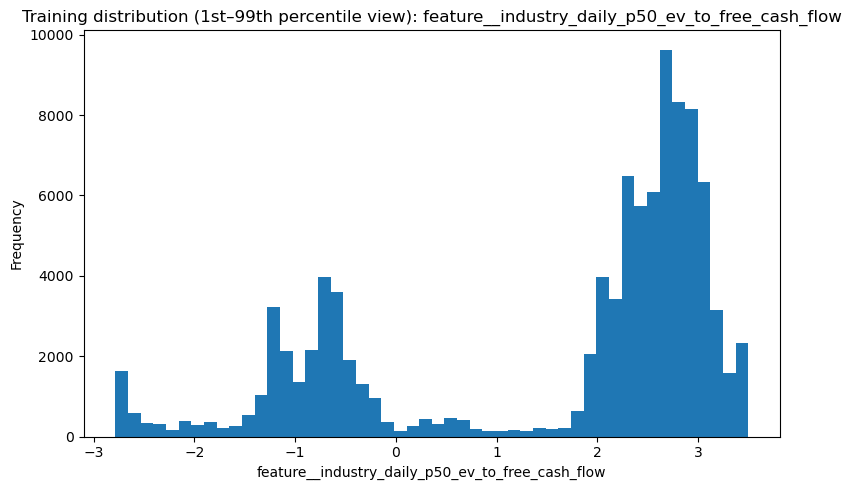

In [12]:
plot_features = (
    final_feature_b_summary[
        final_feature_b_summary["column"].isin(final_feature_b_features)
        & ~final_feature_b_summary["is_constant"]
    ]
    .sort_values(["missing_rate", "std"], ascending=[True, False])
    .head(TOP_VARIABLE_FEATURES_TO_PLOT)["column"]
    .tolist()
)

export_table(
    "final_feature_b_features_selected_for_distribution_plots",
    pd.DataFrame({"feature": plot_features})
)

for column in plot_features:
    values = pd.to_numeric(df_train[column], errors="coerce")
    values = values[np.isfinite(values)].dropna()

    if values.empty:
        continue

    # Clip plots only, not the data used in modelling.
    lower = values.quantile(0.01)
    upper = values.quantile(0.99)
    plotted_values = values.clip(lower=lower, upper=upper)

    plt.figure(figsize=(8, 5))
    plt.hist(plotted_values, bins=HISTOGRAM_BINS)
    plt.title(f"Training distribution (1st–99th percentile view): {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    save_current_figure(f"final_feature_b_histogram_{column}")
    plt.show()


## 10. Final Project B coverage across tickers and years

These checks identify features that are unavailable for particular securities or periods, and distinguish daily-changing from slow-moving or nearly static inputs.


In [13]:
coverage_rows = []

for feature in final_feature_b_features:
    numeric_values = pd.to_numeric(df_train[feature], errors="coerce")

    ticker_missing = (
        pd.DataFrame({
            "ticker": df_train[TICKER_COL],
            "is_missing": numeric_values.isna()
        })
        .groupby("ticker", dropna=False)["is_missing"]
        .mean()
    )

    year_missing = (
        pd.DataFrame({
            "year": df_train[YEAR_COL],
            "is_missing": numeric_values.isna()
        })
        .groupby("year", dropna=False)["is_missing"]
        .mean()
    )

    # Estimate within-ticker update frequency after chronological sorting.
    temp = pd.DataFrame({
        "ticker": df_train[TICKER_COL],
        "date": df_train[DATE_COL],
        "value": numeric_values
    }).sort_values(["ticker", "date"])

    previous = temp.groupby("ticker")["value"].shift(1)
    comparable = temp["value"].notna() & previous.notna()
    changed = comparable & temp["value"].ne(previous)

    change_rate = (
        changed.sum() / comparable.sum()
        if comparable.sum() > 0
        else np.nan
    )

    unique_per_ticker = (
        temp.groupby("ticker")["value"]
        .nunique(dropna=True)
    )

    coverage_rows.append({
        "feature": feature,
        "overall_missing_rate": numeric_values.isna().mean(),
        "max_ticker_missing_rate": ticker_missing.max(),
        "max_year_missing_rate": year_missing.max(),
        "tickers_fully_missing": int((ticker_missing == 1).sum()),
        "years_fully_missing": int((year_missing == 1).sum()),
        "median_unique_values_per_ticker": unique_per_ticker.median(),
        "mean_unique_values_per_ticker": unique_per_ticker.mean(),
        "within_ticker_change_rate": change_rate
    })

final_feature_b_coverage = pd.DataFrame(coverage_rows)

def assign_update_frequency(change_rate):
    if pd.isna(change_rate):
        return "unknown"
    if change_rate < 0.001:
        return "almost static"
    if change_rate < 0.05:
        return "slow-moving"
    return "frequently changing"

final_feature_b_coverage["update_frequency_group"] = (
    final_feature_b_coverage["within_ticker_change_rate"]
    .map(assign_update_frequency)
)

export_table(
    "final_feature_b_ticker_year_coverage_and_change_rate",
    final_feature_b_coverage,
    display_table=False
)

update_frequency_summary = (
    final_feature_b_coverage["update_frequency_group"]
    .value_counts(dropna=False)
    .rename_axis("update_frequency_group")
    .reset_index(name="n_features")
)

export_table(
    "final_feature_b_update_frequency_summary",
    update_frequency_summary
)

display(update_frequency_summary)

display(
    final_feature_b_coverage
    .sort_values(
        ["tickers_fully_missing", "max_ticker_missing_rate"],
        ascending=False
    )
    .head(20)
)


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\final_feature_b_ticker_year_coverage_and_change_rate.csv


,update_frequency_group,n_features
0,slow-moving,128
1,almost static,75
2,frequently changing,67


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\final_feature_b_update_frequency_summary.csv


,update_frequency_group,n_features
0,slow-moving,128
1,almost static,75
2,frequently changing,67


,feature,overall_missing_rate,max_ticker_missing_rate,max_year_missing_rate,tickers_fully_missing,years_fully_missing,median_unique_values_per_ticker,mean_unique_values_per_ticker,within_ticker_change_rate,update_frequency_group
0,feature__accruals_to_assets,0.0,0.0,0.0,0,0,17.0,16.836735,0.015795,slow-moving
1,feature__asset_turnover,0.0,0.0,0.0,0,0,17.0,16.836735,0.015795,slow-moving
2,feature__avg_daily_turnover,0.0,0.0,0.0,0,0,17.0,16.918367,0.015887,slow-moving
3,feature__b_asset_turnover_excess_over_p99,0.0,0.0,0.0,0,0,1.0,1.377551,0.000498,almost static
4,feature__b_asset_turnover_industry_rank_score,0.0,0.0,0.0,0,0,17.0,15.724490,0.015144,slow-moving
5,feature__b_asset_turnover_iqr,0.0,0.0,0.0,0,0,17.0,16.653061,0.015653,slow-moving
6,feature__b_asset_turnover_is_above_p90,0.0,0.0,0.0,0,0,1.0,1.132653,0.000529,almost static
7,feature__b_asset_turnover_is_below_p10,0.0,0.0,0.0,0,0,1.0,1.163265,0.000549,almost static
8,feature__b_asset_turnover_shortfall_below_p1,0.0,0.0,0.0,0,0,1.0,1.173469,0.000224,almost static
9,feature__b_assets_to_equity_excess_over_p99,0.0,0.0,0.0,0,0,1.0,1.724490,0.000865,almost static


## 11. Target EDA — training data only

In [14]:
available_target_columns = target_cols.copy()

# Raw label fallback: include selected raw labels when no derived targets exist.
if not available_target_columns:
    available_target_columns = label_cols.copy()

if SELECTED_TARGETS is not None:
    available_target_columns = [
        column for column in SELECTED_TARGETS
        if column in df_train.columns
    ]

print("Targets included in EDA:")
for column in available_target_columns:
    print(" -", column)

target_summary = numeric_column_summary(
    df_train,
    available_target_columns
)

target_summary["positive_rate"] = [
    (
        pd.to_numeric(df_train[column], errors="coerce") > 0
    ).mean()
    for column in target_summary["column"]
]

target_summary["negative_rate"] = [
    (
        pd.to_numeric(df_train[column], errors="coerce") < 0
    ).mean()
    for column in target_summary["column"]
]

export_table("target_summary_overall", target_summary)


Targets included in EDA:
 - target__pi_hindsight_entry_6bins
 - target__pi_hindsight_entry_long
 - target__pi_hindsight_entry_original
 - target__pi_hindsight_entry_positive
 - target__rl_long_action_binary
 - target__rl_long_action_quality
 - target__rl_long_current_pnl
 - target__rl_long_reward


,column,dtype,n_rows,count_numeric,missing_count,missing_rate,non_finite_count,zero_count,zero_rate,n_unique,...,p01,p05,p25,median,p75,p95,p99,max,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,Int64,98419,98419,0,0.0,0,77569,0.788151,6,...,0.000000,0.0000,0.00000,0.000000,0.000000,5.000000,5.000000,5.0000,0.211849,0.000000
1,target__pi_hindsight_entry_long,float64,98419,98419,0,0.0,0,77569,0.788151,13337,...,0.000000,0.0000,0.00000,0.000000,0.000000,0.573514,1.000000,1.0000,0.211849,0.000000
2,target__pi_hindsight_entry_original,Int64,98419,98419,0,0.0,0,86494,0.878834,2,...,0.000000,0.0000,0.00000,0.000000,0.000000,1.000000,1.000000,1.0000,0.121166,0.000000
3,target__pi_hindsight_entry_positive,Int64,98419,98419,0,0.0,0,77569,0.788151,2,...,0.000000,0.0000,0.00000,0.000000,0.000000,1.000000,1.000000,1.0000,0.211849,0.000000
4,target__rl_long_action_binary,int64,98419,98419,0,0.0,0,50579,0.513915,2,...,0.000000,0.0000,0.00000,0.000000,1.000000,1.000000,1.000000,1.0000,0.486085,0.000000
5,target__rl_long_action_quality,float64,98419,98419,0,0.0,0,0,0.000000,8156,...,-2.534800,-2.5348,-2.40195,-2.172100,1.959500,3.349300,3.349700,3.3498,0.486085,0.513915
6,target__rl_long_current_pnl,float64,98419,98419,0,0.0,0,0,0.000000,63592,...,-1598.287691,-896.6958,-430.78035,-252.627375,408.157475,3281.647079,6057.164814,54391.8375,0.486085,0.513915
7,target__rl_long_reward,float64,98419,98419,0,0.0,0,0,0.000000,11655,...,-3.284800,-3.2848,-3.15240,-2.808700,1.578500,3.118100,3.122800,3.2146,0.486085,0.513915


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\target_summary_overall.csv


,column,dtype,n_rows,count_numeric,missing_count,missing_rate,non_finite_count,zero_count,zero_rate,n_unique,...,p01,p05,p25,median,p75,p95,p99,max,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,Int64,98419,98419,0,0.0,0,77569,0.788151,6,...,0.000000,0.0000,0.00000,0.000000,0.000000,5.000000,5.000000,5.0000,0.211849,0.000000
1,target__pi_hindsight_entry_long,float64,98419,98419,0,0.0,0,77569,0.788151,13337,...,0.000000,0.0000,0.00000,0.000000,0.000000,0.573514,1.000000,1.0000,0.211849,0.000000
2,target__pi_hindsight_entry_original,Int64,98419,98419,0,0.0,0,86494,0.878834,2,...,0.000000,0.0000,0.00000,0.000000,0.000000,1.000000,1.000000,1.0000,0.121166,0.000000
3,target__pi_hindsight_entry_positive,Int64,98419,98419,0,0.0,0,77569,0.788151,2,...,0.000000,0.0000,0.00000,0.000000,0.000000,1.000000,1.000000,1.0000,0.211849,0.000000
4,target__rl_long_action_binary,int64,98419,98419,0,0.0,0,50579,0.513915,2,...,0.000000,0.0000,0.00000,0.000000,1.000000,1.000000,1.000000,1.0000,0.486085,0.000000
5,target__rl_long_action_quality,float64,98419,98419,0,0.0,0,0,0.000000,8156,...,-2.534800,-2.5348,-2.40195,-2.172100,1.959500,3.349300,3.349700,3.3498,0.486085,0.513915
6,target__rl_long_current_pnl,float64,98419,98419,0,0.0,0,0,0.000000,63592,...,-1598.287691,-896.6958,-430.78035,-252.627375,408.157475,3281.647079,6057.164814,54391.8375,0.486085,0.513915
7,target__rl_long_reward,float64,98419,98419,0,0.0,0,0,0.000000,11655,...,-3.284800,-3.2848,-3.15240,-2.808700,1.578500,3.118100,3.122800,3.2146,0.486085,0.513915


Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_distribution_target_pi_hindsight_entry_6bins.png


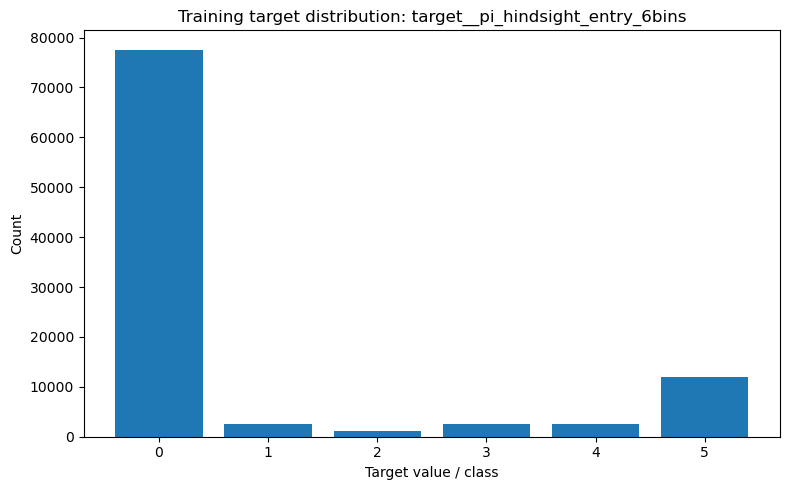

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_distribution_target_pi_hindsight_entry_long.png


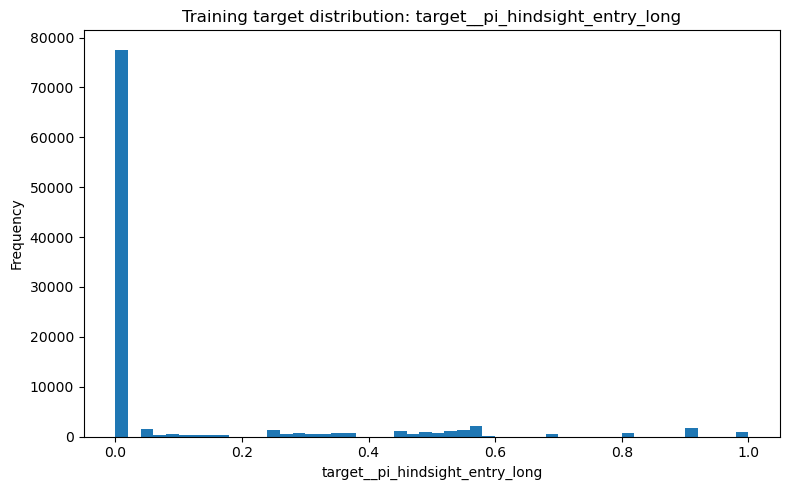

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_distribution_target_pi_hindsight_entry_original.png


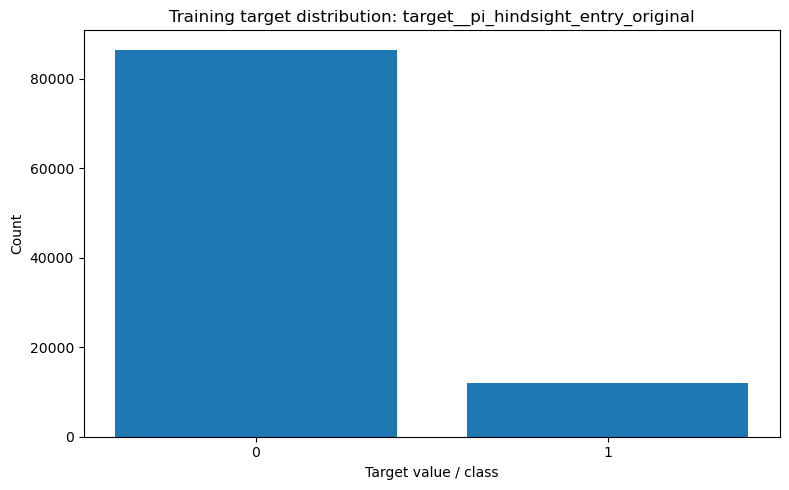

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_distribution_target_pi_hindsight_entry_positive.png


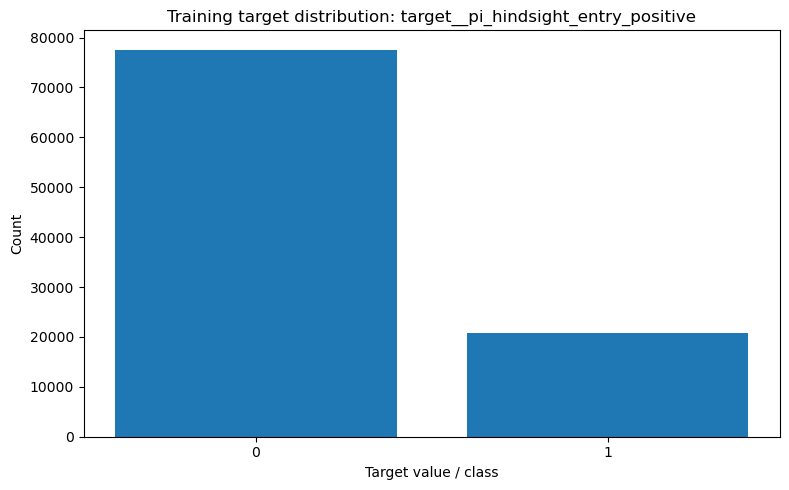

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_distribution_target_rl_long_action_binary.png


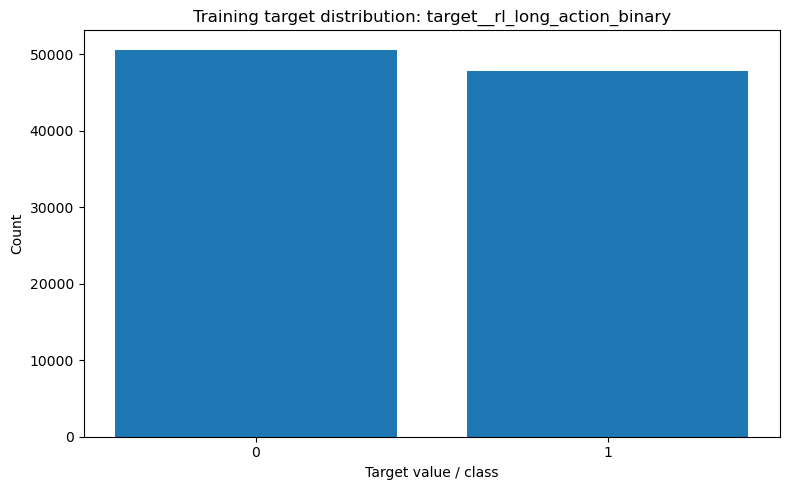

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_distribution_target_rl_long_action_quality.png


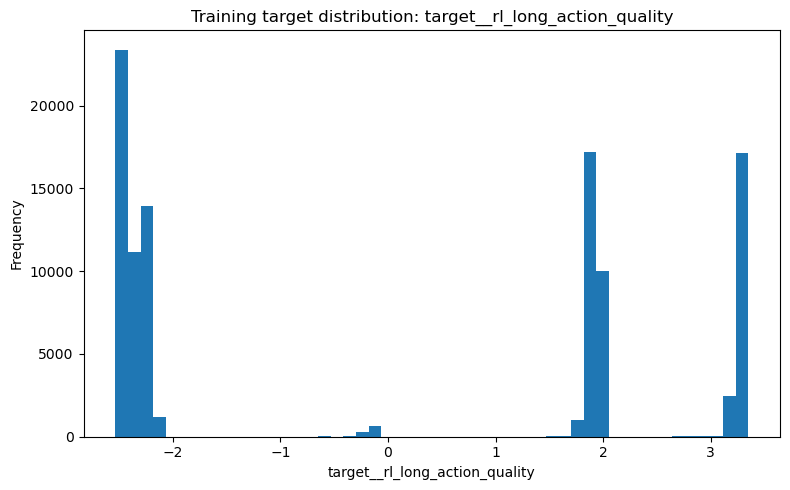

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_distribution_target_rl_long_current_pnl.png


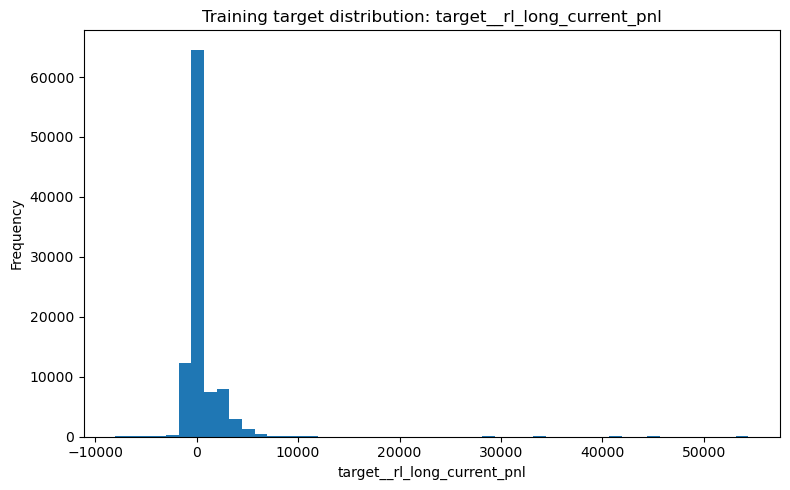

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_distribution_target_rl_long_reward.png


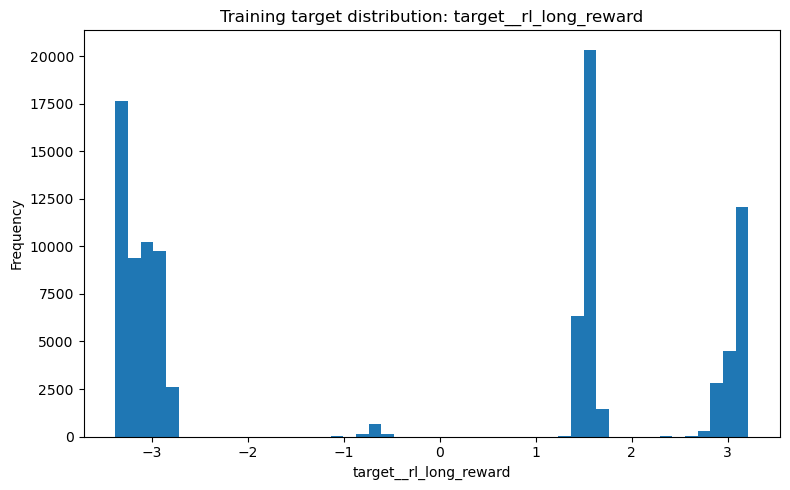

In [15]:
for column in available_target_columns:
    values = pd.to_numeric(df_train[column], errors="coerce").dropna()

    if values.empty:
        continue

    plt.figure(figsize=(8, 5))

    n_unique = values.nunique()
    if n_unique <= 20:
        counts = values.value_counts().sort_index()
        plt.bar(counts.index.astype(str), counts.values)
        plt.xlabel("Target value / class")
        plt.ylabel("Count")
    else:
        plt.hist(values, bins=HISTOGRAM_BINS)
        plt.xlabel(column)
        plt.ylabel("Frequency")

    plt.title(f"Training target distribution: {column}")
    save_current_figure(f"target_distribution_{column}")
    plt.show()


## 12. Target distribution by year (train, validation, and test)

Yearly variation of each modelling target is examined across the **full available
sample (train + validation + test)** to describe how the modelling outcome
changes over time. The primary main-text summary reports a single yearly summary
of the **median** and **mean** current PnL (`target__rl_long_current_pnl`);
equivalent yearly summaries for the alternative targets are exported for
Appendix A.X. The distribution plots show the per-year spread of each target,
with each year coloured by the split it predominantly belongs to, so the
train -> validation -> test transition over time is visible.

,target,year,n_obs,mean,median,std,min,max,zero_rate,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,2020,24650,1.03931,0.0,1.886995,0.0,5.0,0.735132,0.264868,0.0
1,target__pi_hindsight_entry_6bins,2021,24696,0.853782,0.0,1.768902,0.0,5.0,0.790614,0.209386,0.0
2,target__pi_hindsight_entry_6bins,2022,24598,0.665826,0.0,1.578213,0.0,5.0,0.826205,0.173795,0.0
3,target__pi_hindsight_entry_6bins,2023,24475,0.801185,0.0,1.720911,0.0,5.0,0.800817,0.199183,0.0
4,target__pi_hindsight_entry_6bins,2024,24469,0.834811,0.0,1.75083,0.0,5.0,0.793494,0.206506,0.0
5,target__pi_hindsight_entry_6bins,2025,24471,0.819787,0.0,1.730484,0.0,5.0,0.793143,0.206857,0.0
6,target__pi_hindsight_entry_6bins,2026,7671,0.539434,0.0,1.459395,0.0,5.0,0.863903,0.136097,0.0
7,target__pi_hindsight_entry_long,2020,24650,0.12308,0.0,0.252567,0.0,1.0,0.735132,0.264868,0.0
8,target__pi_hindsight_entry_long,2021,24696,0.099532,0.0,0.224878,0.0,1.0,0.790614,0.209386,0.0
9,target__pi_hindsight_entry_long,2022,24598,0.075652,0.0,0.198147,0.0,1.0,0.826205,0.173795,0.0


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\target_summary_by_year.csv


,target,split,year,n_obs,mean,median,std,min,max,zero_rate,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,train,2020,24650,1.03931,0.0,1.886995,0.0,5.0,0.735132,0.264868,0.0
1,target__pi_hindsight_entry_6bins,train,2021,24696,0.853782,0.0,1.768902,0.0,5.0,0.790614,0.209386,0.0
2,target__pi_hindsight_entry_6bins,train,2022,24598,0.665826,0.0,1.578213,0.0,5.0,0.826205,0.173795,0.0
3,target__pi_hindsight_entry_6bins,train,2023,24475,0.801185,0.0,1.720911,0.0,5.0,0.800817,0.199183,0.0
4,target__pi_hindsight_entry_6bins,validation,2024,24469,0.834811,0.0,1.75083,0.0,5.0,0.793494,0.206506,0.0
5,target__pi_hindsight_entry_6bins,test,2025,24471,0.819787,0.0,1.730484,0.0,5.0,0.793143,0.206857,0.0
6,target__pi_hindsight_entry_6bins,test,2026,7671,0.539434,0.0,1.459395,0.0,5.0,0.863903,0.136097,0.0
7,target__pi_hindsight_entry_long,train,2020,24650,0.12308,0.0,0.252567,0.0,1.0,0.735132,0.264868,0.0
8,target__pi_hindsight_entry_long,train,2021,24696,0.099532,0.0,0.224878,0.0,1.0,0.790614,0.209386,0.0
9,target__pi_hindsight_entry_long,train,2022,24598,0.075652,0.0,0.198147,0.0,1.0,0.826205,0.173795,0.0


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\target_summary_by_year_by_split.csv


,year,n_obs,median,mean
0,2020,24650,183.183,583.641939
1,2021,24696,169.370025,322.401348
2,2022,24598,-303.227925,76.150827
3,2023,24475,-263.263,770.12022
4,2024,24469,172.153381,412.550911
5,2025,24471,-122.494873,238.820358
6,2026,7671,-10.604,79.729904


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\current_pnl_median_mean_by_year.csv
Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_boxplot_target_rl_long_current_pnl.png


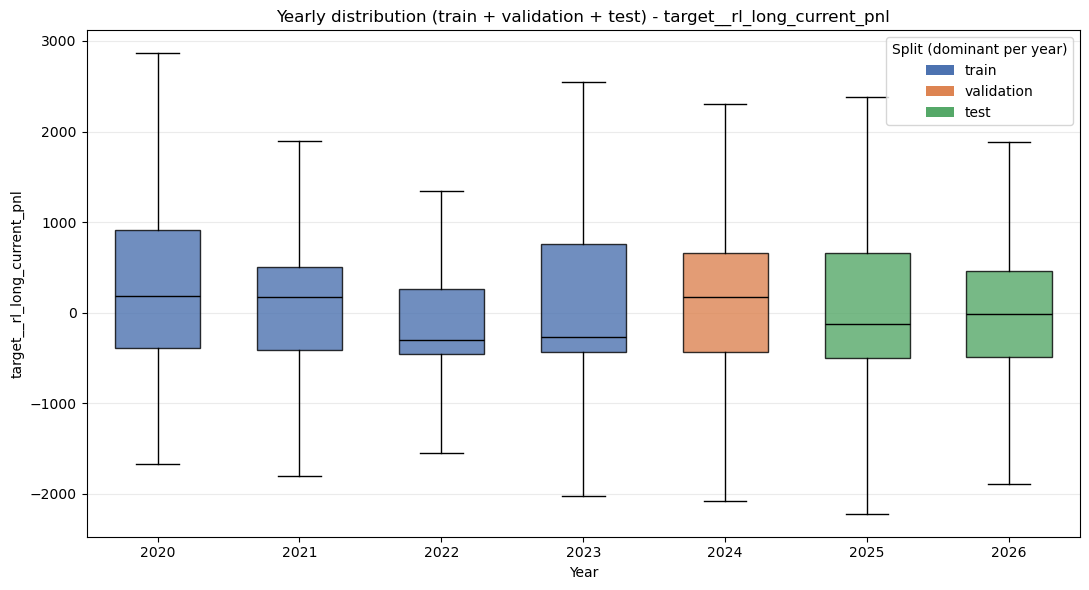

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_mean_median_target_rl_long_current_pnl.png


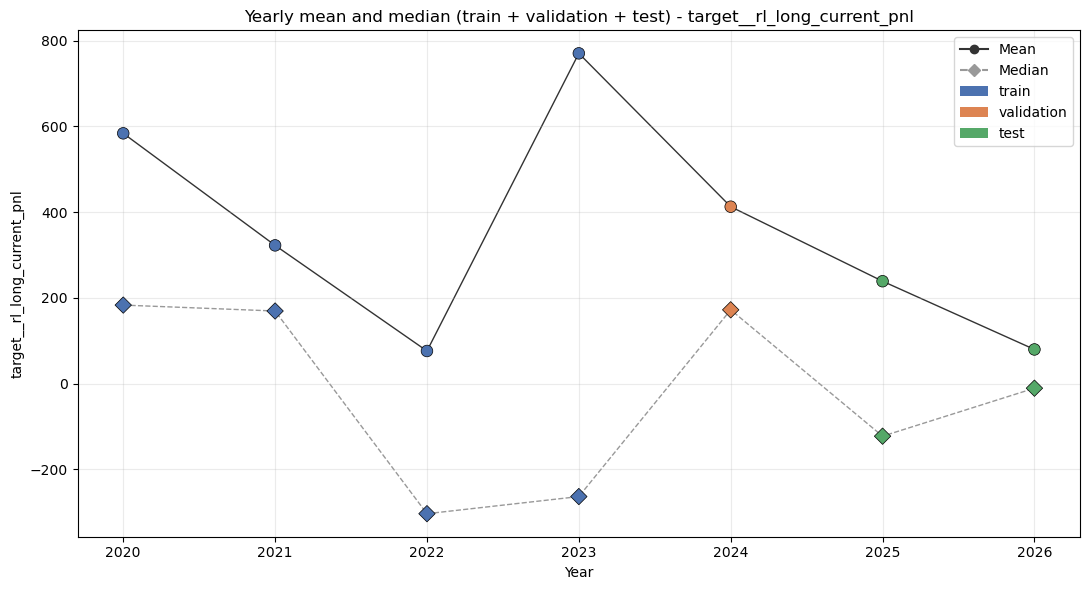

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_boxplot_target_pi_hindsight_entry_6bins.png


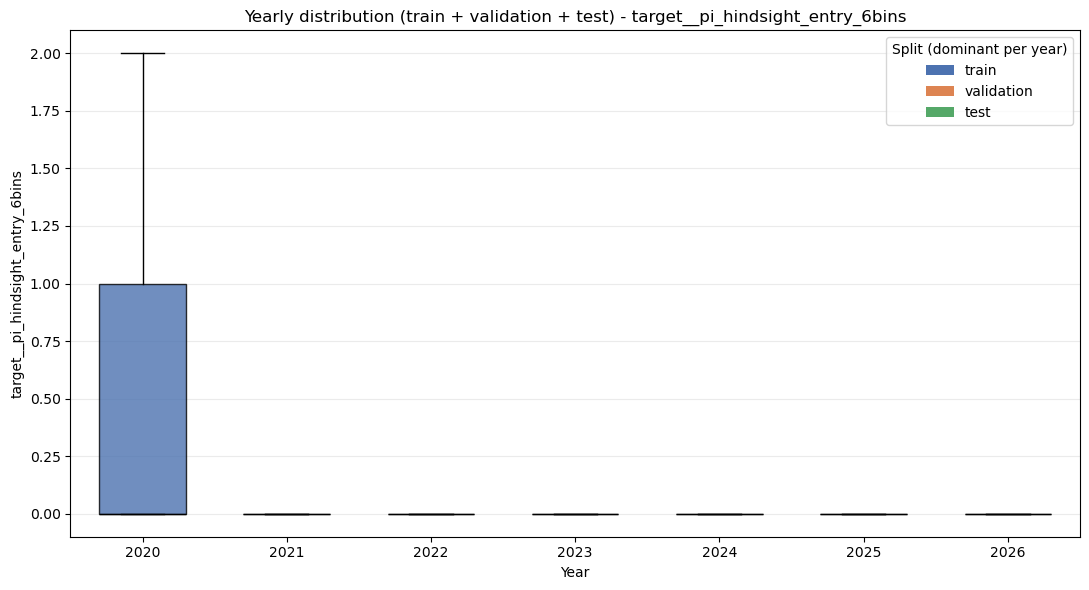

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_mean_median_target_pi_hindsight_entry_6bins.png


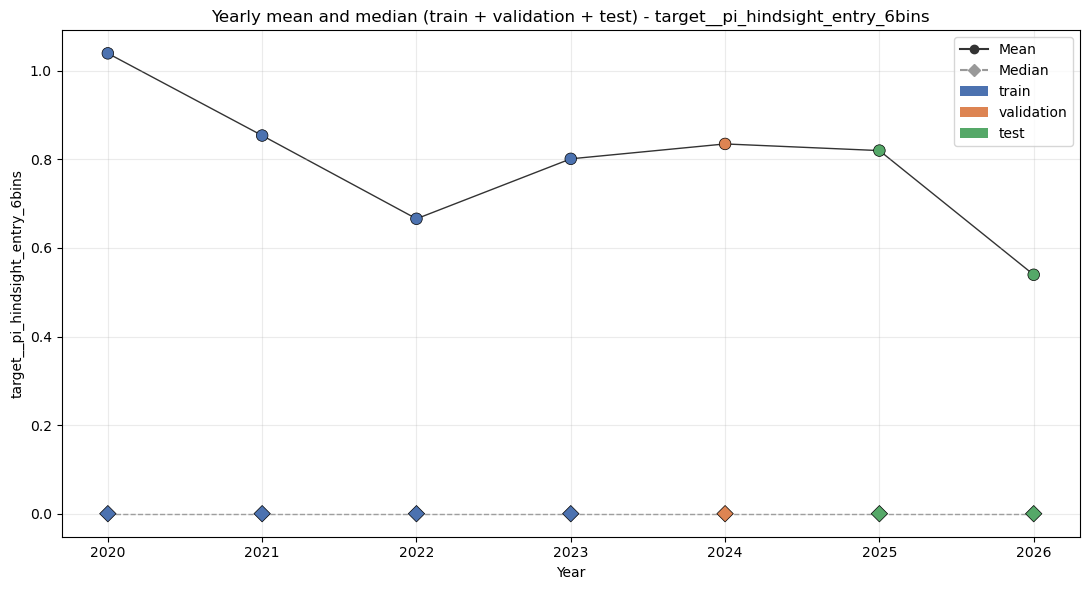

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_boxplot_target_pi_hindsight_entry_long.png


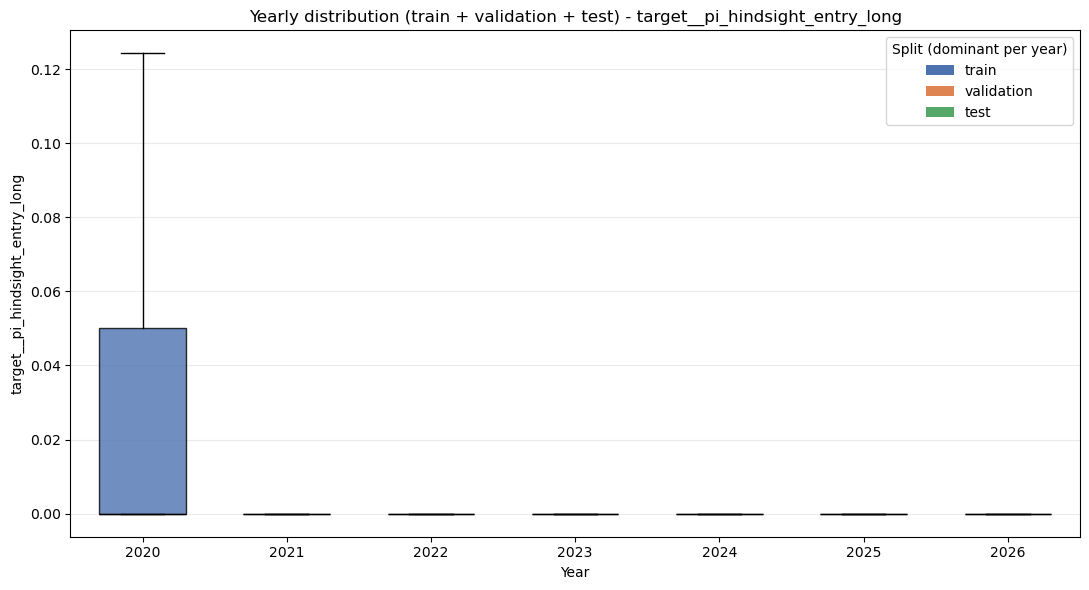

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_mean_median_target_pi_hindsight_entry_long.png


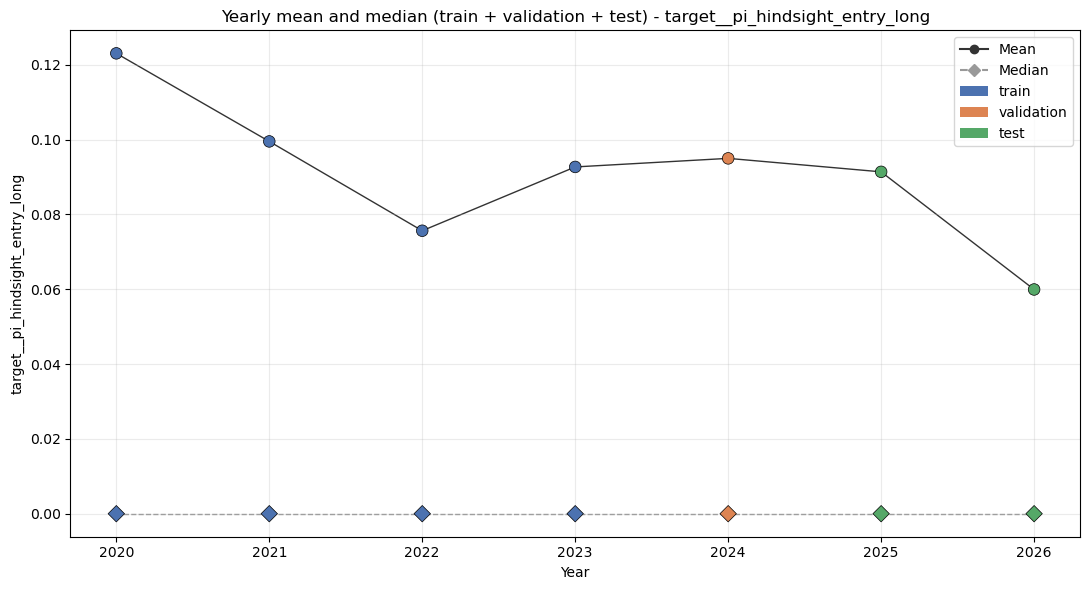

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_boxplot_target_pi_hindsight_entry_original.png


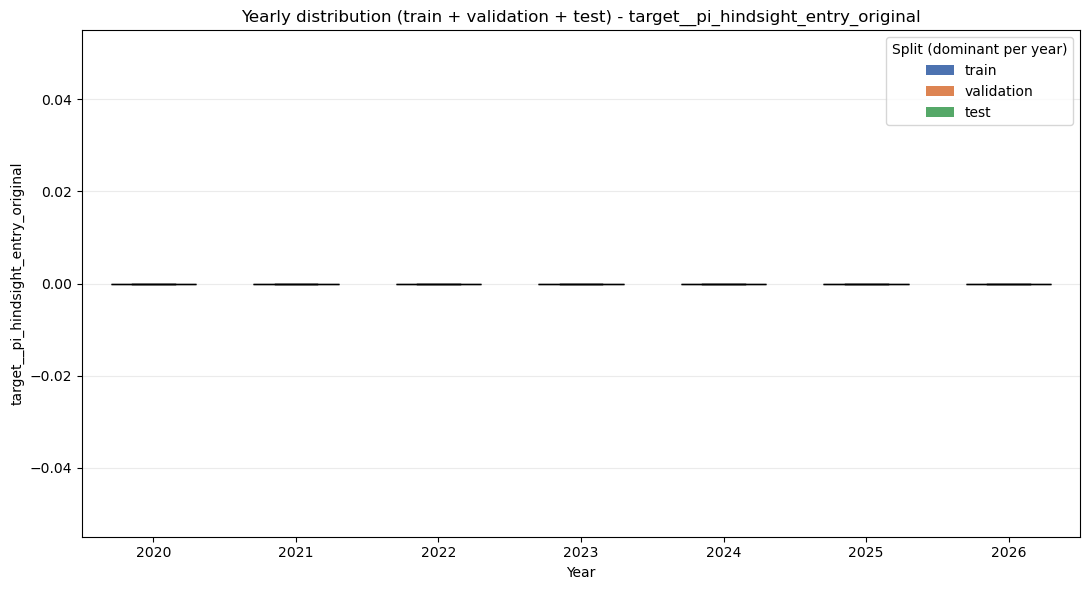

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_mean_median_target_pi_hindsight_entry_original.png


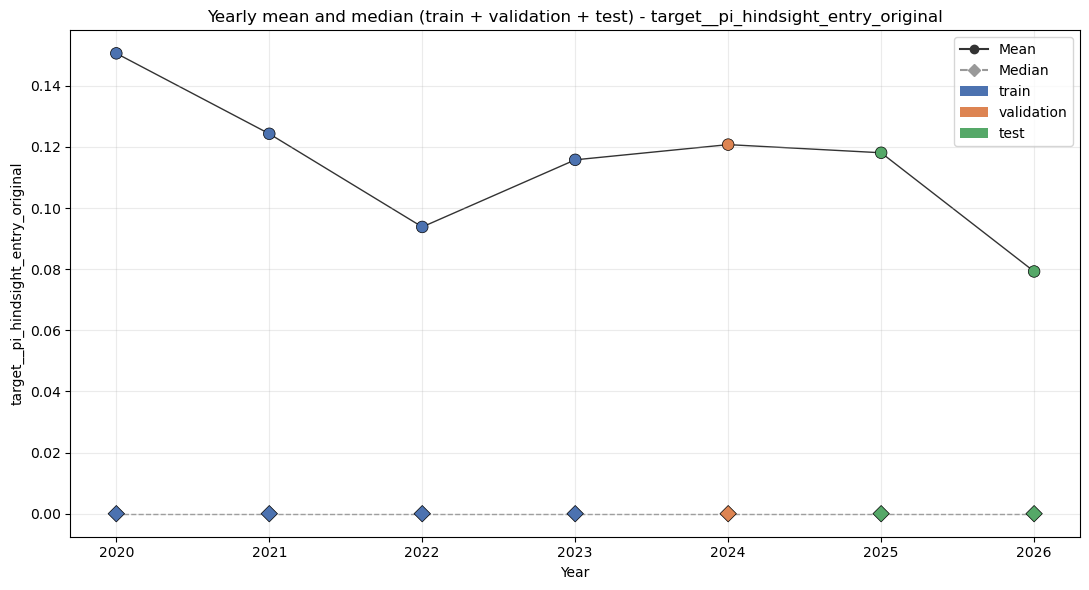

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_boxplot_target_pi_hindsight_entry_positive.png


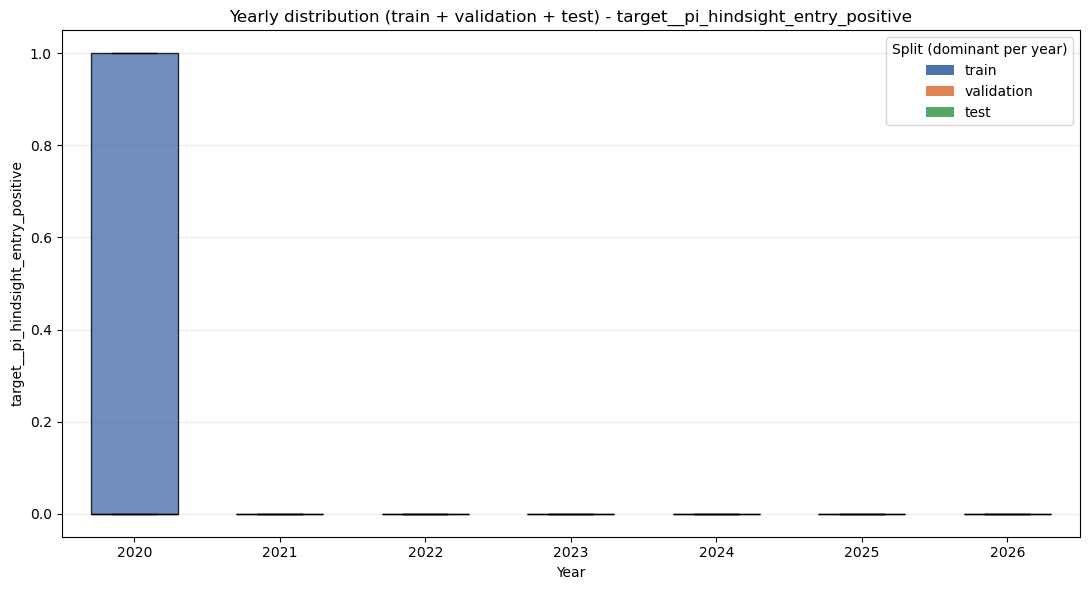

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_mean_median_target_pi_hindsight_entry_positive.png


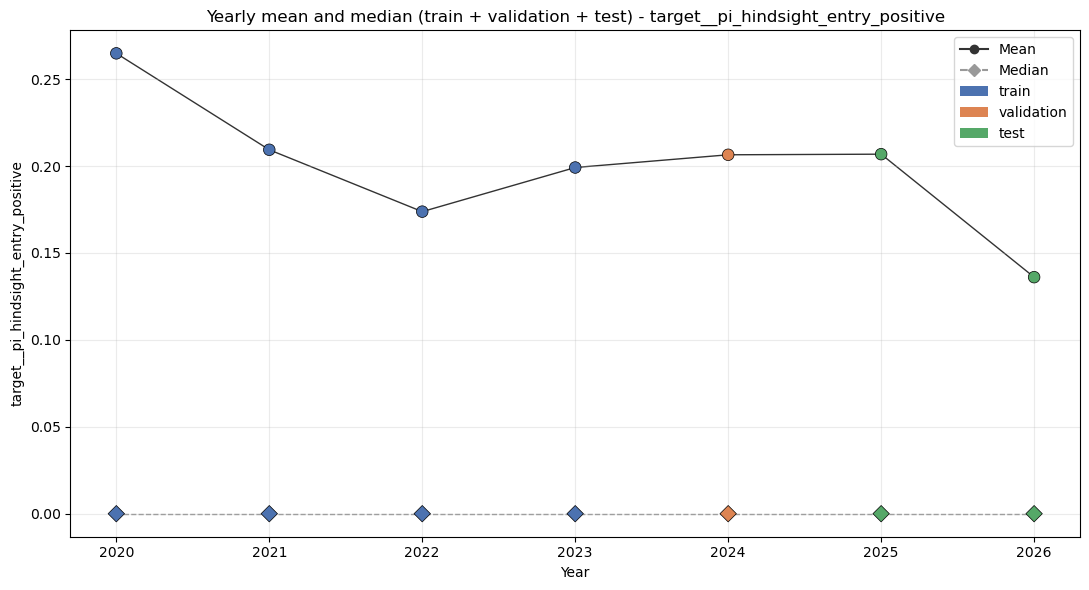

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_boxplot_target_rl_long_action_binary.png


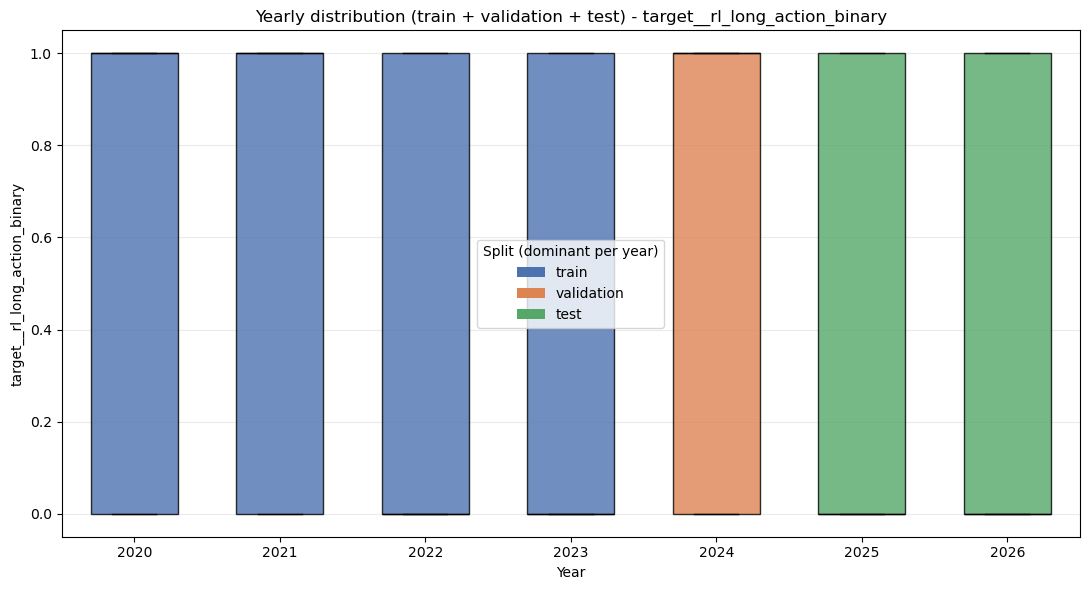

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_mean_median_target_rl_long_action_binary.png


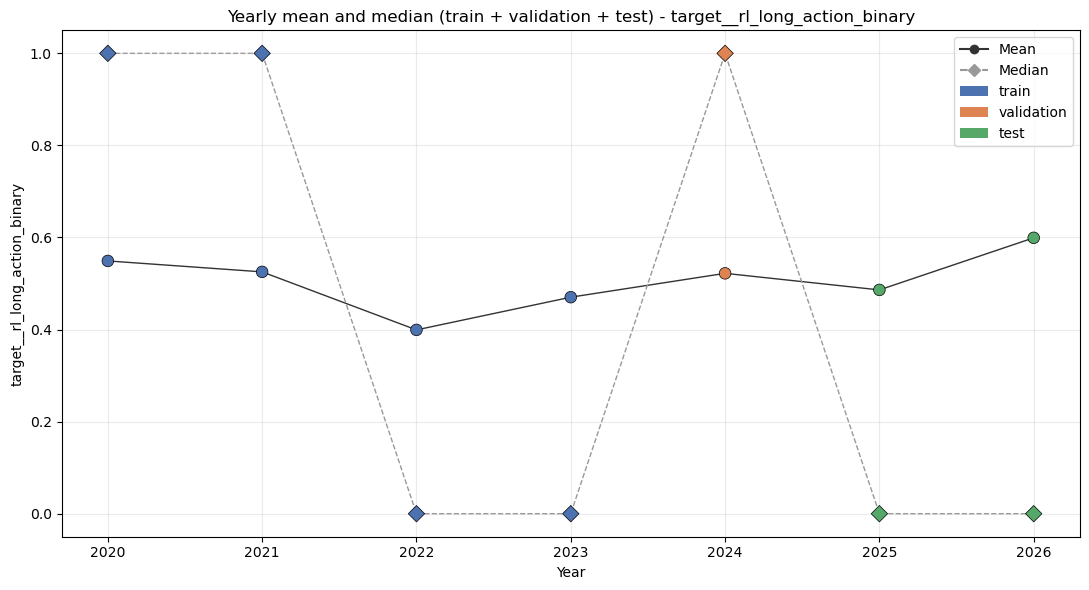

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_boxplot_target_rl_long_action_quality.png


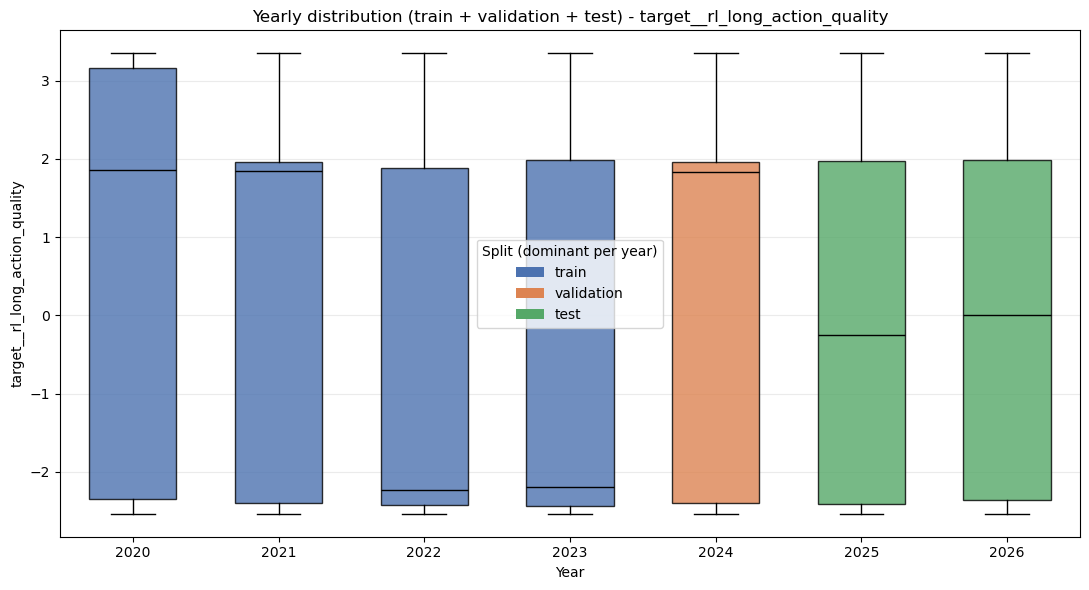

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_mean_median_target_rl_long_action_quality.png


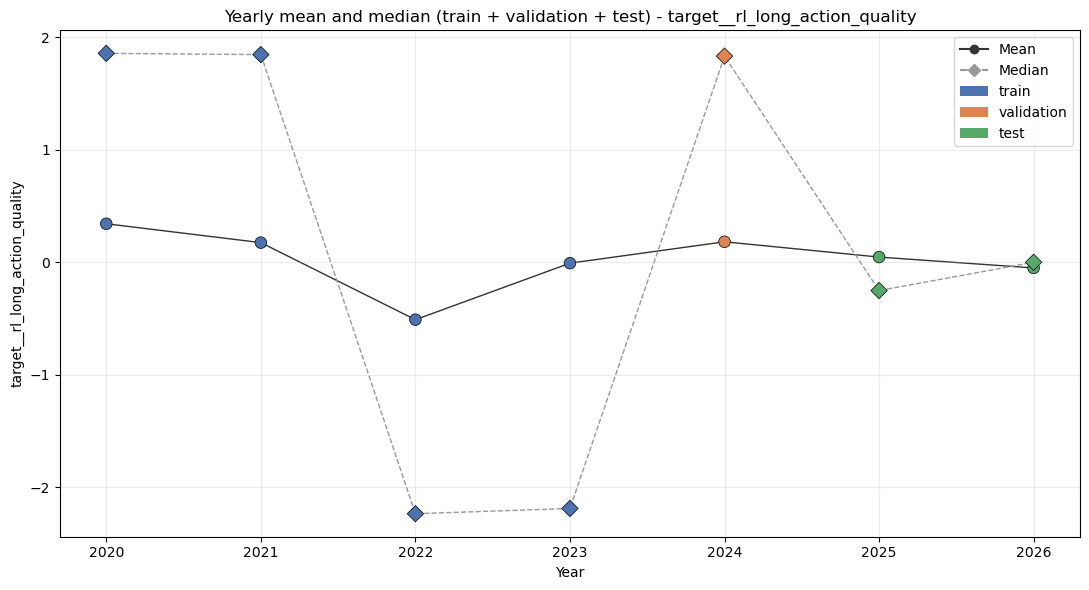

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_boxplot_target_rl_long_reward.png


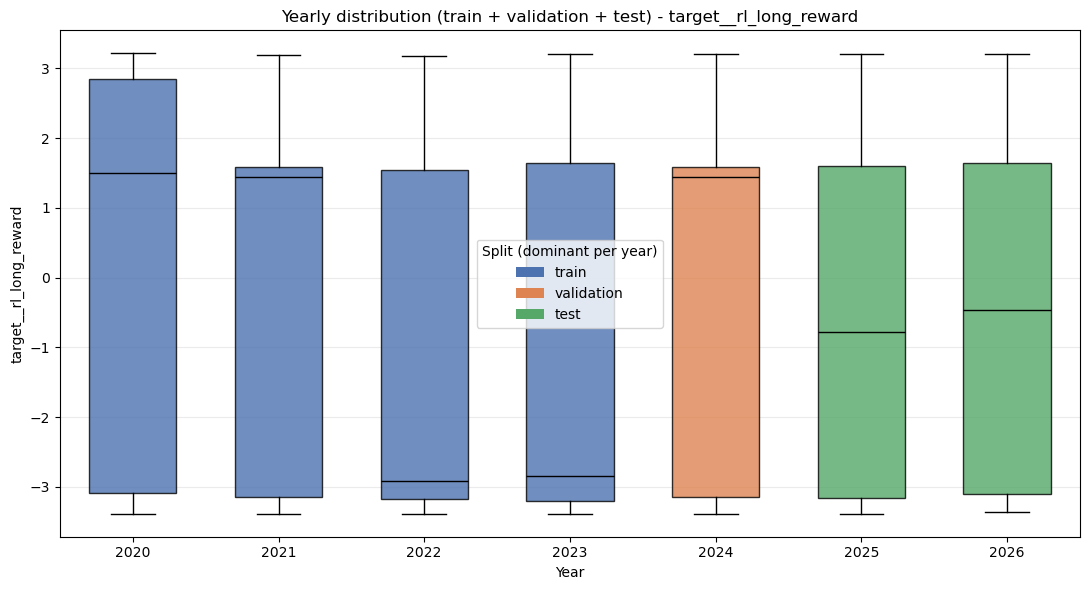

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_yearly_mean_median_target_rl_long_reward.png


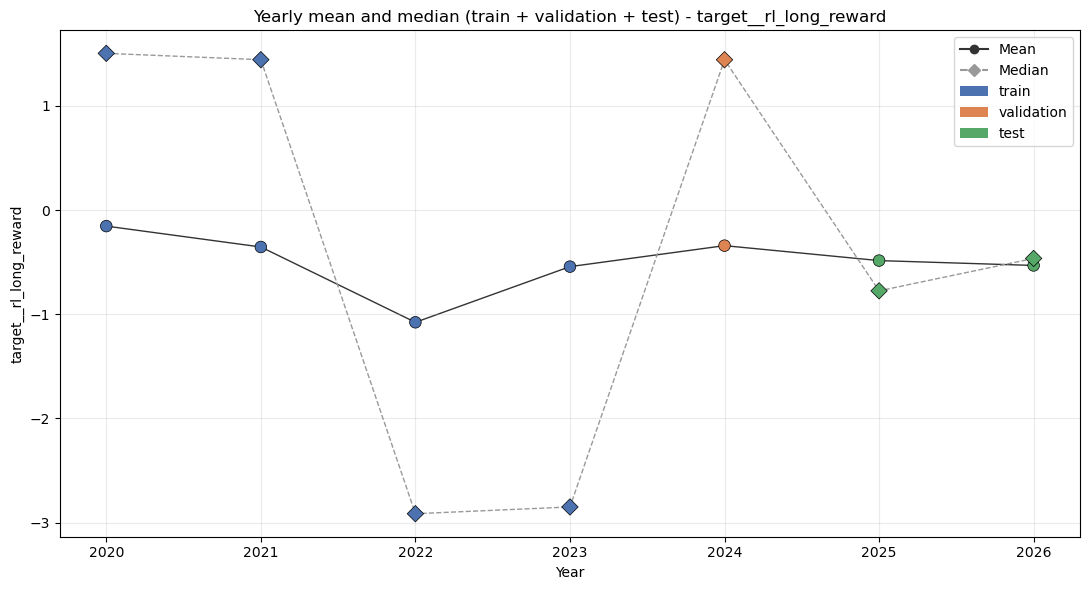

In [16]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Temporal EDA uses the combined sample spanning every available split.
temporal_frame = df_all if "df_all" in globals() else df_train

# Consistent colour per split across every temporal plot.
SPLIT_COLOURS = {
    "train": "#4C72B0",
    "validation": "#DD8452",
    "test": "#55A868",
}

# Locate the current-PnL target for the primary main-text reporting.
current_pnl_target = first_existing_column(
    temporal_frame,
    [
        "target__rl_long_current_pnl",
        "label__rl.long.current_pnl",
        "label__current_pnl",
    ],
)


def summarise_yearly(frame, column, group_cols):
    """Per-group yearly summary statistics and sign rates for one target."""
    values = frame[group_cols + [column]].copy()
    values[column] = pd.to_numeric(values[column], errors="coerce")
    values = values.dropna(subset=group_cols + [column])
    if values.empty:
        return pd.DataFrame()

    summary = (
        values.groupby(group_cols, observed=True)[column]
        .agg(n_obs="size", mean="mean", median="median",
             std="std", min="min", max="max")
        .reset_index()
    )
    rates = (
        values.assign(
            _zero=(values[column] == 0),
            _pos=(values[column] > 0),
            _neg=(values[column] < 0),
        )
        .groupby(group_cols, observed=True)[["_zero", "_pos", "_neg"]]
        .mean()
        .rename(columns={"_zero": "zero_rate",
                         "_pos": "positive_rate",
                         "_neg": "negative_rate"})
        .reset_index()
    )
    summary = summary.merge(rates, on=group_cols, how="left")
    summary.insert(0, "target", column)
    return summary


# --- Yearly summaries: combined (primary) and per split (appendix) -----------
combined_rows, split_rows = [], []
for column in available_target_columns:
    combined_rows.append(summarise_yearly(temporal_frame, column, [YEAR_COL]))
    split_rows.append(summarise_yearly(temporal_frame, column, [SPLIT_COL, YEAR_COL]))

target_by_year = (
    pd.concat([r for r in combined_rows if not r.empty], ignore_index=True)
    if any(not r.empty for r in combined_rows) else pd.DataFrame()
)
target_by_year_split = (
    pd.concat([r for r in split_rows if not r.empty], ignore_index=True)
    if any(not r.empty for r in split_rows) else pd.DataFrame()
)

# Combined yearly summary across all splits (single summary for the main text).
export_table("target_summary_by_year", target_by_year)
# Per-split yearly summary retained for the appendix.
export_table("target_summary_by_year_by_split", target_by_year_split)

# Primary main-text table: yearly median and mean of the current-PnL target.
if current_pnl_target is not None and not target_by_year.empty:
    current_pnl_by_year = (
        target_by_year[target_by_year["target"] == current_pnl_target]
        [[YEAR_COL, "n_obs", "median", "mean"]]
        .sort_values(YEAR_COL)
        .reset_index(drop=True)
    )
    export_table("current_pnl_median_mean_by_year", current_pnl_by_year)

# Map each year to the split contributing the most observations that year
# (used only to colour the plots when splits are time-disjoint).
year_split_counts = (
    temporal_frame.dropna(subset=[YEAR_COL])
    .groupby([YEAR_COL, SPLIT_COL], observed=True)
    .size()
    .reset_index(name="n")
)
dominant_split_by_year = (
    year_split_counts.sort_values("n")
    .drop_duplicates(subset=[YEAR_COL], keep="last")
    .set_index(YEAR_COL)[SPLIT_COL]
    .astype(str)
    .to_dict()
)


def _split_legend_handles():
    return [
        Patch(facecolor=SPLIT_COLOURS.get(s, "#BBBBBB"), edgecolor="none", label=s)
        for s in _split_order if s in SPLIT_COLOURS
    ]


def plot_yearly_boxplot(column):
    """Per-year distribution of a target across all splits, coloured by split."""
    values = temporal_frame[[YEAR_COL, column]].copy()
    values[column] = pd.to_numeric(values[column], errors="coerce")
    values = values.dropna(subset=[YEAR_COL, column])
    if values.empty:
        return

    years = sorted(values[YEAR_COL].unique())
    data = [values.loc[values[YEAR_COL] == y, column].to_numpy() for y in years]

    plt.figure(figsize=(11, 6))
    box = plt.boxplot(
        data, positions=range(len(years)), widths=0.6,
        patch_artist=True, showfliers=False,
    )
    for patch, y in zip(box["boxes"], years):
        split = dominant_split_by_year.get(y, "train")
        patch.set_facecolor(SPLIT_COLOURS.get(split, "#BBBBBB"))
        patch.set_alpha(0.8)
    for line in box["medians"]:
        line.set_color("black")

    plt.xticks(range(len(years)), [int(y) for y in years])
    plt.xlabel("Year")
    plt.ylabel(column)
    plt.title(f"Yearly distribution (train + validation + test) - {column}")
    plt.grid(axis="y", alpha=0.25)
    handles = _split_legend_handles()
    if handles:
        plt.legend(handles=handles, title="Split (dominant per year)", loc="best")
    save_current_figure(f"target_yearly_boxplot_{column}")
    plt.show()


def plot_yearly_mean_median(column):
    """Yearly mean and median line plot across all splits, markers by split."""
    plot_data = (
        target_by_year[target_by_year["target"] == column]
        .sort_values(YEAR_COL)
    )
    if plot_data.empty:
        return

    years = plot_data[YEAR_COL].to_numpy()
    colours = [
        SPLIT_COLOURS.get(dominant_split_by_year.get(y, "train"), "#BBBBBB")
        for y in years
    ]

    plt.figure(figsize=(11, 6))
    plt.plot(years, plot_data["mean"], color="#333333", linewidth=1, zorder=1)
    plt.plot(years, plot_data["median"], color="#999999", linewidth=1,
             linestyle="--", zorder=1)
    plt.scatter(years, plot_data["mean"], c=colours, s=70, zorder=2,
                edgecolor="black", linewidth=0.5)
    plt.scatter(years, plot_data["median"], c=colours, s=70, marker="D",
                zorder=2, edgecolor="black", linewidth=0.5)

    plt.xlabel("Year")
    plt.ylabel(column)
    plt.title(f"Yearly mean and median (train + validation + test) - {column}")
    plt.grid(alpha=0.25)
    shape_handles = [
        Line2D([0], [0], marker="o", color="#333333", label="Mean"),
        Line2D([0], [0], marker="D", color="#999999", linestyle="--", label="Median"),
    ]
    plt.legend(handles=shape_handles + _split_legend_handles(), loc="best")
    save_current_figure(f"target_yearly_mean_median_{column}")
    plt.show()


# Plot the current-PnL target first, then the remaining targets.
ordered_targets = (
    ([current_pnl_target] if current_pnl_target in available_target_columns else [])
    + [c for c in available_target_columns if c != current_pnl_target]
)

for column in ordered_targets:
    plot_yearly_boxplot(column)
    plot_yearly_mean_median(column)


## 12b. Publication figures — yearly current PnL (mean and median)

Main-text bar charts of the yearly mean and median current PnL across the full
available sample (train + validation + test). Any trailing incomplete year is
detected automatically, hatched, and flagged in a figure note.

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\pub_yearly_mean_current_pnl.png


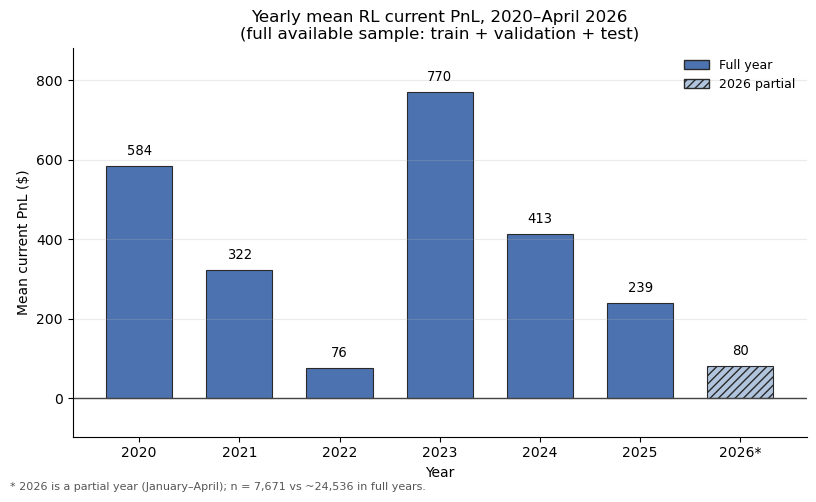

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\pub_yearly_median_current_pnl.png


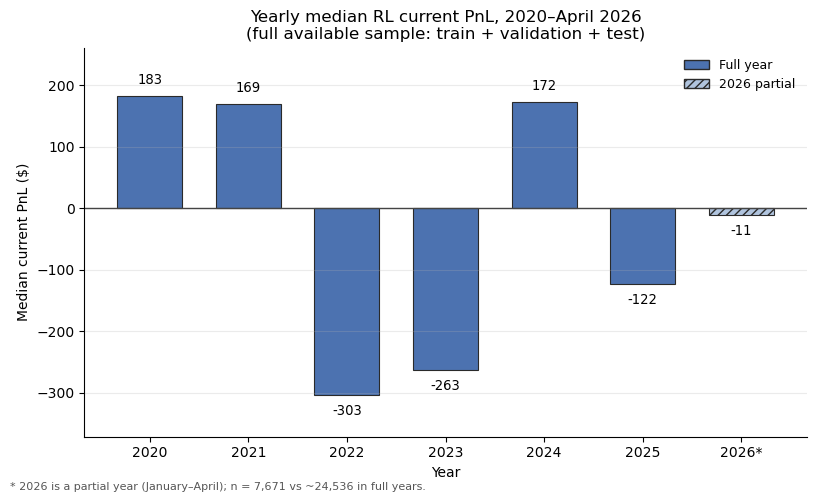

In [17]:
import calendar
from matplotlib.patches import Patch

# Detect any incomplete (partial) trailing year from the combined sample.
_ym = (
    df_all.dropna(subset=[YEAR_COL, DATE_COL])
    .groupby(YEAR_COL)[DATE_COL]
)
_max_month = {int(y): int(ts.month) for y, ts in _ym.max().items()}
_min_month = {int(y): int(ts.month) for y, ts in _ym.min().items()}
partial_years = {y for y, m in _max_month.items() if m < 12}

FULL_C, PART_C = "#4C72B0", "#B0C4DE"


def _yearly_note(d):
    if not partial_years:
        return ""
    y = max(partial_years)
    lo, hi = calendar.month_name[_min_month[y]], calendar.month_name[_max_month[y]]
    n_part = int(d.loc[d[YEAR_COL].astype(int) == y, "n_obs"].iloc[0])
    full = d.loc[~d[YEAR_COL].astype(int).isin(partial_years), "n_obs"]
    n_full = int(full.median()) if len(full) else n_part
    return (f"* {y} is a partial year ({lo}\u2013{hi}); "
            f"n = {n_part:,} vs ~{n_full:,} in full years.")


def plot_yearly_bar(stat):
    d = pnl_year.sort_values(YEAR_COL)
    years = d[YEAR_COL].astype(int).tolist()
    vals = d[stat].astype(float).tolist()
    x = range(len(years))
    colors = [PART_C if y in partial_years else FULL_C for y in years]

    fig, ax = plt.subplots(figsize=(8.2, 5.0))
    bars = ax.bar(x, vals, width=0.66, color=colors,
                  edgecolor="#2A2A2A", linewidth=0.8)
    for b, y in zip(bars, years):
        if y in partial_years:
            b.set_hatch("////")
    ax.axhline(0, color="#444444", linewidth=1.0)

    span = (max(vals) - min(vals)) or 1.0
    pad = span * 0.03
    for xi, v in zip(x, vals):
        ax.text(xi, v + (pad if v >= 0 else -pad), f"{v:,.0f}",
                ha="center", va="bottom" if v >= 0 else "top", fontsize=9.5)

    ax.set_xticks(list(x))
    ax.set_xticklabels([f"{y}*" if y in partial_years else str(y) for y in years])
    ax.set_xlabel("Year")
    ax.set_ylabel(f"{stat.capitalize()} current PnL ($)")

    if partial_years:
        py = max(partial_years)
        end_label = f"{calendar.month_name[_max_month[py]]} {py}"
    else:
        end_label = str(years[-1])
    ax.set_title(f"Yearly {stat} RL current PnL, {years[0]}\u2013{end_label}\n"
                 f"(full available sample: train + validation + test)", fontsize=12)

    lo, hi = min(vals + [0]), max(vals + [0])
    ax.set_ylim(lo - span * 0.14, hi + span * 0.16)
    ax.grid(axis="y", alpha=0.25)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

    legend = [Patch(facecolor=FULL_C, edgecolor="#2A2A2A", label="Full year")]
    if partial_years:
        legend.append(Patch(facecolor=PART_C, edgecolor="#2A2A2A", hatch="////",
                            label=f"{max(partial_years)} partial"))
    ax.legend(handles=legend, loc="best", frameon=False, fontsize=9)

    note = _yearly_note(d)
    if note:
        fig.text(0.01, 0.01, note, fontsize=8, color="#555555")
    fig.tight_layout(rect=[0, 0.03, 1, 1])
    save_current_figure(f"pub_yearly_{stat}_current_pnl")
    plt.show()


if current_pnl_target is not None and not target_by_year.empty:
    pnl_year = target_by_year[target_by_year["target"] == current_pnl_target].copy()
    if not pnl_year.empty:
        plot_yearly_bar("mean")
        plot_yearly_bar("median")


## 13. Target distribution by ticker

,target,attr__ticker,n_obs,mean,std,min,p05,p25,median,p75,p95,max,iqr,range_5_95,zero_rate,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,AAPL,1006,1.244533,2.030083,0.0,0.0,0.0,0.0,3.0,5.0,5.0,3.0,5.0,0.697813,0.302187,0.000000
1,target__pi_hindsight_entry_6bins,ABBV,1006,0.799205,1.731028,0.0,0.0,0.0,0.0,0.0,5.0,5.0,0.0,5.0,0.805169,0.194831,0.000000
2,target__pi_hindsight_entry_6bins,ABT,1006,0.708748,1.634109,0.0,0.0,0.0,0.0,0.0,5.0,5.0,0.0,5.0,0.823062,0.176938,0.000000
3,target__pi_hindsight_entry_6bins,ACN,1006,1.007952,1.886305,0.0,0.0,0.0,0.0,0.0,5.0,5.0,0.0,5.0,0.753479,0.246521,0.000000
4,target__pi_hindsight_entry_6bins,ADBE,1006,1.093439,1.926308,0.0,0.0,0.0,0.0,1.0,5.0,5.0,1.0,5.0,0.726640,0.273360,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,target__rl_long_reward,UPS,1006,-0.929025,2.598605,-3.2848,-3.2848,-3.239625,-2.89865,1.5581,3.11265,3.1631,4.797725,6.39745,0.000000,0.424453,0.575547
780,target__rl_long_reward,VZ,1006,-2.171508,1.952407,-3.3848,-3.3848,-3.2848,-3.14425,-2.903425,1.574625,2.6706,0.381375,4.959425,0.000000,0.200795,0.799205
781,target__rl_long_reward,WFC,1006,-0.599331,2.700635,-3.2848,-3.2848,-3.1325,-2.83995,1.58555,3.1205,3.1526,4.71805,6.4053,0.000000,0.472167,0.527833
782,target__rl_long_reward,WMT,1006,-0.319173,2.731531,-3.2848,-3.2848,-3.179075,1.40305,2.8866,3.119,3.1228,6.065675,6.4038,0.000000,0.500994,0.499006


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\target_summary_by_ticker.csv
Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_mean_by_ticker_target_pi_hindsight_entry_6bins.png


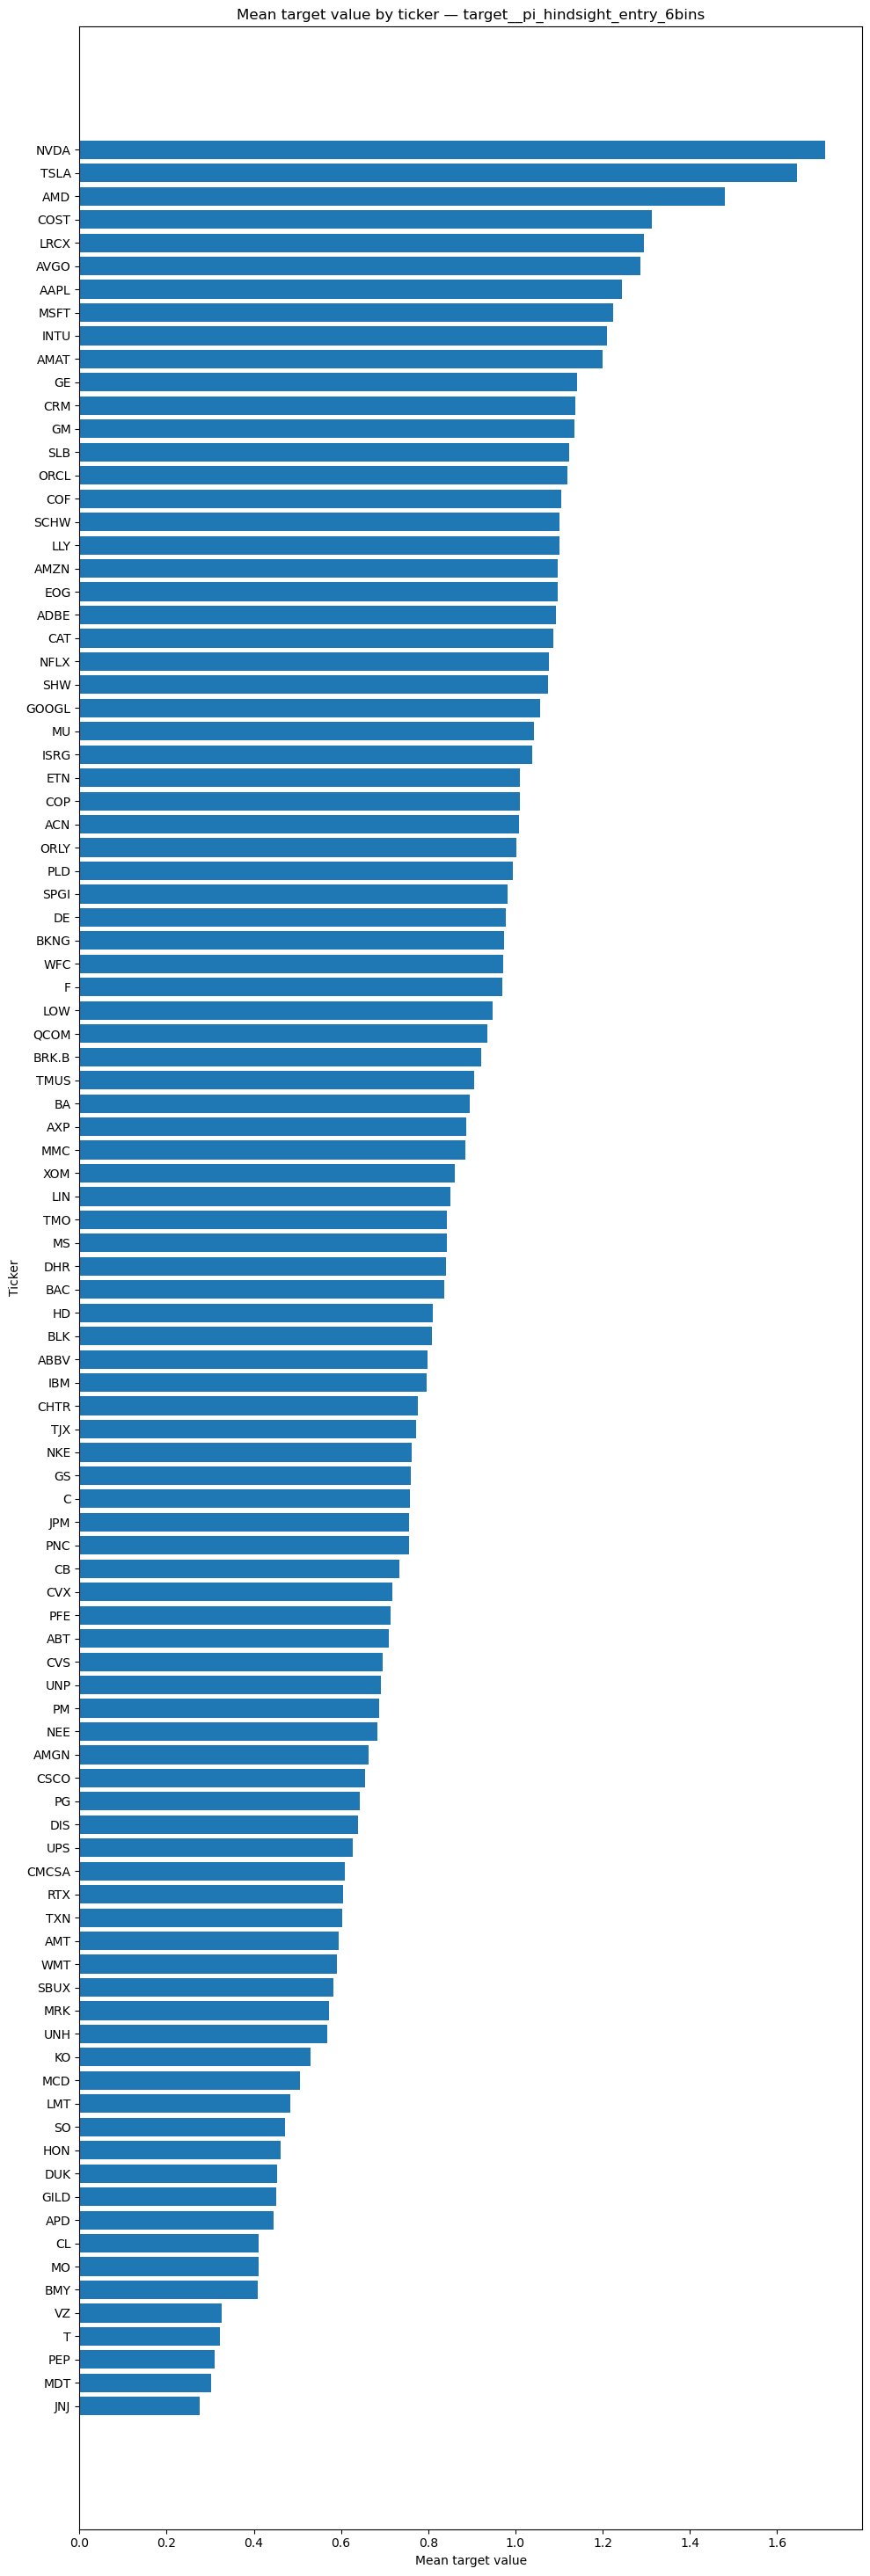

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_mean_by_ticker_target_pi_hindsight_entry_long.png


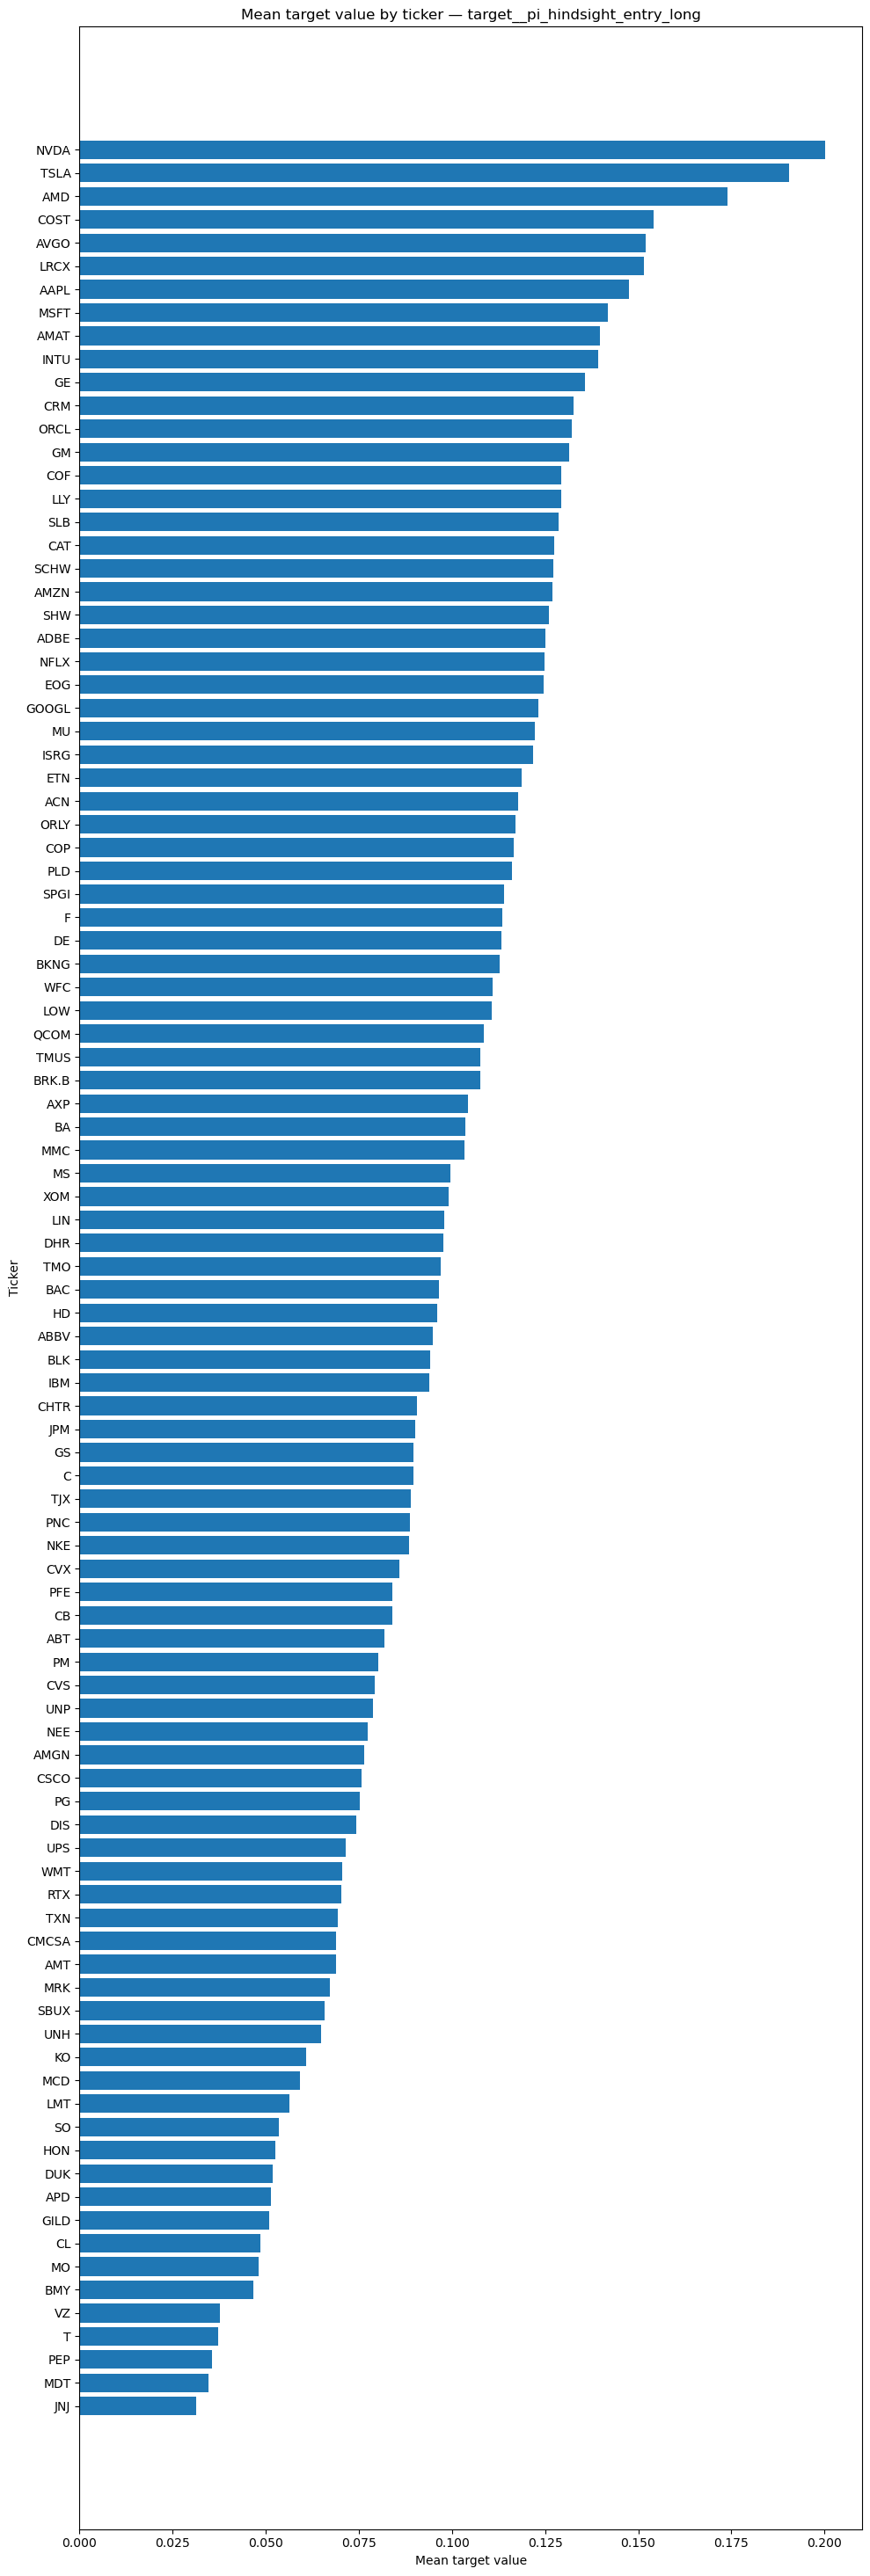

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_mean_by_ticker_target_pi_hindsight_entry_original.png


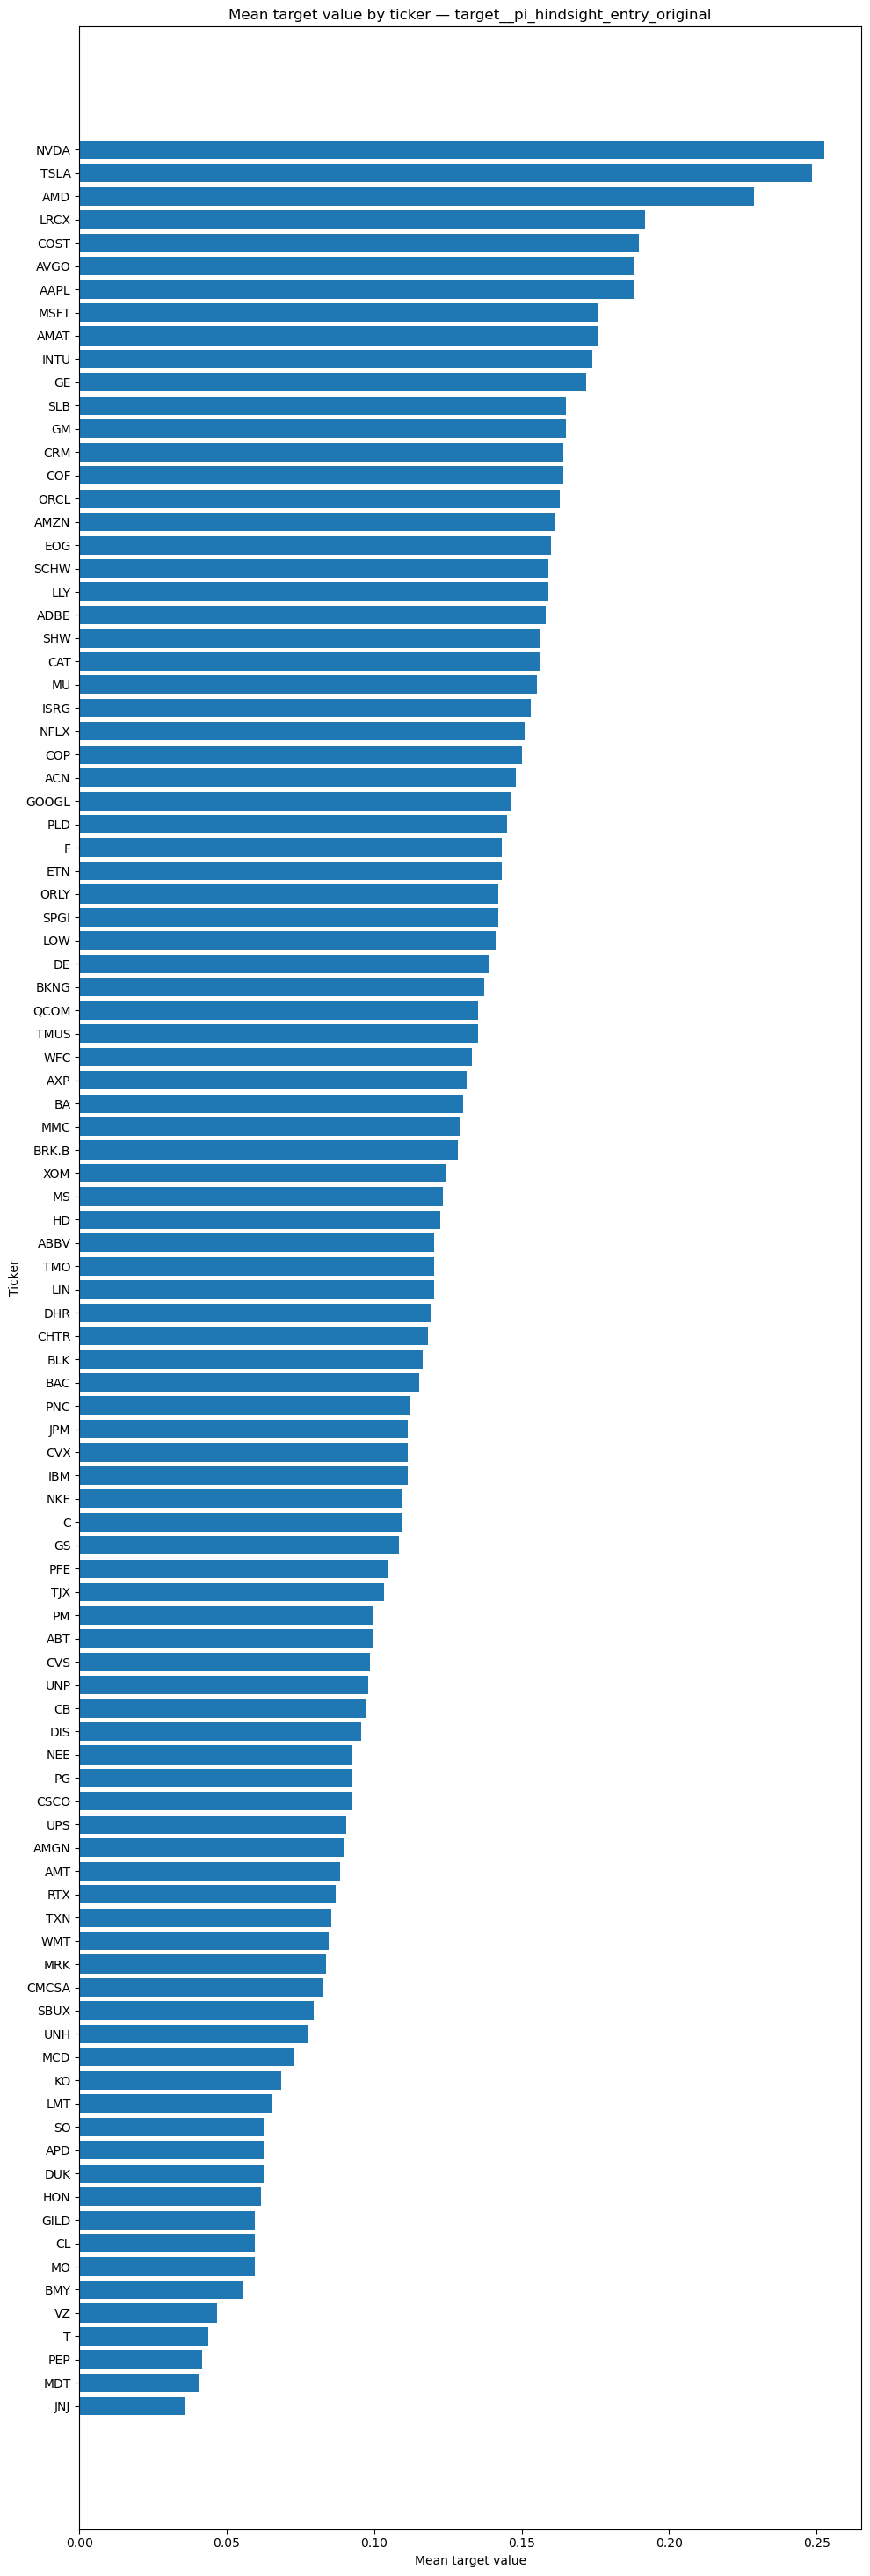

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_mean_by_ticker_target_pi_hindsight_entry_positive.png


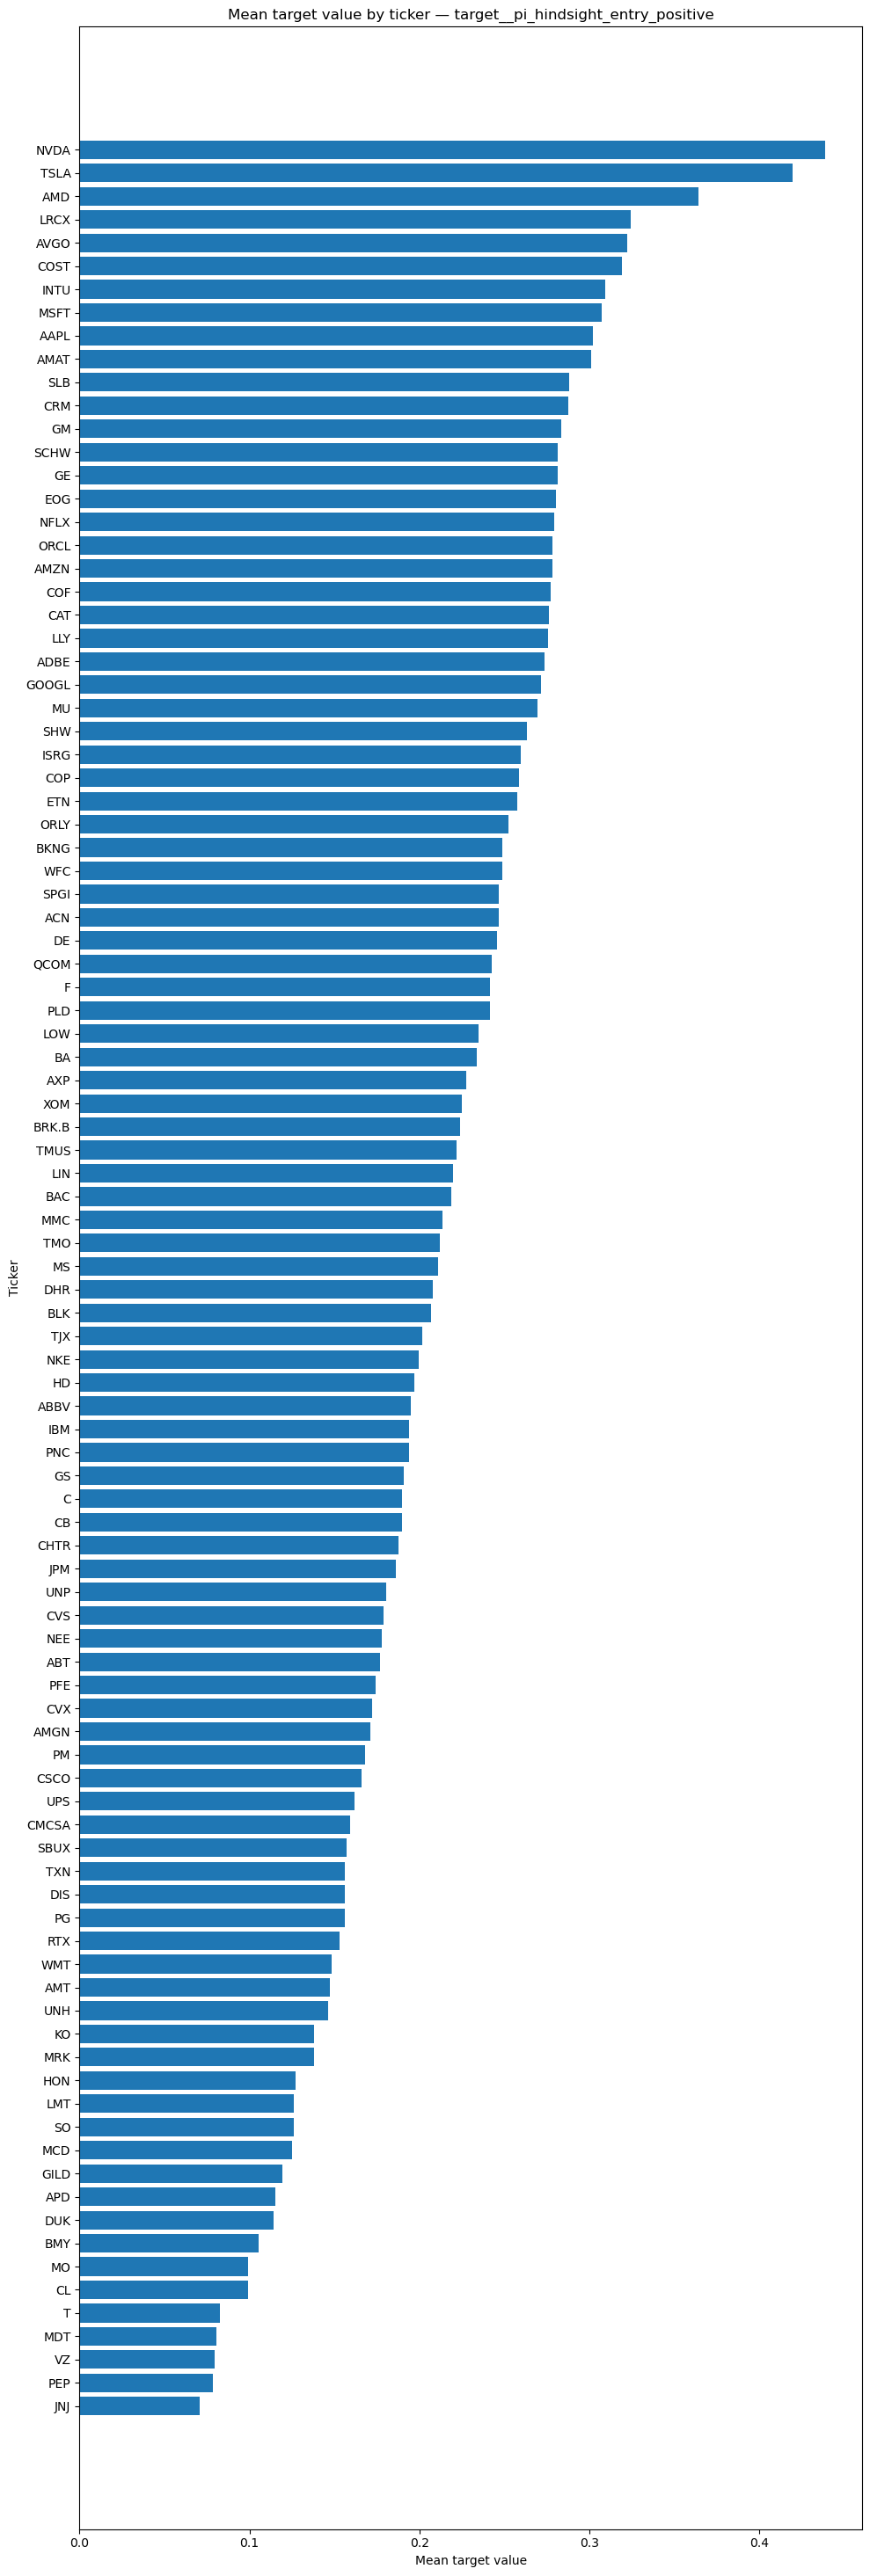

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_mean_by_ticker_target_rl_long_action_binary.png


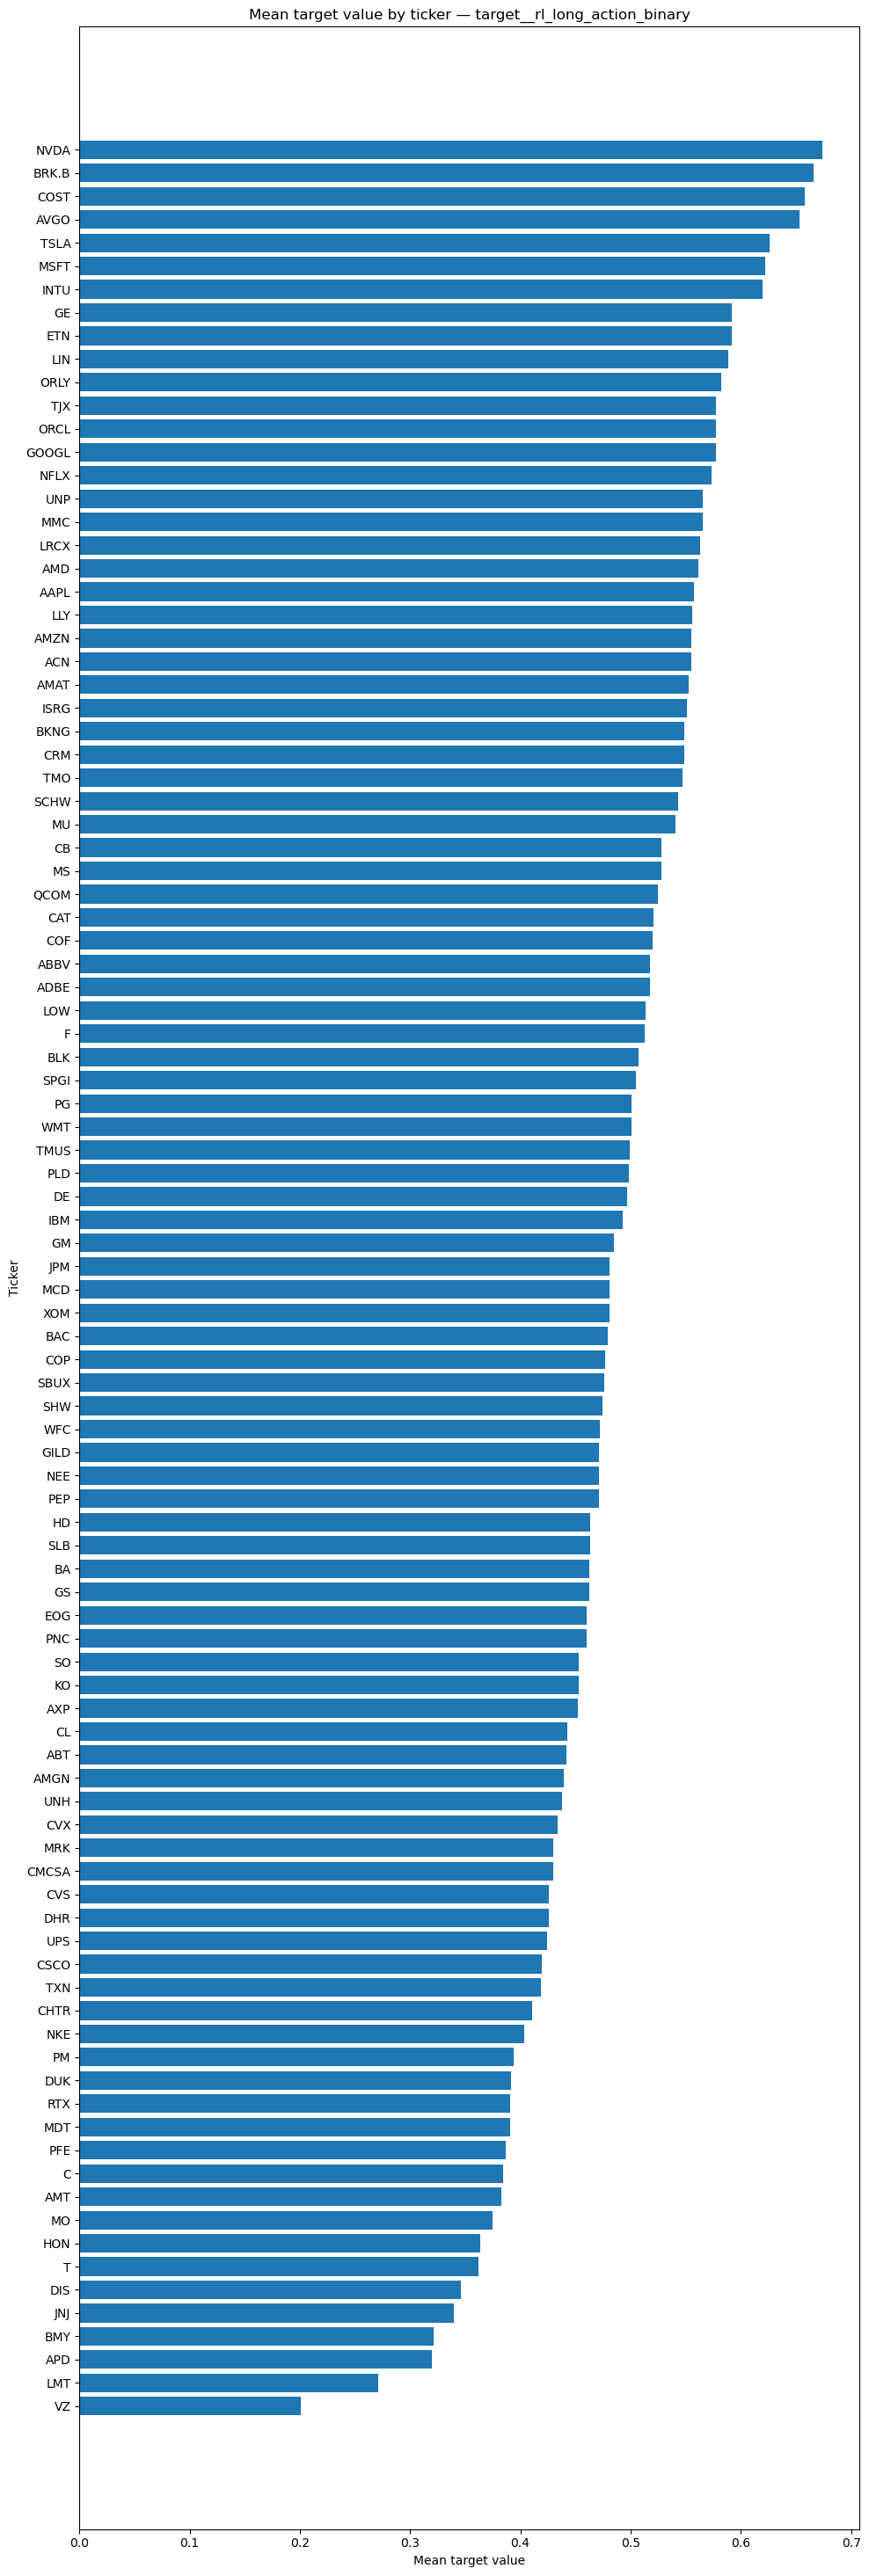

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_mean_by_ticker_target_rl_long_action_quality.png


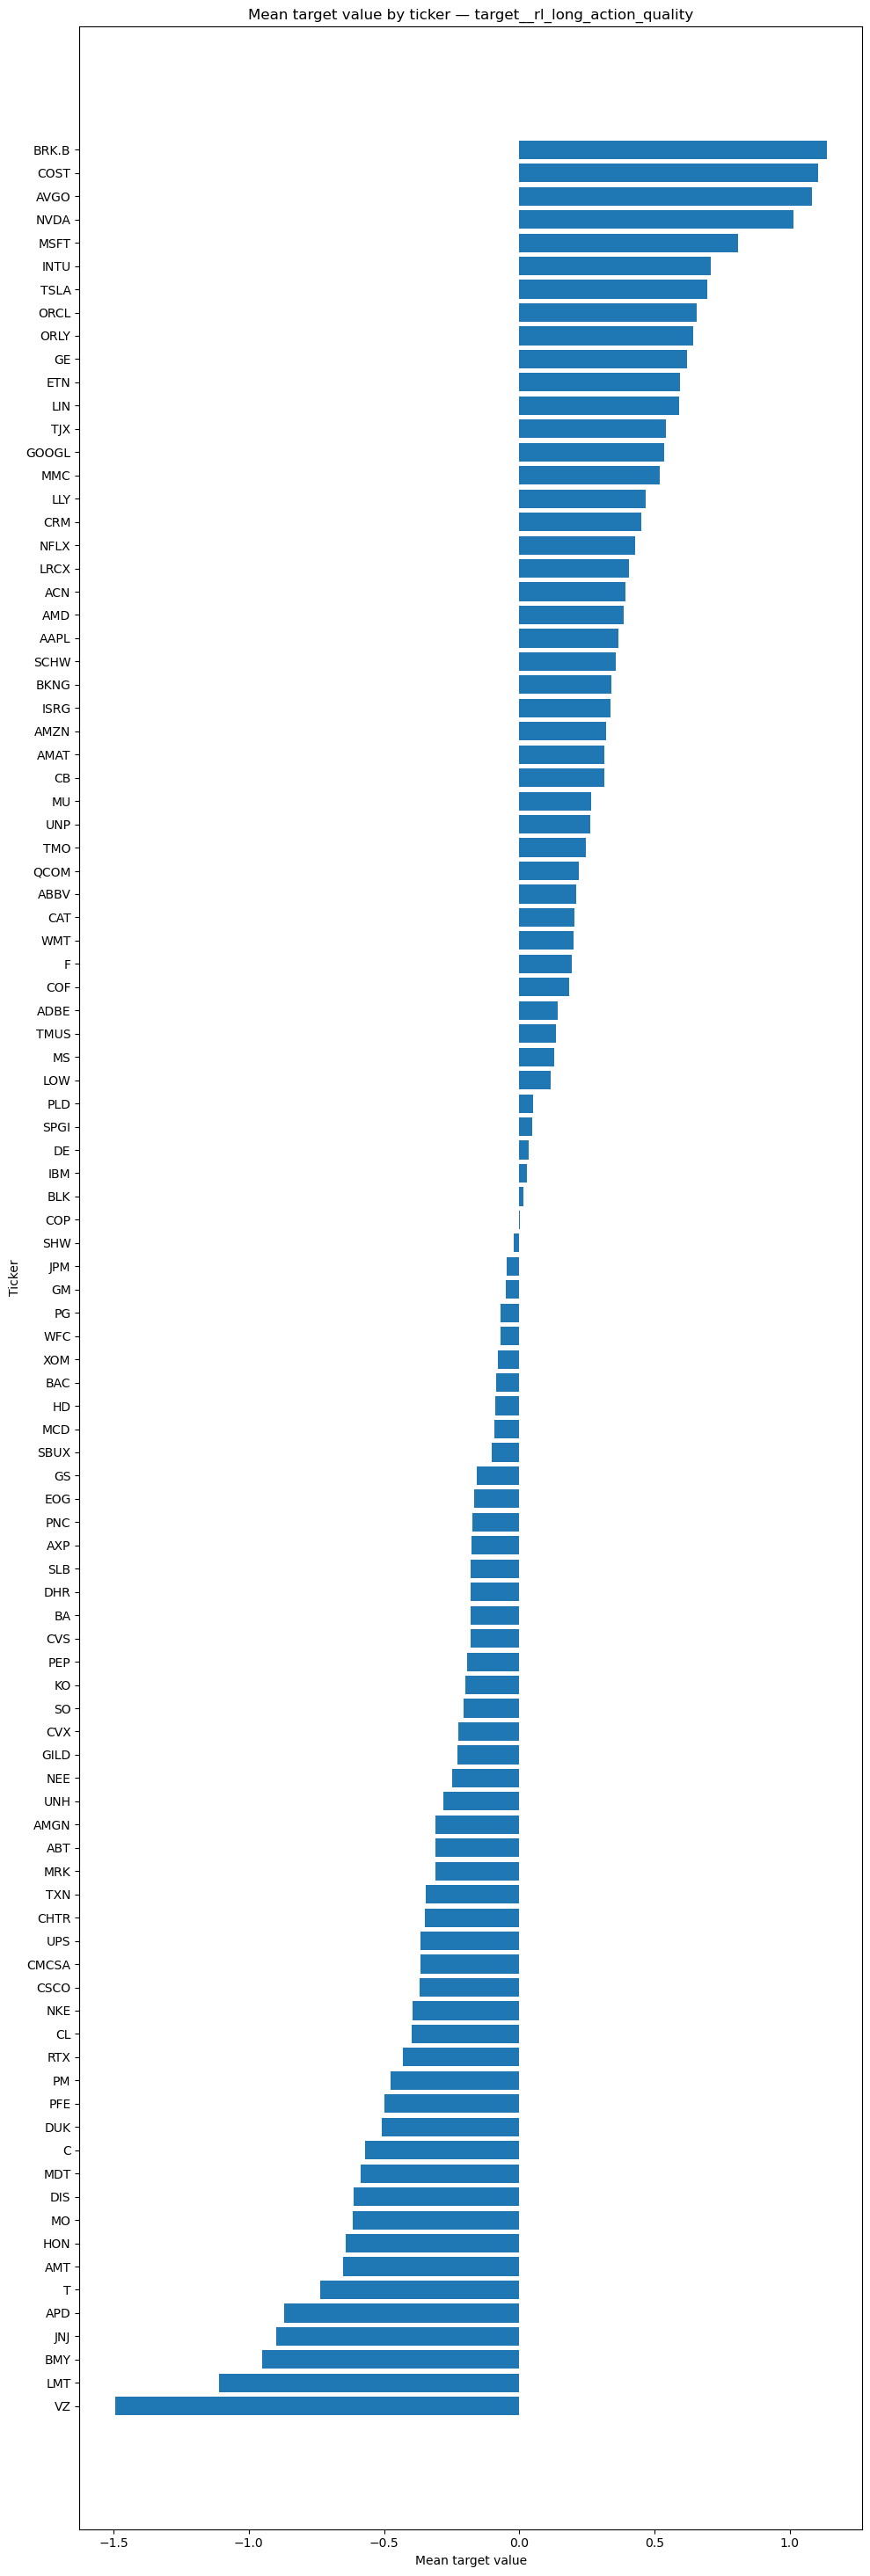

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_mean_by_ticker_target_rl_long_current_pnl.png


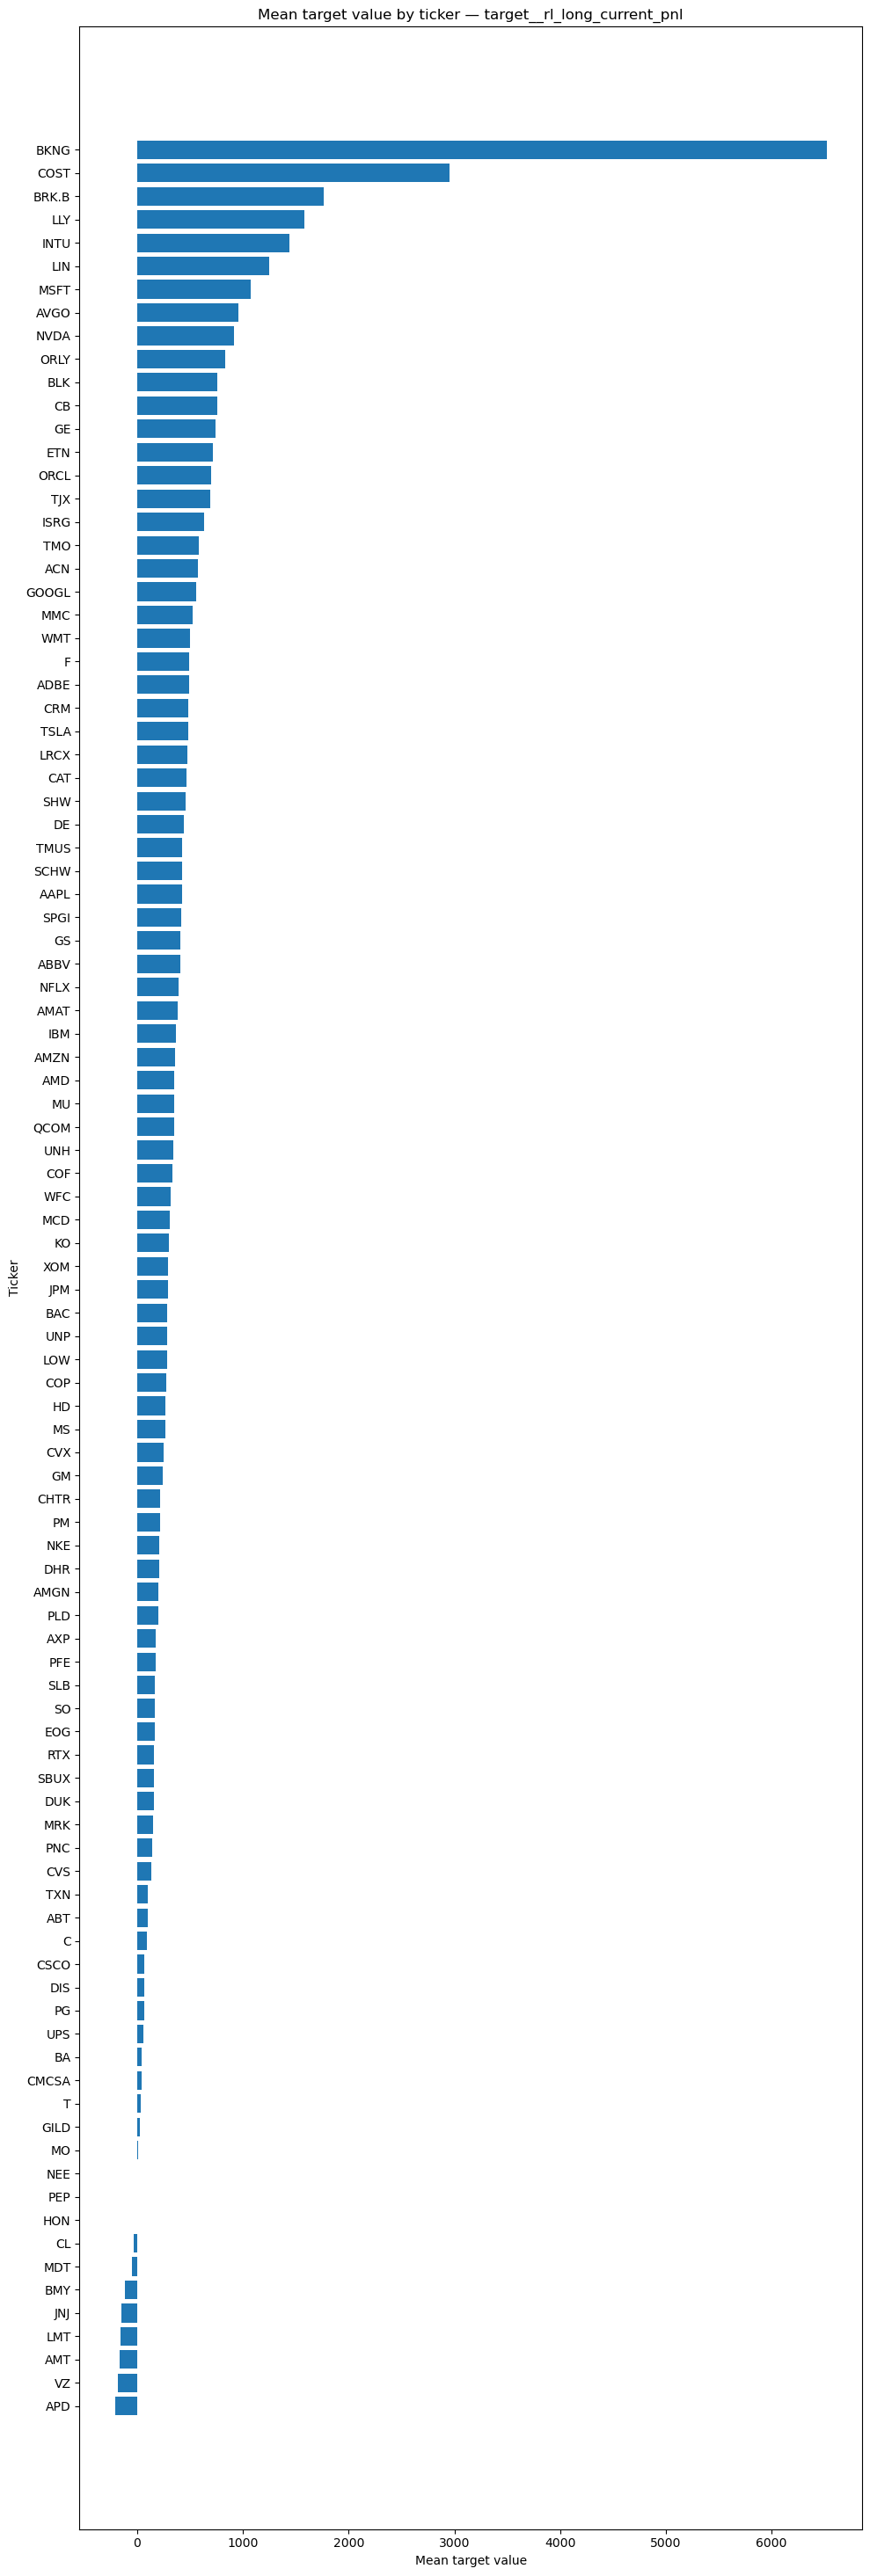

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\target_mean_by_ticker_target_rl_long_reward.png


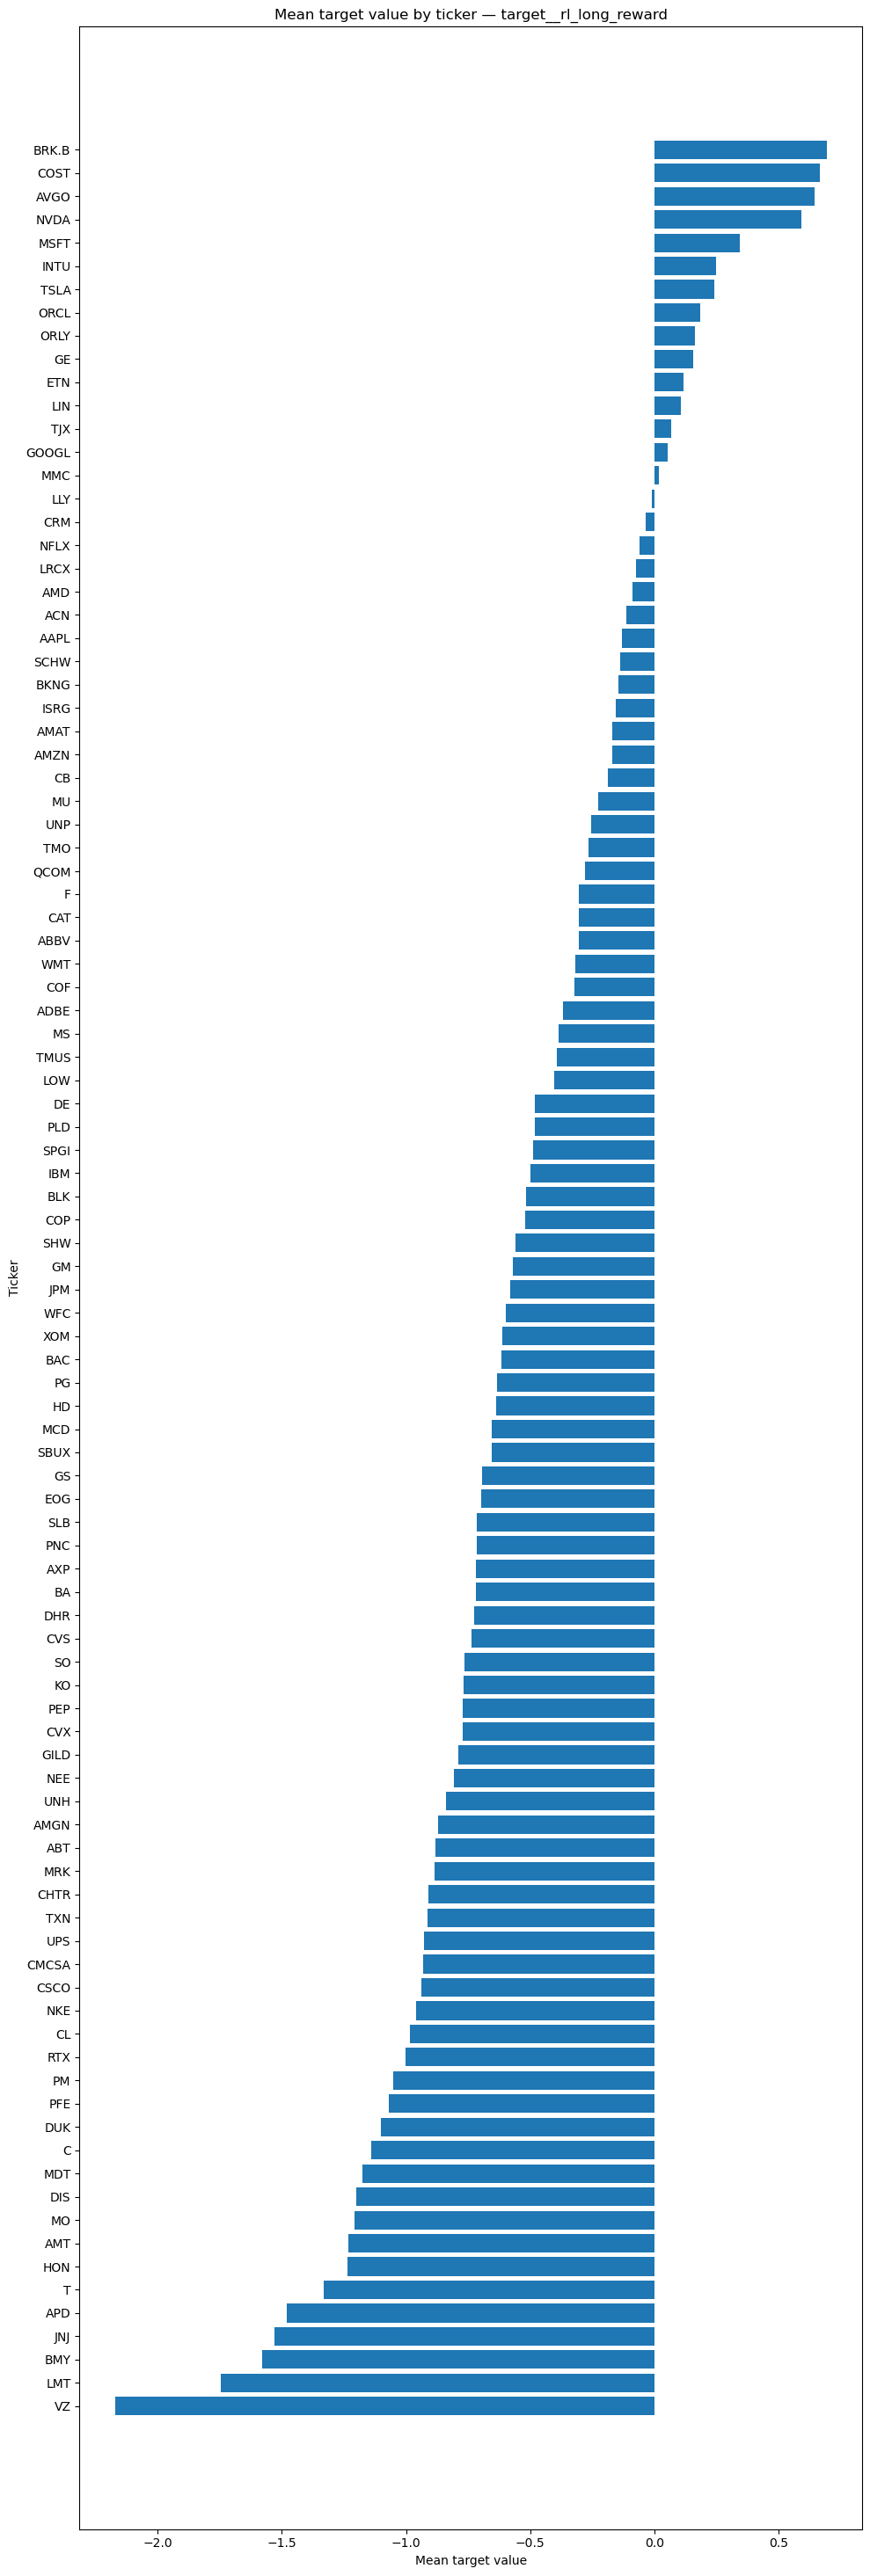

In [18]:
target_ticker_rows = []

for column in available_target_columns:
    temporary = df_train[[TICKER_COL, column]].copy()
    temporary[column] = pd.to_numeric(
        temporary[column],
        errors="coerce"
    )
    temporary = temporary.dropna(subset=[TICKER_COL, column])

    ticker_summary = (
        temporary.groupby(TICKER_COL)[column]
        .agg(
            n_obs="size",
            mean="mean",
            std="std",
            min="min",
            p05=lambda s: s.quantile(0.05),
            p25=lambda s: s.quantile(0.25),
            median="median",
            p75=lambda s: s.quantile(0.75),
            p95=lambda s: s.quantile(0.95),
            max="max"
        )
        .reset_index()
    )
    ticker_summary["iqr"] = ticker_summary["p75"] - ticker_summary["p25"]
    ticker_summary["range_5_95"] = ticker_summary["p95"] - ticker_summary["p05"]

    ticker_rates = (
        temporary.groupby(TICKER_COL)[column]
        .apply(
            lambda values: pd.Series({
                "zero_rate": (values == 0).mean(),
                "positive_rate": (values > 0).mean(),
                "negative_rate": (values < 0).mean()
            })
        )
        .unstack()
        .reset_index()
    )

    ticker_summary = ticker_summary.merge(
        ticker_rates,
        on=TICKER_COL,
        how="left"
    )
    ticker_summary.insert(0, "target", column)
    target_ticker_rows.append(ticker_summary)

target_by_ticker = (
    pd.concat(target_ticker_rows, ignore_index=True)
    if target_ticker_rows
    else pd.DataFrame()
)

export_table("target_summary_by_ticker", target_by_ticker)

for column in available_target_columns:
    plot_data = (
        target_by_ticker[
            target_by_ticker["target"] == column
        ]
        .sort_values("mean")
    )

    if plot_data.empty:
        continue

    plt.figure(figsize=(10, max(5, 0.3 * len(plot_data))))
    plt.barh(
        plot_data[TICKER_COL].astype(str),
        plot_data["mean"]
    )
    plt.title(f"Mean target value by ticker — {column}")
    plt.xlabel("Mean target value")
    plt.ylabel("Ticker")
    save_current_figure(f"target_mean_by_ticker_{column}")
    plt.show()


## 13b. Publication figures — ticker-level median vs IQR (training sample)

A compact scatter of each ticker's median current PnL (location) against its
interquartile range (scale), plus an appendix bar chart ranking tickers by IQR.
Computed on the training sample only.

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\pub_ticker_median_vs_iqr.png


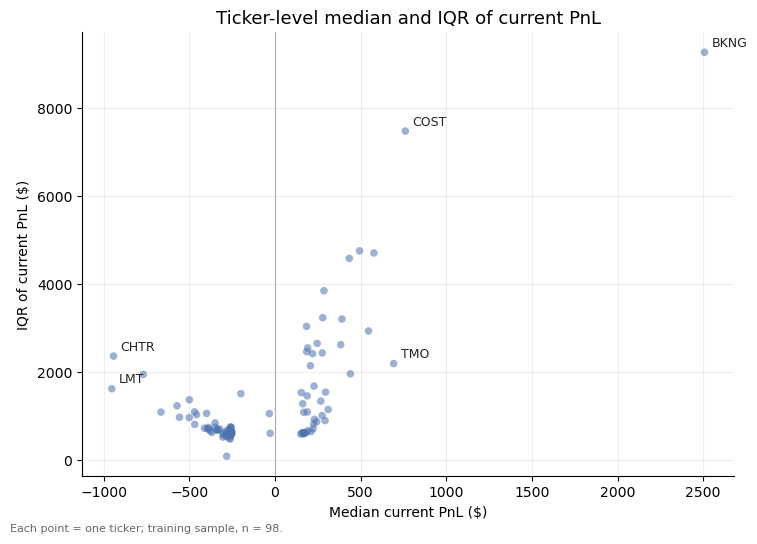

Saved figure: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\figures\pub_ticker_iqr_ranking.png


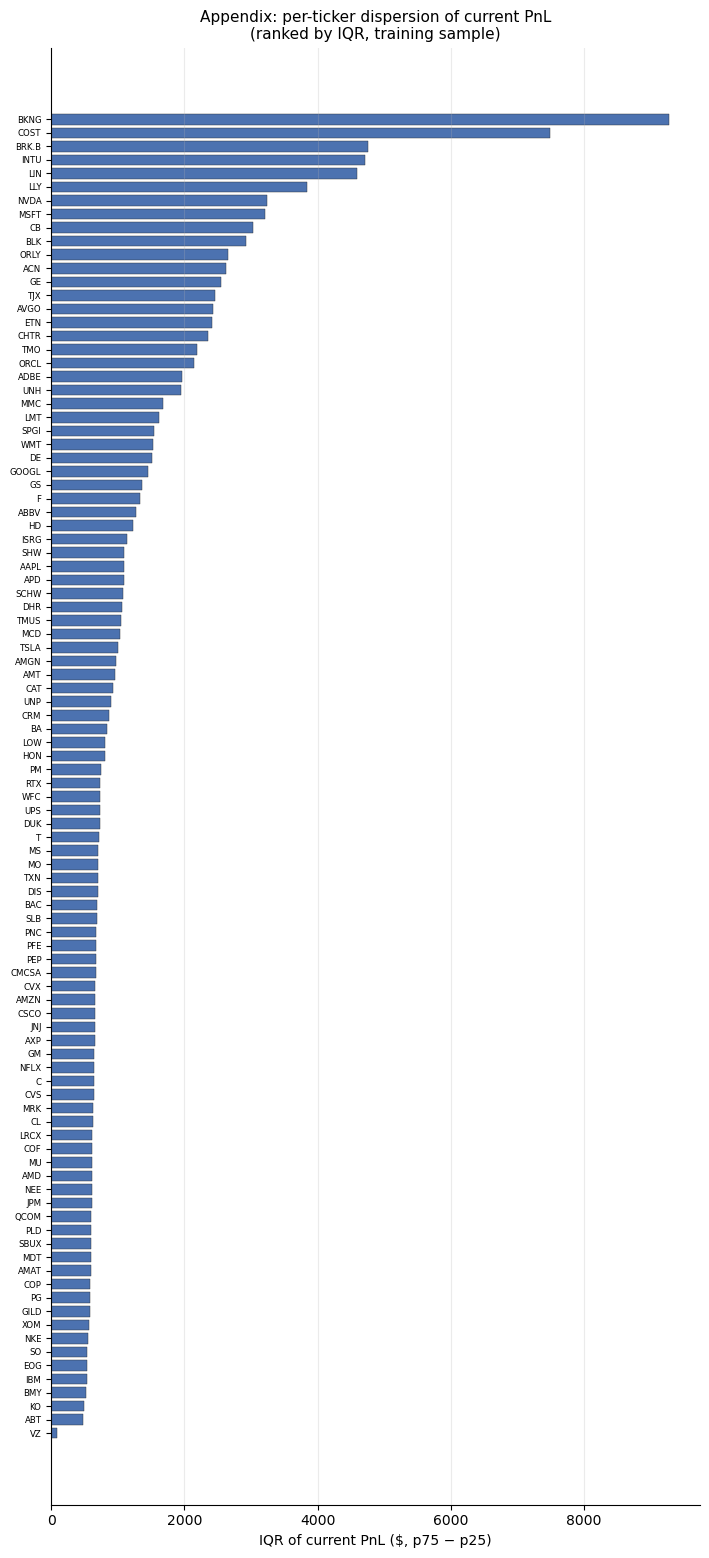

In [19]:
if current_pnl_target is not None and not target_by_ticker.empty:
    tk = target_by_ticker[target_by_ticker["target"] == current_pnl_target].copy()
    tk = tk.dropna(subset=["median", "iqr"])

    if not tk.empty:
        # --- scatter: median (location) vs IQR (scale) ---
        fig, ax = plt.subplots(figsize=(7.6, 5.4))
        ax.axvline(0, color="#AAAAAA", linewidth=0.8, zorder=1)
        ax.scatter(tk["median"], tk["iqr"], s=30, c="#4C72B0",
                   alpha=0.55, edgecolor="none", zorder=3)

        # label only a few clear outliers: widest IQR + most extreme medians
        to_label = (set(tk.nlargest(2, "iqr")[TICKER_COL])
                    | set(tk.nlargest(3, "median")[TICKER_COL])
                    | set(tk.nsmallest(2, "median")[TICKER_COL]))
        for _, r in tk.iterrows():
            if r[TICKER_COL] in to_label:
                ax.annotate(str(r[TICKER_COL]), (r["median"], r["iqr"]),
                            xytext=(5, 4), textcoords="offset points",
                            fontsize=9, color="#222222")

        ax.set_xlabel("Median current PnL ($)")
        ax.set_ylabel("IQR of current PnL ($)")
        ax.set_title("Ticker-level median and IQR of current PnL", fontsize=13)
        ax.grid(alpha=0.20, zorder=0)
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)
        fig.text(0.01, 0.005,
                 f"Each point = one ticker; training sample, "
                 f"n = {tk[TICKER_COL].nunique()}.",
                 fontsize=8, color="#666666")
        fig.tight_layout(rect=[0, 0.03, 1, 1])
        save_current_figure("pub_ticker_median_vs_iqr")
        plt.show()

        # --- appendix: per-ticker IQR ranking ---
        rk = tk.sort_values("iqr", ascending=False)
        y = list(range(len(rk)))[::-1]
        fig, ax = plt.subplots(figsize=(7.2, max(6.0, 0.16 * len(rk))))
        ax.barh(y, rk["iqr"], color="#4C72B0",
                edgecolor="#2A2A2A", linewidth=0.3, height=0.78)
        ax.set_yticks(y)
        ax.set_yticklabels(rk[TICKER_COL].astype(str), fontsize=6.2)
        ax.set_xlabel("IQR of current PnL ($, p75 \u2212 p25)")
        ax.set_title("Appendix: per-ticker dispersion of current PnL\n"
                     "(ranked by IQR, training sample)", fontsize=11)
        ax.grid(axis="x", alpha=0.25)
        for sp in ["top", "right"]:
            ax.spines[sp].set_visible(False)
        fig.tight_layout()
        save_current_figure("pub_ticker_iqr_ranking")
        plt.show()


## 14. Feature–target rank correlations

In [20]:
feature_target_rows = []

correlation_features = final_feature_b_features.copy()

for target_column in available_target_columns:
    target_values = pd.to_numeric(
        df_train[target_column],
        errors="coerce"
    )

    for feature_column in correlation_features:
        feature_values = pd.to_numeric(
            df_train[feature_column],
            errors="coerce"
        )

        valid = feature_values.notna() & target_values.notna()

        if valid.sum() < 30:
            correlation = np.nan
        else:
            correlation = feature_values[valid].corr(
                target_values[valid],
                method="spearman"
            )

        feature_target_rows.append({
            "target": target_column,
            "feature": feature_column,
            "n_complete": int(valid.sum()),
            "spearman": correlation,
            "absolute_spearman": (
                abs(correlation)
                if pd.notna(correlation)
                else np.nan
            )
        })

feature_target_correlations = pd.DataFrame(feature_target_rows)

export_table(
    "feature_target_spearman_correlations",
    feature_target_correlations,
    display_table=False
)

top_feature_target_correlations = (
    feature_target_correlations
    .sort_values(
        ["target", "absolute_spearman"],
        ascending=[True, False]
    )
    .groupby("target", group_keys=False)
    .head(20)
)

export_table(
    "top_feature_target_spearman_correlations",
    top_feature_target_correlations
)


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\feature_target_spearman_correlations.csv


,target,feature,n_complete,spearman,absolute_spearman
268,target__pi_hindsight_entry_6bins,feature__volatility_trailing_1m,98419,0.188698,0.188698
2,target__pi_hindsight_entry_6bins,feature__avg_daily_turnover,98419,0.122631,0.122631
256,target__pi_hindsight_entry_6bins,feature__regime_vix_percentile_1y,98419,0.112936,0.112936
244,target__pi_hindsight_entry_6bins,feature__price_vs_52w_high,98419,-0.098657,0.098657
248,target__pi_hindsight_entry_6bins,feature__regime_cpi_yoy,98419,-0.096856,0.096856
...,...,...,...,...,...
1972,target__rl_long_reward,feature__b_net_debt_to_ebitda_shortfall_below_p1,98419,0.083418,0.083418
1984,target__rl_long_reward,feature__b_quick_ratio_delta_to_p50,98419,0.082280,0.082280
2026,target__rl_long_reward,feature__cash_to_debt,98419,0.080794,0.080794
2047,target__rl_long_reward,feature__dividend_yield_quartile,98419,-0.078307,0.078307


Saved table: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\top_feature_target_spearman_correlations.csv


,target,feature,n_complete,spearman,absolute_spearman
268,target__pi_hindsight_entry_6bins,feature__volatility_trailing_1m,98419,0.188698,0.188698
2,target__pi_hindsight_entry_6bins,feature__avg_daily_turnover,98419,0.122631,0.122631
256,target__pi_hindsight_entry_6bins,feature__regime_vix_percentile_1y,98419,0.112936,0.112936
244,target__pi_hindsight_entry_6bins,feature__price_vs_52w_high,98419,-0.098657,0.098657
248,target__pi_hindsight_entry_6bins,feature__regime_cpi_yoy,98419,-0.096856,0.096856
...,...,...,...,...,...
1972,target__rl_long_reward,feature__b_net_debt_to_ebitda_shortfall_below_p1,98419,0.083418,0.083418
1984,target__rl_long_reward,feature__b_quick_ratio_delta_to_p50,98419,0.082280,0.082280
2026,target__rl_long_reward,feature__cash_to_debt,98419,0.080794,0.080794
2047,target__rl_long_reward,feature__dividend_yield_quartile,98419,-0.078307,0.078307


## 15. Final integrated export and manifest

In [21]:
def make_excel_safe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in df.columns:
        # Handles normal datetime64 columns
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            try:
                df[col] = df[col].dt.tz_localize(None)
            except TypeError:
                # Already timezone-naive
                pass

        # Handles object columns containing timezone-aware Timestamp values
        elif df[col].dtype == "object":
            if df[col].map(lambda x: isinstance(x, pd.Timestamp)).any():
                df[col] = df[col].map(
                    lambda x: x.tz_localize(None)
                    if isinstance(x, pd.Timestamp) and x.tzinfo is not None
                    else x
                )

    return df

workbook_path = export_all_tables_to_workbook()

manifest = pd.DataFrame({
    "output_type": (
        ["table"] * len(list(TABLE_DIR.glob("*")))
        + ["figure"] * len(list(FIGURE_DIR.glob("*")))
        + ["inventory"] * len(list(INVENTORY_DIR.glob("*")))
    ),
    "path": (
        [str(path.resolve()) for path in sorted(TABLE_DIR.glob("*"))]
        + [str(path.resolve()) for path in sorted(FIGURE_DIR.glob("*"))]
        + [str(path.resolve()) for path in sorted(INVENTORY_DIR.glob("*"))]
    )
})

manifest.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)
display(manifest)

print("\nEDA complete.")
print("Main output directory:", OUTPUT_DIR.resolve())
print("Integrated workbook:", workbook_path.resolve())
print("Number of registered tables:", len(EXPORTED_TABLES))
print("Number of saved figures:", len(list(FIGURE_DIR.glob('*.png'))))


Saved integrated workbook: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\recent_training_eda_all_tables.xlsx


,output_type,path
0,table,C:\Users\user\Downloads\universe_100_recent_po...
1,table,C:\Users\user\Downloads\universe_100_recent_po...
2,table,C:\Users\user\Downloads\universe_100_recent_po...
3,table,C:\Users\user\Downloads\universe_100_recent_po...
4,table,C:\Users\user\Downloads\universe_100_recent_po...
...,...,...
103,inventory,C:\Users\user\Downloads\universe_100_recent_po...
104,inventory,C:\Users\user\Downloads\universe_100_recent_po...
105,inventory,C:\Users\user\Downloads\universe_100_recent_po...
106,inventory,C:\Users\user\Downloads\universe_100_recent_po...



EDA complete.
Main output directory: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831
Integrated workbook: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment_0722\recent_training_eda_outputs_20260727_185831\tables\recent_training_eda_all_tables.xlsx
Number of registered tables: 20
Number of saved figures: 60
